<header>
<h1> <b> Hobo Logger SOP Script </b> </h1>
</header>
This is a script that will handle the steps outlined in the Hobo Logger SOP. <br>
Written by Travis Hamlin and Cole Sheeley
<br>Edited: 3/26/2024: date of file generation

## Steps outlined by the SOP
1. Downloading and merging the data files
2. Checking, processing, and naming the .csv file
3. Exporting hobo file details and creating a metadata file
4. Create the metadata file
5. Upload and update files
#### NOTE: Although outlined in the SOP, this code in its current version, will not complete steps 3 through 5, so make sure these are completed manually!


## <B> BEFORE YOU START
<li>This code will process the HOBO Logger data after it has been put into '.csv' format.
<li>This code uses the metadata that is in the Temperature_UVI_deployment_log that is on google drive.
<li>The Temperature_UVI_deployment_log needs to be downloaded as a '.csv'.
<li>All of the date columns in the UVI deployment log must be formated as month/day/full year. e.g. 1/1/2024
<li>All of the time columns in the UVI deployment log must be formatted as hh:mm:ss in military time. e.g. 14:30:00

### <b>FILE NAMING: duplicate files should be named _a and _b and offset files should be named _c and _d
<li>e.g. "BT_TCCB08_2210_a"

## <u>NOTE: If error occurs, it was most likely due to running a previous cell that caused an overwrite of a variable. To fix it, rerun the code from the top!</u>

## Working log: updates on issues and fixes that we ran into
There must be either an a or a blank for the files. the code will not process it if there is only a 'b' file. e.g. BT_TFLTC_2310_b had to be changed to _a

## Importing libraries:
These are the libaries you will need to run this code. If not previously installed, make sure to use the function pip.install in the console: e.g. pip.install os
</ol> Below is a list of the libraries and a breif description of what they do.
<li>os: This module in python provides functions to interact with the operating system such as navigating, accesing environment variables, and executing system commands.
<li>pandas(pd): pandas is used for data manipulation and analysis library providing data structures like DataFrames and Series, allowing you to work with structured data easily
<li>glob: provides a way to search for files that match a specified pattern
<li>matplotlib.pyplot(plt): this is a plotting library that enables the creation of plots and visualizations. The 'pyplot' module provides a MATLAB-like interface for creating plots interactively
<li>datetime: provides classes for working with dates and times, allowing you to create, manipulate, format, and perform operations on dates and times.

In [1]:
#%% Imports
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
from datetime import datetime

## <b>Step 1. Downloading the data files and wrangling

### Getting the file paths:
This cell block accesses the folder path where the .csv files are stored. The lower case r before 'folderpath' is to avoid having to change the backslashes to foward slashes because of using a PC. If using a MAC, you can copy and paste the folderpath and remove the lower case r as foward slashes are default for that operating system.
<li><u>Make sure to update the folder path in the cell!</u>

In [23]:
#%% Get file paths
 
# Define folder path where your CSV files are located
folder_path = r'C:\UVI\QAQC stuff\Temp_TCRMP_2025_Working Folder'

# Define pattern to match CSV files
file_pattern = '*.csv'

# Use glob to get a list of file paths matching the pattern set in file_pattern
csv_files = glob.glob(folder_path + '/' + file_pattern)

# Print file paths
print(csv_files)

['C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBKIT_2404_.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBKIX_2403_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBKIX_2403_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBKPT_2402_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBKPT_2402_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBOTB_2404_.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCBRWB_2404_.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCCB08_2403_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCCB08_2403_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCCB40_2403_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCCB40_2403_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCCLGE_2404_.csv', 'C:\\UVI\\QAQC stuff\\Temp_TCRMP_2025_Working Folder\\BT_TCCORB_2402_.csv', 'C:

### Site codes:
This cell block contains all of the site codes, and if new ones are created, add them here. If not added, the code will not catch them.
<h2></ol> <b> MAKE SURE TO ADD NEW SITE CODES TO THE METADATA DOCUMENTS BEFORE ADDING THEM HERE!!! <br>
 OR ELSE...

In [24]:
# %% Generate a list of all site codes

site_codes = ["TCCORB","TCFSHB","TCMERI","TCBKPT","TCBOTB","TCBRWB","TCBKIT",
              "TCCORK","TCCLGE","TCFLTC","TCGB63","TCGMKT","TCHB40","TCHB30",
              "TCHB20","TCMAGB","TCSAVA","TCSHCS","TCSCAP","TCSC35","TCSWAT",
              "TCLSTJ","TCBKIX","TCBX33","TCCB08","TCCB40","TCCB99","TCCB67",
              "TCCSTL","TCEAGR","TCGRPD","TCJCKB","TCKNGC","TCLBEM","TCLB99",
              "TCLB67","TCLBRH","TCMT24","TCMT40","TCSR30","TCSR99","TCSR41",
              "TCSR67","TCSR10","TCSPTH"]
## NOTE: site code TCCB60 was not in the site code metadata

### Generating dataframes:
To handle the 'a' and 'b' files, this code generates an empty dictionary to store them that can then be called through a nested dictionary structure. The nested dictonary structure splits the file name by the _ (underscore) to organize each file through a number of identifiers. If the file name does not contain a letter at the end of it, it will be assigned as 'a'. The code then checks the existence of each identifier through a series of if statements in a for loop, by doing nothing if it exists and moving to the next identifier. If the identifier doesn't exist, the else statements create that identifier for the file. The last if and else statement (the middle of the loop), checks if there is two 'a' identifiers for the file; if so then a warning message should appear indicating a duplicate file, if not then adds it to the dictionary. (example for calling a file provided at bottom of the cell)

In [25]:
#%% Generate dataframes that can be called through a nested dictonary structure
# This creates a nested dictionary that can handle situations when site codes 
# have multiple different start times and multiple files i.e. 'a' and 'b' files

# Create an empty dictionary to store DataFrames structured by site code, file number, file identifier, and file name
df_files = {}

# Iterate through each CSV file
for csv_file in csv_files:
    # Extract site code, file number, file identifier, and file name from the file name
    file_name = os.path.basename(csv_file).split('.')[0]  # Remove the file extension
    parts = file_name.split('_')
    site_code = parts[1]  # Extract the site code
    file_number = parts[2]  # Extract the file number
    file_identifier = parts[-1] if len(parts) > 3 and parts[-1] != '' else "a" # Extract the file identifier ('a', 'b', etc.), assign 'a' if not present
    
    # Read CSV file into a DataFrame
    df = pd.read_csv(csv_file)
    
    # Extract the base file name without the extension
    base_file_name = os.path.splitext(os.path.basename(csv_file))[0]
    
    # Check if the site code already exists in the dictionary
    if site_code in df_files:
        # Check if the file number already exists in the dictionary for the site code
        if file_number in df_files[site_code]:
            # If the file number exists, check if the file identifier already exists
            if file_identifier in df_files[site_code][file_number]:
                print(f"Warning: Duplicate file identifier {file_identifier} for site code {site_code} and file number {file_number}. Ignoring.")
            else:
                # If the file identifier doesn't exist, add the DataFrame and file name to the dictionary
                df_files[site_code][file_number][file_identifier] = {'DataFrame': df, 'File Name': base_file_name}
        else:
            # If the file number doesn't exist, create a new dictionary for the file number
            df_files[site_code][file_number] = {file_identifier: {'DataFrame': df, 'File Name': base_file_name}}
    else:
        # If the site code doesn't exist, create a new dictionary for the site code
        df_files[site_code] = {file_number: {file_identifier: {'DataFrame': df, 'File Name': base_file_name}}}

# Accessing the DataFrames by site code, file number, file identifier, and file name
# For example, to access the DataFrame and file name for site code 'TCBKPT', file number '2209', and file identifier 'a'
#if 'TCSR41' in df_files and '2210' in df_files['TCSR41'] and 'a' in df_files['TCSR41']['2210']:
    #print("File Name:", df_files['TCSR41']['2210']['a']['File Name'])
    #print("DataFrame:")
    #print(df_files['TCSR41']['2210']['a']['DataFrame'])
#else:
    #print("DataFrame not found for site code 'TCSR41', file number '2210', and file identifier 'a'")

#print(df_files)

## File identifier check:
This cell reports all the files that have an 'a' identifier that is assigned when imported. If there is a file without an 'a' identifier, that means there is only a 'b' file and will not be processed by the code. <u> This file needs to then be changed to 'a' so the code can process it.<u>

In [26]:
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        if 'a' not in file_data:
            print(f"Warning: No 'a' identifier found for site code {site_code} and file number {file_number}.")
        else:
            file_name = file_data['a']['File Name']
            print(f"File with 'a' identifier found for site code {site_code} and file number {file_number}: {file_name}")


File with 'a' identifier found for site code TCBKIT and file number 2404: BT_TCBKIT_2404_
File with 'a' identifier found for site code TCBKIX and file number 2403: BT_TCBKIX_2403_a
File with 'a' identifier found for site code TCBKPT and file number 2402: BT_TCBKPT_2402_a
File with 'a' identifier found for site code TCBOTB and file number 2404: BT_TCBOTB_2404_
File with 'a' identifier found for site code TCBRWB and file number 2404: BT_TCBRWB_2404_
File with 'a' identifier found for site code TCCB08 and file number 2403: BT_TCCB08_2403_a
File with 'a' identifier found for site code TCCB40 and file number 2403: BT_TCCB40_2403_a
File with 'a' identifier found for site code TCCLGE and file number 2404: BT_TCCLGE_2404_
File with 'a' identifier found for site code TCCORB and file number 2402: BT_TCCORB_2402_
File with 'a' identifier found for site code TCCORK and file number 2404: BT_TCCORK_2404_a
File with 'a' identifier found for site code TCCSTL and file number 2403: BT_TCCSTL_2403_
File 

### Read in deployment log:
The importance of reading in the deployment log is to make sure that the .csv files from the working folder match the loggers that have been deployed and import the metadata for each logger in the working folder, so that they can be called without having to search the deployment log. Make sure to download Temperature_UVI_deployment_log from the google drive as a .csv file.
<li><u>Make sure to update the folder path in the cell!</u>

In [27]:
# %% Read in deployment log metadata sheet

deployment_df = pd.read_csv(r'C:\UVI\QAQC stuff\Temperature_UVI_deployment_log.csv')

### Filtering the deployment log:
The cell takes the file names imported from the working folder and uses them to filter out the uncessary files that do not match those imported.

In [28]:
# %% Filter deployment log metatdata sheet csv

# Extract file names from csv_files
csv_file_names = [os.path.basename(csv_file).split('.')[0] for csv_file in csv_files]

# Filter deployment_df to only include entries that match the file names in csv_files
filtered_deployment_df = deployment_df[deployment_df['Offloaded Filename'].isin(csv_file_names)]

# Print the filtered DataFrame
print(filtered_deployment_df)

      Status                           Location    Logger Tag I.D.  \
878  Removed                South Capella 35 m   21828438      NaN   
879  Removed     South Capella 35 m (duplicate)  20423422      NaN   
917  Removed                          Flat Cay   21879672      NaN   
918  Removed               Flat Cay (duplicate)  21445090      NaN   
919  Removed                       Black Point   21879671      NaN   
920  Removed            Black Point (duplicate)  21445101      NaN   
921  Removed                    Coral Bay (STJ)  21879675      NaN   
922  Removed                     Fish Bay (STJ)  21879666      NaN   
925  Removed              Buck Island MCE (STX)  21879682      NaN   
926  Removed  Buck Island MCE (STX) (duplicate)  20954395      NaN   
927  Removed                    Jacks Bay (STX)  21879670      NaN   
928  Removed                       Castle (STX)  21879683      NaN   
929  Removed                    Eagle Ray (STX)  21879680      NaN   
930  Removed        

### Warning check 1: unmatched files
If there are names in the .csv files imported from the working folder that do not match those in the deployment log, the cell below will report a warning and the file(s) that does not match. This may occur from manipulating the names in the working folder, and need to be fixed or the working folder may need to be redownloaded.

In [29]:
# %% Find which file names you are processing did not match with the file names in the deployment log.


# Extract file names from csv_files
csv_file_names = [os.path.basename(csv_file).split('.')[0] for csv_file in csv_files]

# Filter deployment_df to only include entries that match the file names in csv_files
matched_files = deployment_df[deployment_df['Offloaded Filename'].isin(csv_file_names)]['Offloaded Filename'].tolist()

# Identify files in csv_files that did not match
unmatched_files = [file_name for file_name in csv_file_names if file_name not in matched_files]

# Print files in csv_files that did not match
print("!!!!!WARNING CHECK:!!!!!")
print("Files in csv_files that did not match:")
print(unmatched_files)
# These file names need to be fixed in the google sheet version and the sheet 
# needs to be redownloaded and the code needs to be run again.

!!!!!WARNING CHECK:!!!!!
Files in csv_files that did not match:
[]


### Subsetting column names:
Filters the columns from the deployment log needed for the metadata of each logger.

In [30]:
# %% Subset columns from filtered_deployment_df

subset_columns = ['Offloaded Filename','Date In','Time In', 'Date Full', 'Date Out', 'Time Out']
filtered_deployment_df = filtered_deployment_df[subset_columns]
print(filtered_deployment_df)

    Offloaded Filename     Date In   Time In   Date Full    Date Out  Time Out
878   BT_TCSC35_2310_a  10/23/2023  11:18:00  12/31/2024  10/25/2024  10:59:00
879   BT_TCSC35_2310_b  10/23/2023  11:18:00  12/31/2024  10/25/2024  10:59:00
917   BT_TCFLTC_2402_a   2/15/2024  10:41:00   4/25/2025  10/22/2024  13:16:00
918   BT_TCFLTC_2402_b   2/15/2024  10:41:00   4/25/2025  10/22/2024  13:16:00
919   BT_TCBKPT_2402_a   2/15/2024  13:46:00   4/25/2025  10/11/2024   9:36:00
920   BT_TCBKPT_2402_b   2/15/2024  13:46:00   4/25/2025  10/11/2024   9:36:00
921    BT_TCCORB_2402_   2/16/2024  10:51:00   4/26/2025  10/24/2024  12:41:00
922    BT_TCFSHB_2402_   2/16/2024  13:45:00   4/26/2025  10/24/2024  10:53:00
925   BT_TCBKIX_2403_a   3/11/2024  13:25:00   5/20/2025  11/11/2024  10:59:00
926   BT_TCBKIX_2403_b   3/11/2024  13:25:00   5/20/2025  11/11/2024  10:59:00
927    BT_TCJCKB_2403_   3/14/2024  15:33:00   5/23/2025  11/13/2024  13:18:00
928    BT_TCCSTL_2403_   3/11/2024  15:25:00   5/20/

### Warning check 2: ? in the time columns
In the deployment log, it was discovered that there were occasional question marks in the time in and time out columns. This cell identifies those areas that would need to be changed manually in the deployment log. If you run the cell and get "SyntaxWarning..." do not worry, as long as there is a check mark at the bottom left of the cell that means it worked.

In [31]:
#%% Check to see if there is a "?" in the "Time In" or the "Time Out" Columns
# May want to expand this to account for other instances of Incorrect metadata inputs
# Convert columns to strings
filtered_deployment_df['Time In'] = filtered_deployment_df['Time In'].astype(str)
filtered_deployment_df['Time Out'] = filtered_deployment_df['Time Out'].astype(str)

# Filter rows containing "?" in either Time In or Time Out
rows_with_question_mark = filtered_deployment_df[filtered_deployment_df['Time In'].str.contains('\?') | filtered_deployment_df['Time Out'].str.contains('\?')]

# Print the value of Offloaded Filename where there is a "?" in Time In or Time Out
if not rows_with_question_mark.empty:
    print("!!!!!WARNING CHECK!!!!!!:"
           "'?' file row", rows_with_question_mark['Offloaded Filename'].values[0],
           "May want to process file separately")


<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2226248557.py:8: SyntaxWarning: invalid escape sequence '\?'
  rows_with_question_mark = filtered_deployment_df[filtered_deployment_df['Time In'].str.contains('\?') | filtered_deployment_df['Time Out'].str.contains('\?')]
C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2226248557.py:8: SyntaxWarning: invalid escape sequence '\?'
  rows_with_question_mark = filtered_deployment_df[filtered_deployment_df['Time In'].str.contains('\?') | filtered_deployment_df['Time Out'].str.contains('\?')]


### Convert back to datetime
To check for the ? in the columns, the datetime was convereted to a string. So to revert the process, the cell below does just that and checks the data type just to make sure. Formatting for date in and out was not done in the code, because it should have been formatted before importing.

In [32]:
#%% Convert back to datetime format
# Convert Time In and Time Out columns to datetime format
filtered_deployment_df['Time In'] = pd.to_datetime(filtered_deployment_df['Time In'], format='%H:%M:%S', errors='coerce')
filtered_deployment_df['Time Out'] = pd.to_datetime(filtered_deployment_df['Time Out'], format='%H:%M:%S', errors='coerce')

#%% Convert Date In and Date Out columns to datetime format
filtered_deployment_df['Date In'] = pd.to_datetime(filtered_deployment_df['Date In'])
filtered_deployment_df['Date Out'] = pd.to_datetime(filtered_deployment_df['Date Out'])



print(filtered_deployment_df.dtypes)  # Check the data types after conversion

Offloaded Filename            object
Date In               datetime64[ns]
Time In               datetime64[ns]
Date Full                     object
Date Out              datetime64[ns]
Time Out              datetime64[ns]
dtype: object


### Combine Date and Time:
Now that both the Date and Time are in the same format (datetime) the Date and Time the logger entered and exited deployment are combined into the same column respectively. Then if needed (commented out) the code drops the uncombined columns from the filtered_deployment_df.

In [33]:
# Combine the date and time columns for Date In Time In
filtered_deployment_df['Date In Time In'] = pd.to_datetime(filtered_deployment_df['Date In'].astype(str) + ' ' + filtered_deployment_df['Time In'].astype(str))

# Combine the date and time columns for Date Out Time Out
filtered_deployment_df['Date Out Time Out'] = pd.to_datetime(filtered_deployment_df['Date Out'].astype(str) + ' ' + filtered_deployment_df['Time Out'].astype(str))

# Drop the separate Date In, Time In, Date Out, and Time Out columns if needed
#filtered_deployment_df.drop(columns=['Date In', 'Time In', 'Date Out', 'Time Out'], inplace=True)

print(filtered_deployment_df)

print(filtered_deployment_df['Date In Time In'], filtered_deployment_df['Date Out Time Out'])

    Offloaded Filename    Date In             Time In   Date Full   Date Out  \
878   BT_TCSC35_2310_a 2023-10-23 1900-01-01 11:18:00  12/31/2024 2024-10-25   
879   BT_TCSC35_2310_b 2023-10-23 1900-01-01 11:18:00  12/31/2024 2024-10-25   
917   BT_TCFLTC_2402_a 2024-02-15 1900-01-01 10:41:00   4/25/2025 2024-10-22   
918   BT_TCFLTC_2402_b 2024-02-15 1900-01-01 10:41:00   4/25/2025 2024-10-22   
919   BT_TCBKPT_2402_a 2024-02-15 1900-01-01 13:46:00   4/25/2025 2024-10-11   
920   BT_TCBKPT_2402_b 2024-02-15 1900-01-01 13:46:00   4/25/2025 2024-10-11   
921    BT_TCCORB_2402_ 2024-02-16 1900-01-01 10:51:00   4/26/2025 2024-10-24   
922    BT_TCFSHB_2402_ 2024-02-16 1900-01-01 13:45:00   4/26/2025 2024-10-24   
925   BT_TCBKIX_2403_a 2024-03-11 1900-01-01 13:25:00   5/20/2025 2024-11-11   
926   BT_TCBKIX_2403_b 2024-03-11 1900-01-01 13:25:00   5/20/2025 2024-11-11   
927    BT_TCJCKB_2403_ 2024-03-14 1900-01-01 15:33:00   5/23/2025 2024-11-13   
928    BT_TCCSTL_2403_ 2024-03-11 1900-0

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\719418287.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_deployment_df['Date In Time In'] = pd.to_datetime(filtered_deployment_df['Date In'].astype(str) + ' ' + filtered_deployment_df['Time In'].astype(str))
C:\Users\magic\AppData\Local\Temp\ipykernel_29152\719418287.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_deployment_df['Date Out Time Out'] = pd.to_datetime(filtered_deployment_df['Date Out'].astype(str) + ' ' + filtered_deployment_df['Time Out'].astype(str))


### Problematic rows
If the above cell block returns and error, this means that there are indiscrepencies in the data, likely the deployment log. Input the postion number in the code below that the error message states and it will tell you where the error occurs in the data.


In [84]:
problematic_row = filtered_deployment_df.iloc[28] #position number
print(problematic_row)

Offloaded Filename             BT_TCSHCS_2403_a
Date In                     2024-03-07 00:00:00
Time In                     1900-01-01 07:00:00
Date Full                             5/16/2025
Date Out                    2024-10-29 00:00:00
Time Out                    1900-01-01 11:07:00
Date In Time In       2024-03-07 07:00:00-01:00
Date Out Time Out     2024-10-29 11:07:00-01:00
Name: 947, dtype: object


### Deployment data dictionary:
To quickly search for the deployment data without having to look through the deployment log, this cell creates a dictionary to call the related deployment data for each site code.

In [34]:
#%% Make a dictonary for each record contained in the filtered_deployment_df

# Create a dictionary to hold entries based on Offloaded Filename
deployment_data_dict = {}

# Iterate through DataFrame rows
for index, row in filtered_deployment_df.iterrows():
    file_info = {
        'Date In': row['Date In'], #From here
        'Time In': row['Time In'],
        'Date Full': row['Date Full'],
        'Date Out': row['Date Out'],
        'Time Out': row['Time Out'], #To here would need to be commented out if dropped in previous cell
        'Date In Time In': row['Date In Time In'],
        'Date Out Time Out': row['Date Out Time Out'],
        'Offloaded Filename': row['Offloaded Filename']
    }
    # Append file info to the dictionary using Offloaded Filename as key
    deployment_data_dict[row['Offloaded Filename']] = file_info

# Print the created dictionary
for filename, file_info in deployment_data_dict.items():
    print(f"Offloaded Filename: {filename}")
    print(f"File Info: {file_info}")

Offloaded Filename: BT_TCSC35_2310_a
File Info: {'Date In': Timestamp('2023-10-23 00:00:00'), 'Time In': Timestamp('1900-01-01 11:18:00'), 'Date Full': '12/31/2024', 'Date Out': Timestamp('2024-10-25 00:00:00'), 'Time Out': Timestamp('1900-01-01 10:59:00'), 'Date In Time In': Timestamp('2023-10-23 11:18:00-0100', tz='UTC-01:00'), 'Date Out Time Out': Timestamp('2024-10-25 10:59:00-0100', tz='UTC-01:00'), 'Offloaded Filename': 'BT_TCSC35_2310_a'}
Offloaded Filename: BT_TCSC35_2310_b
File Info: {'Date In': Timestamp('2023-10-23 00:00:00'), 'Time In': Timestamp('1900-01-01 11:18:00'), 'Date Full': '12/31/2024', 'Date Out': Timestamp('2024-10-25 00:00:00'), 'Time Out': Timestamp('1900-01-01 10:59:00'), 'Date In Time In': Timestamp('2023-10-23 11:18:00-0100', tz='UTC-01:00'), 'Date Out Time Out': Timestamp('2024-10-25 10:59:00-0100', tz='UTC-01:00'), 'Offloaded Filename': 'BT_TCSC35_2310_b'}
Offloaded Filename: BT_TCFLTC_2402_a
File Info: {'Date In': Timestamp('2024-02-15 00:00:00'), 'Time 

### Example deployment metadata call using the deployment_data_dict dictionary:

In [47]:
# Example deployment data call
#deployment_data_dict["BT_TCSR41_2210_a"]

### Match the Date Times data type in deployment data dictionary to the times data type in df_files ###
This loop iterates through each file in the deployment data dictionary and converts the Date Times into a stringtime format.

In [35]:
#%% Change Date Times in deployment_data_dict to match the times in df_files

# Iterate through deployment_data_dict
for filename, file_info in deployment_data_dict.items():
    # Convert 'Date In Time Out' and 'Date Out Time Out' to the specified format
    file_info['Date In Time In'] = file_info['Date In Time In'].strftime('%m/%d/%y %H:%M:%S')
    file_info['Date Out Time Out'] = file_info['Date Out Time Out'].strftime('%m/%d/%y %H:%M:%S')

# Now the values for 'Date In Time Out' and 'Date Out Time Out' are in the specified time format

## Plot pre-trimmed files
This plots the pre-trimmed version of the files

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


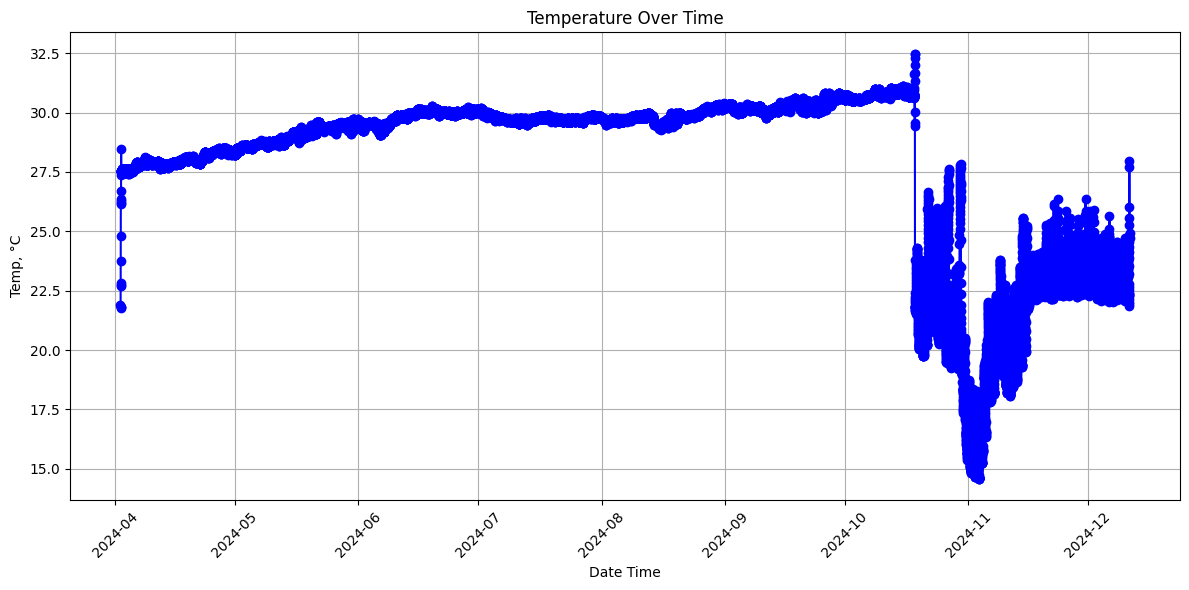

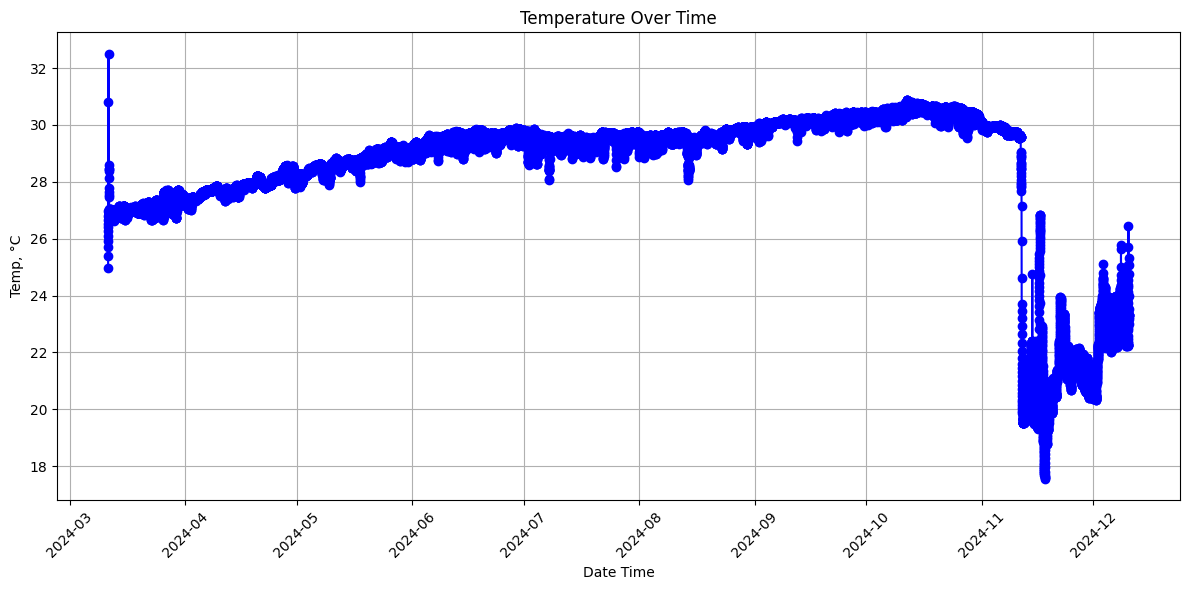

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


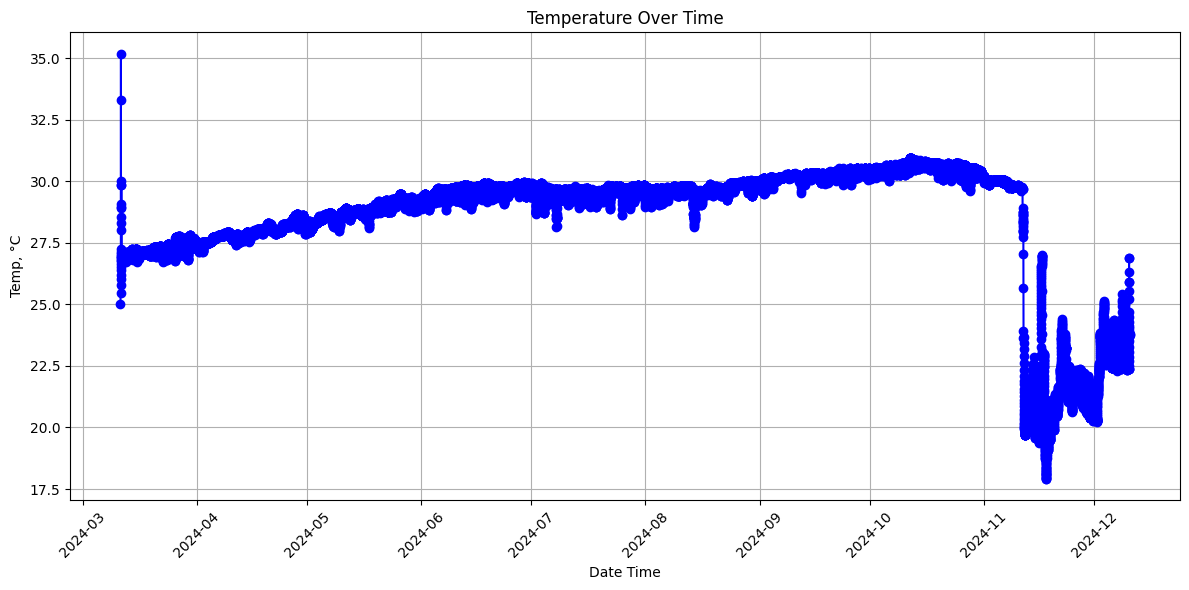

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


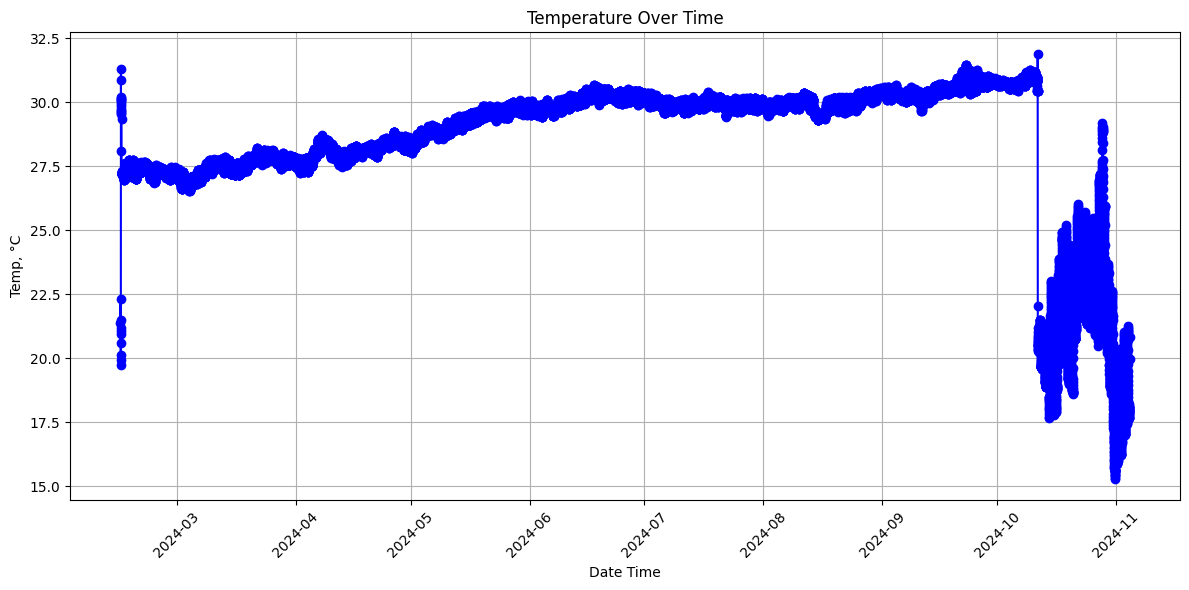

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


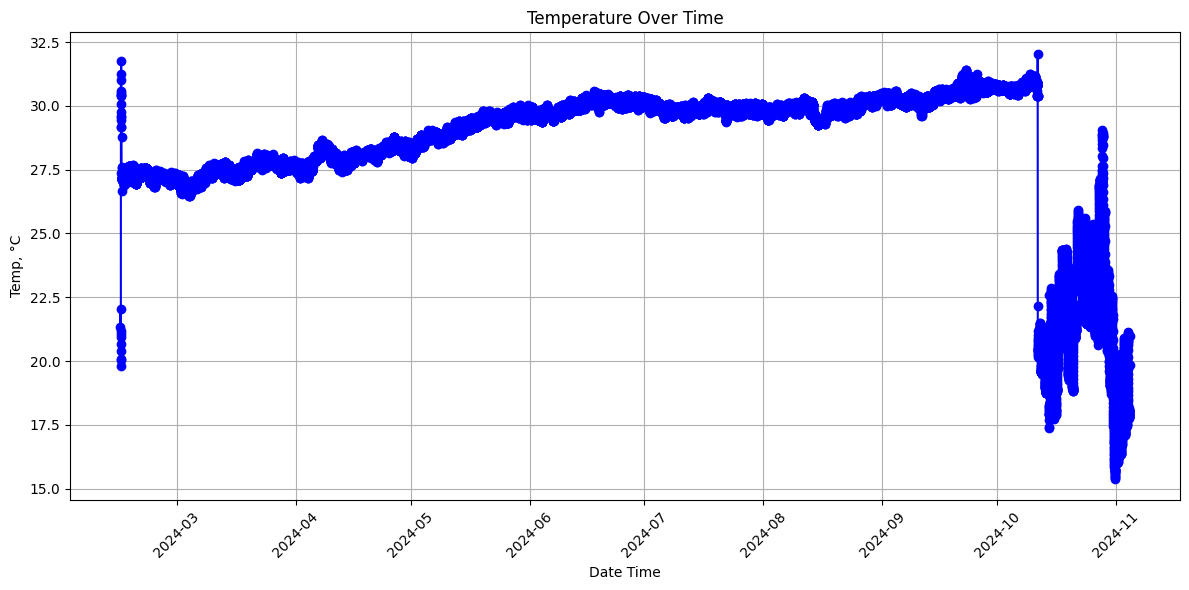

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


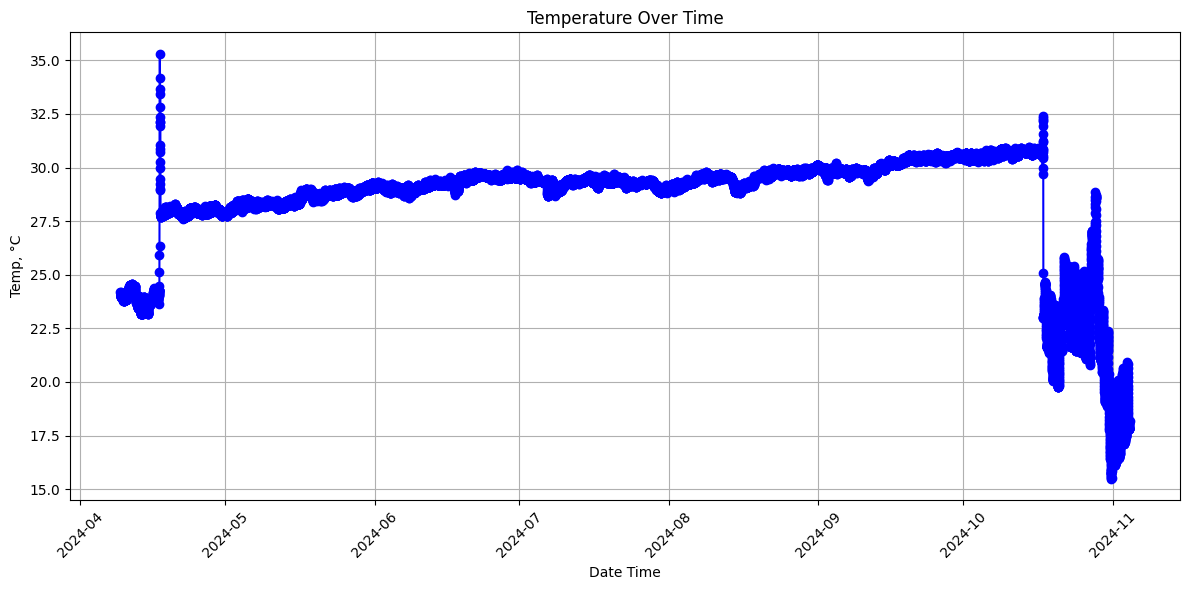

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


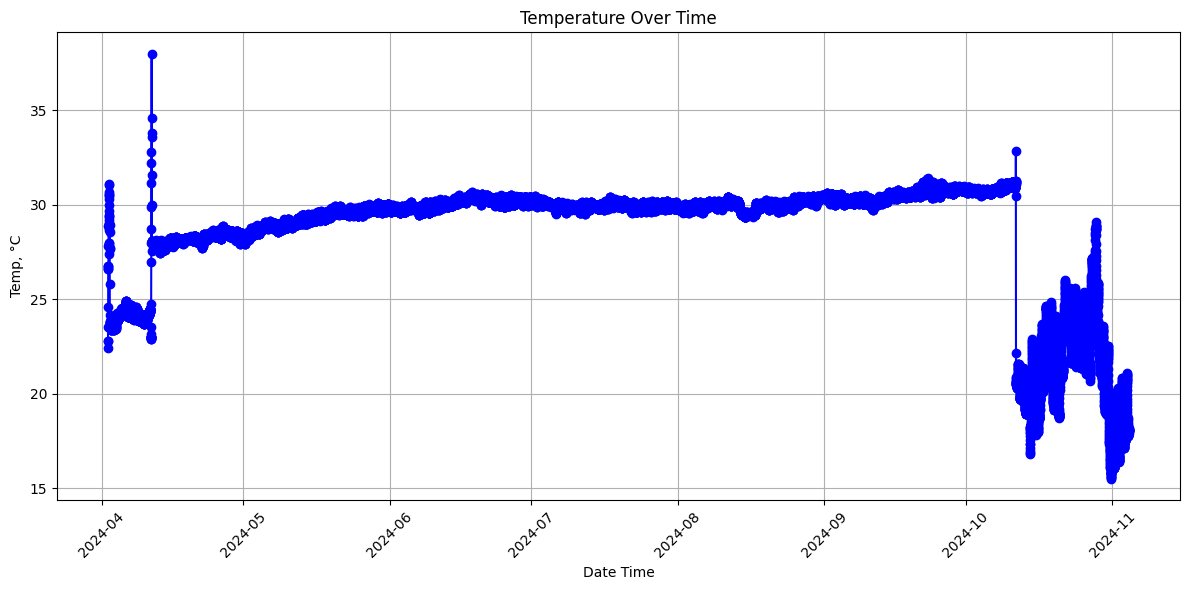

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


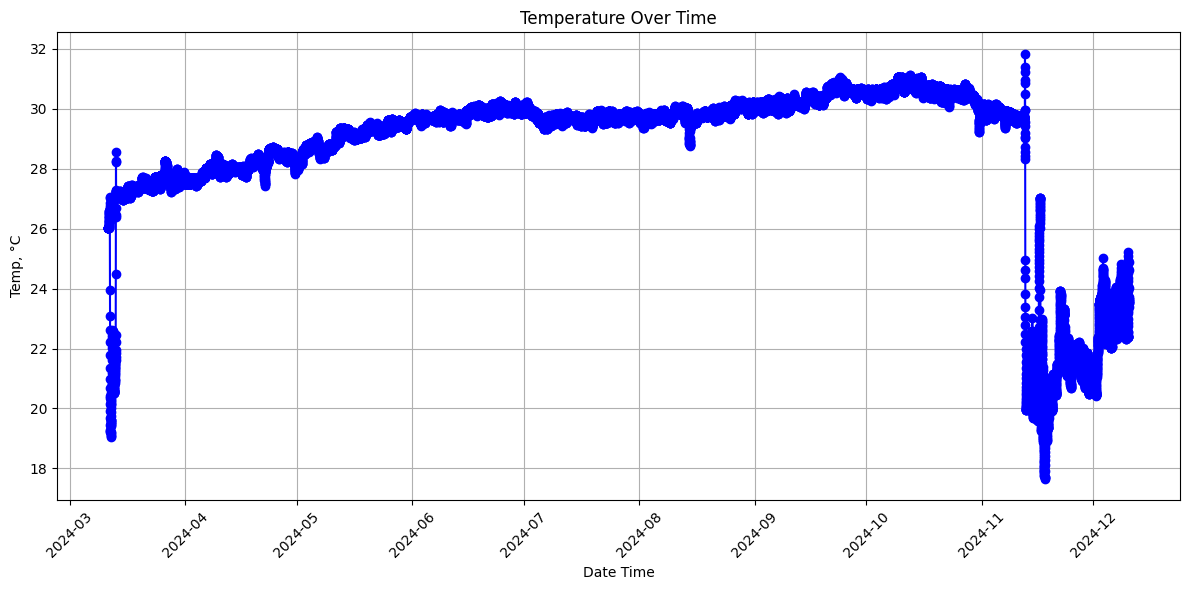

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


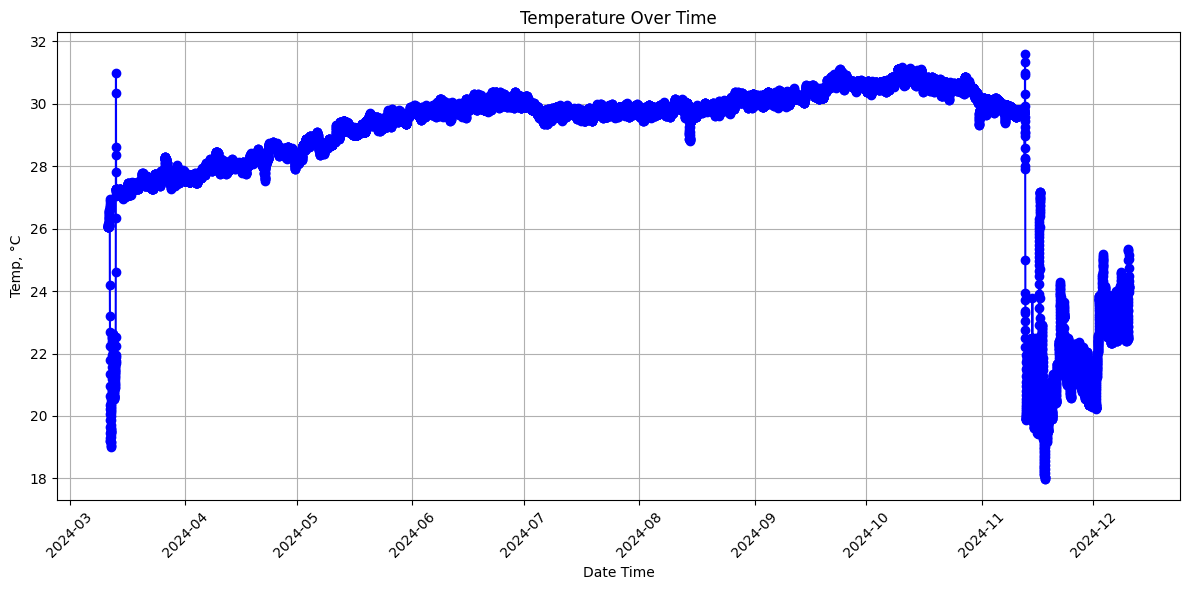

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


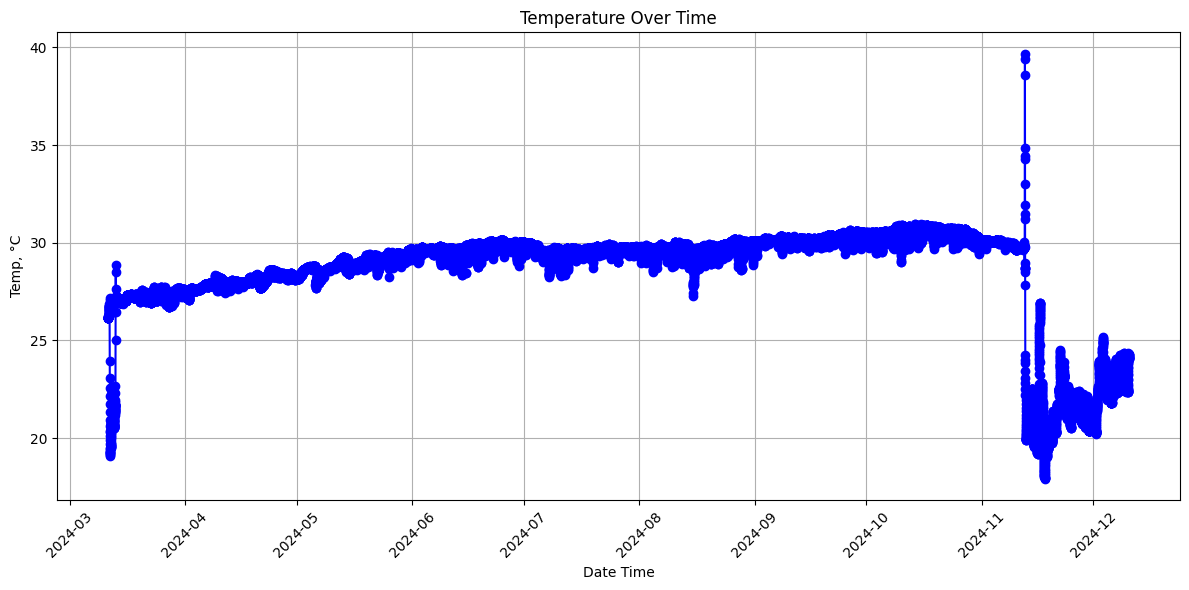

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


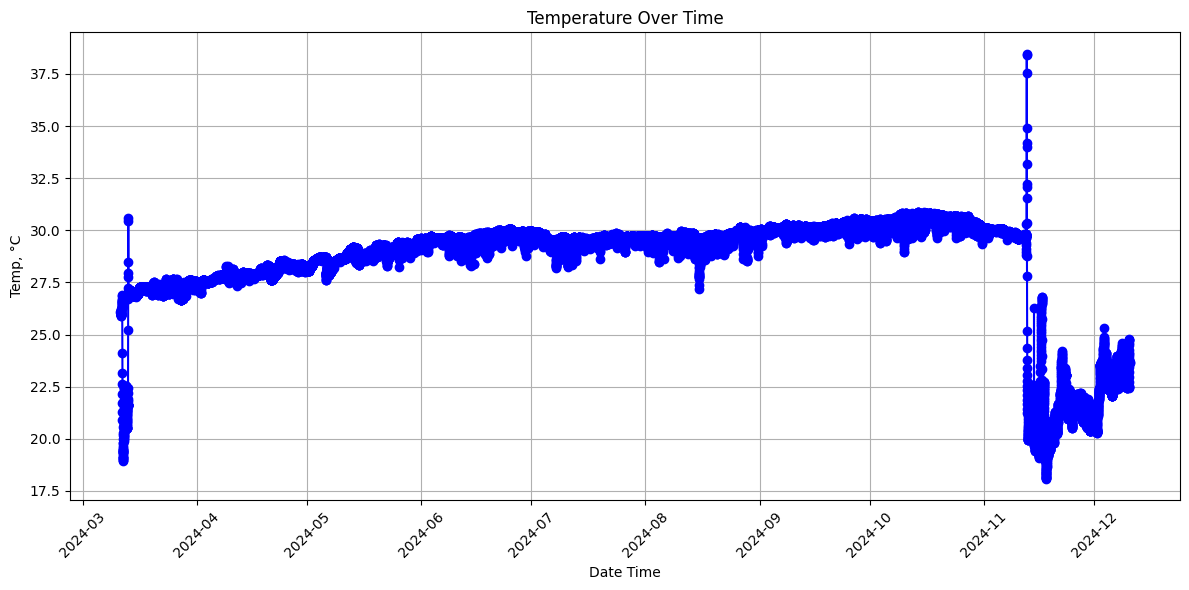

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


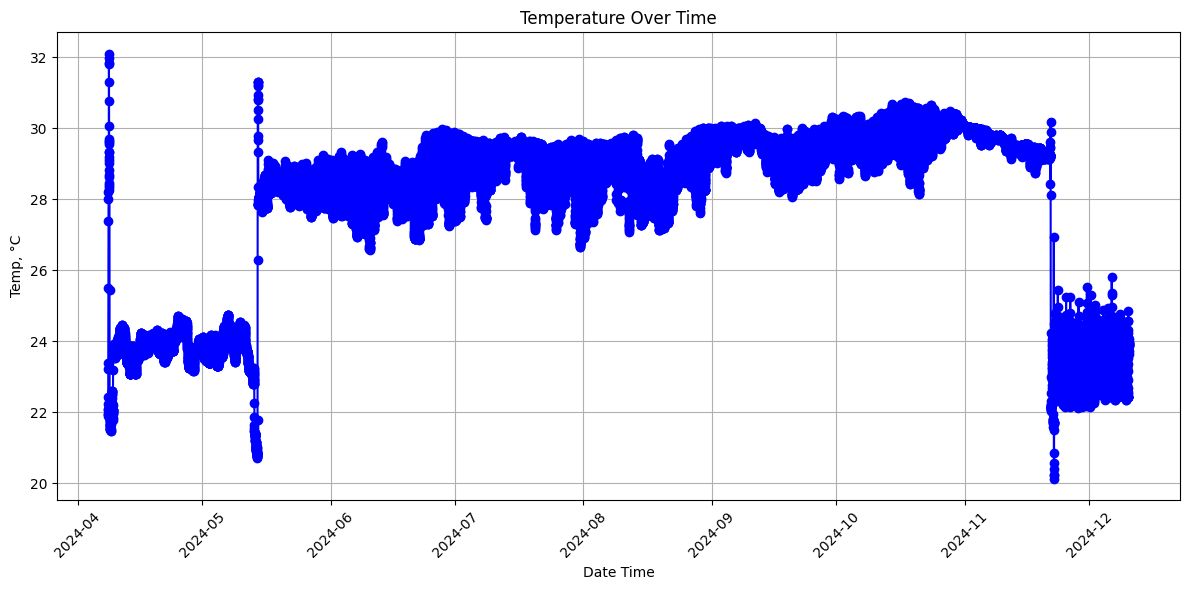

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


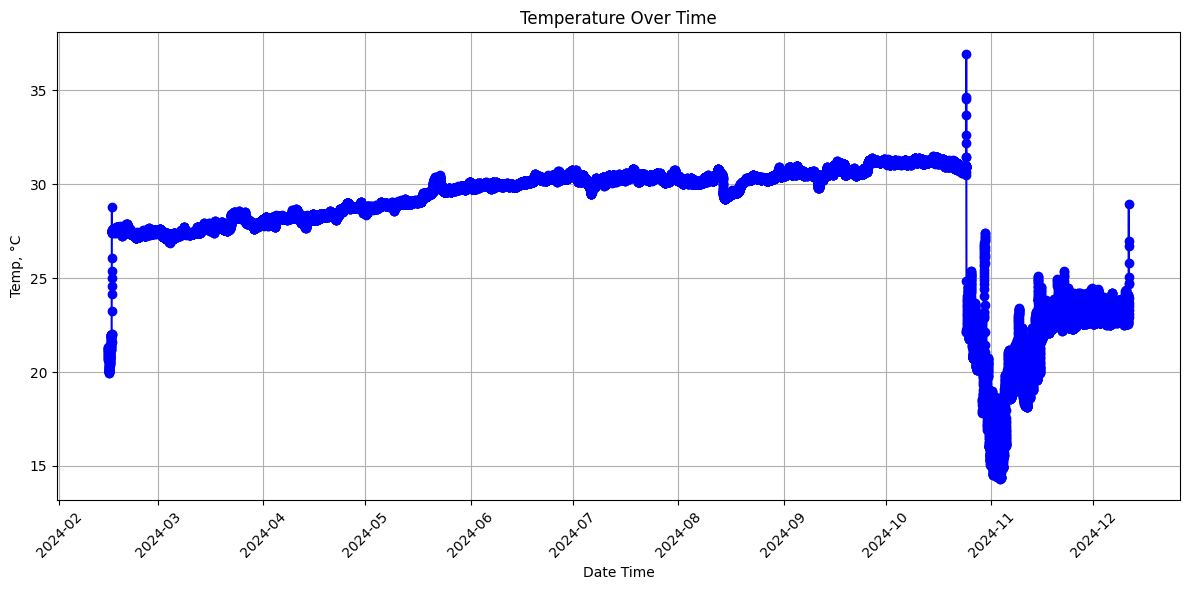

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


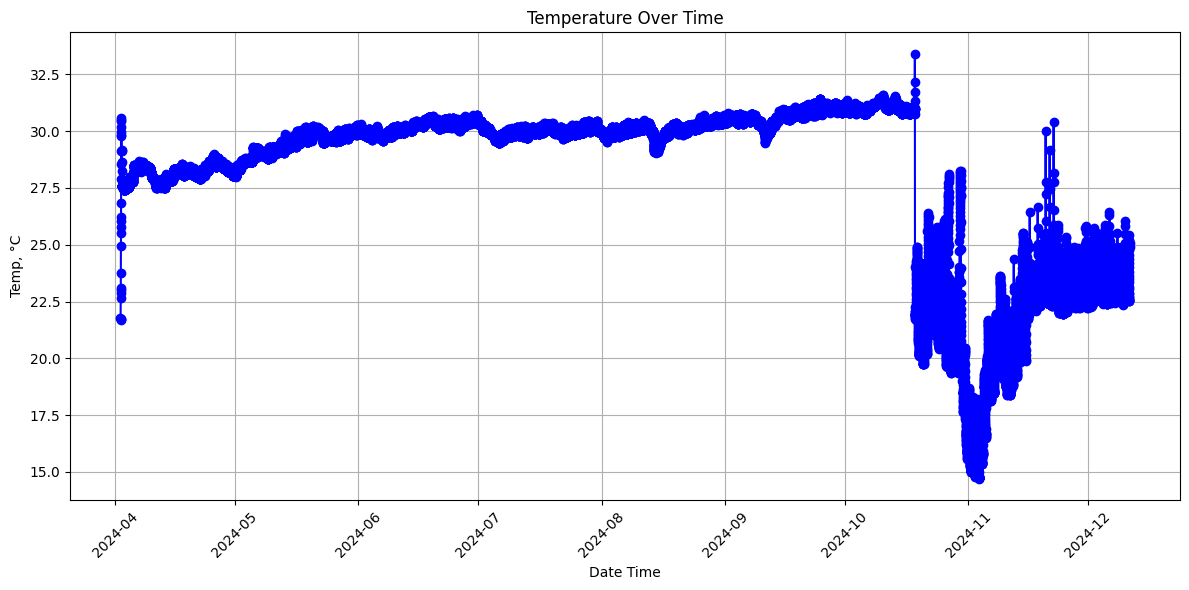

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


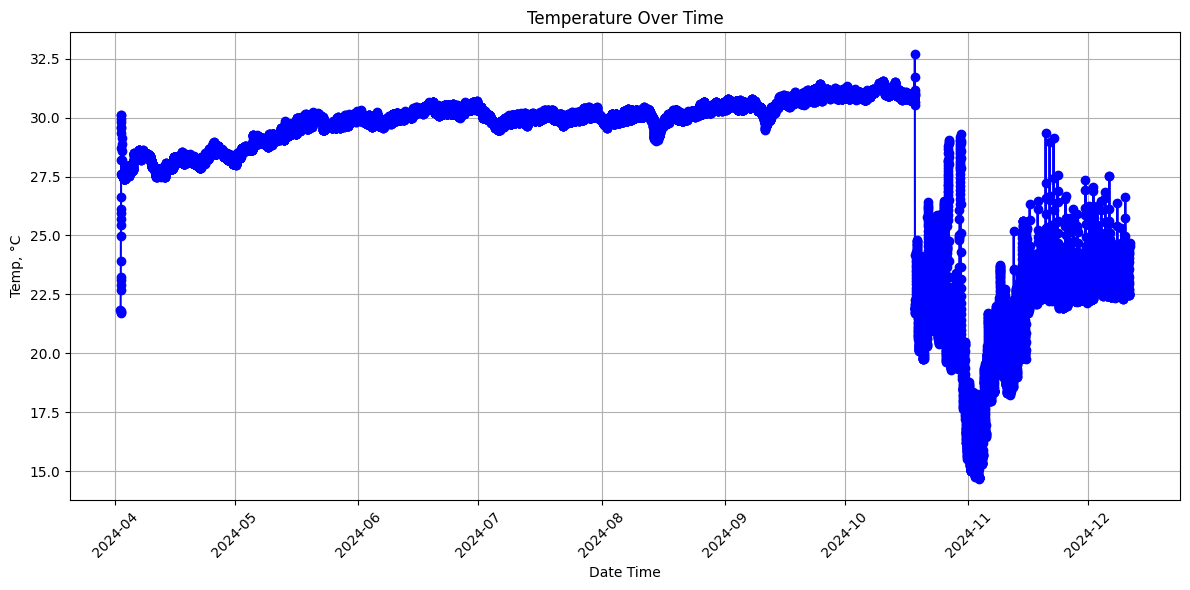

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


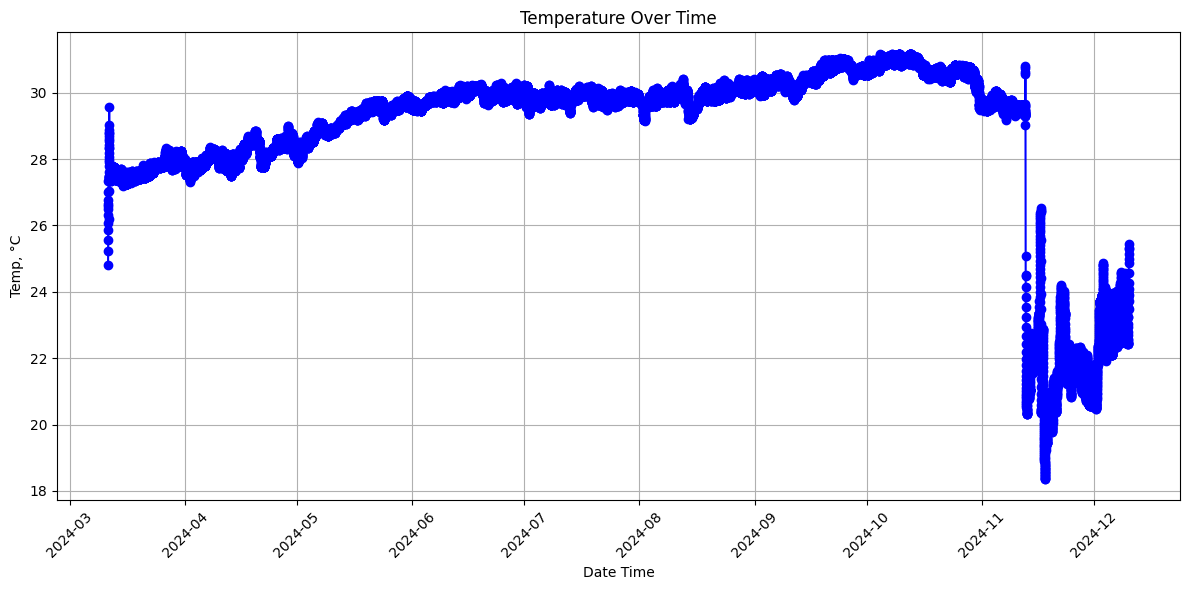

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


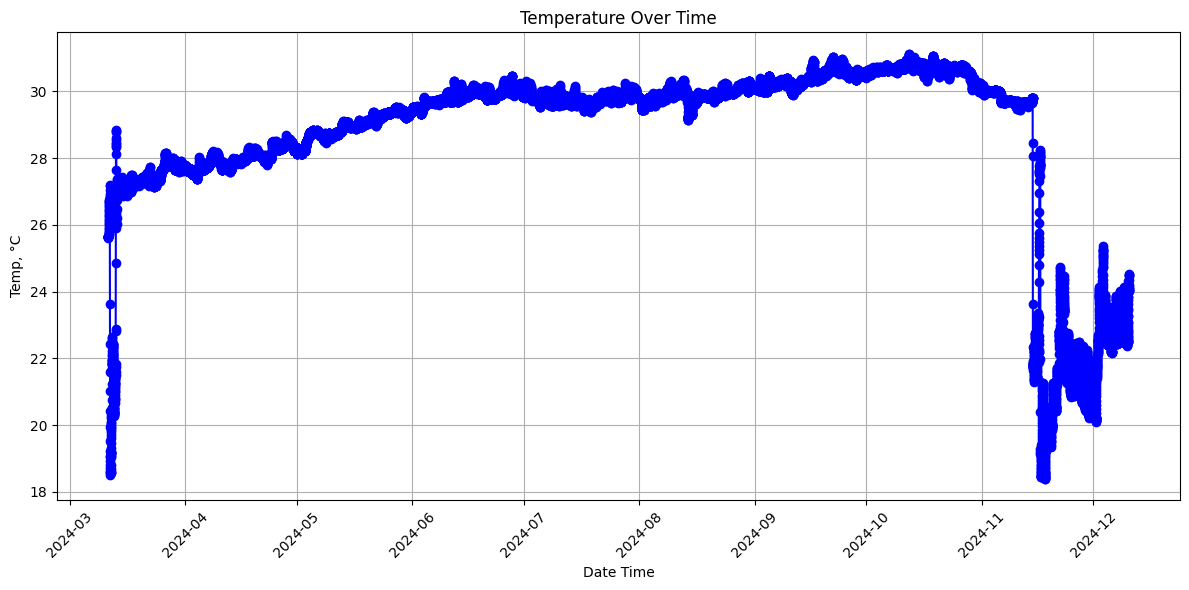

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


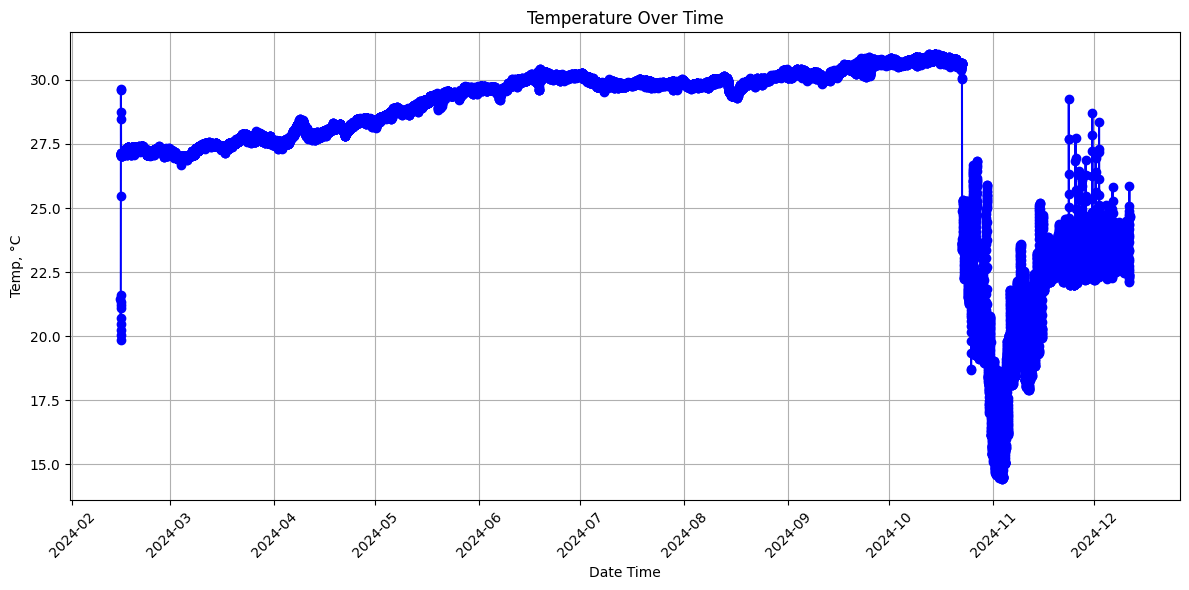

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


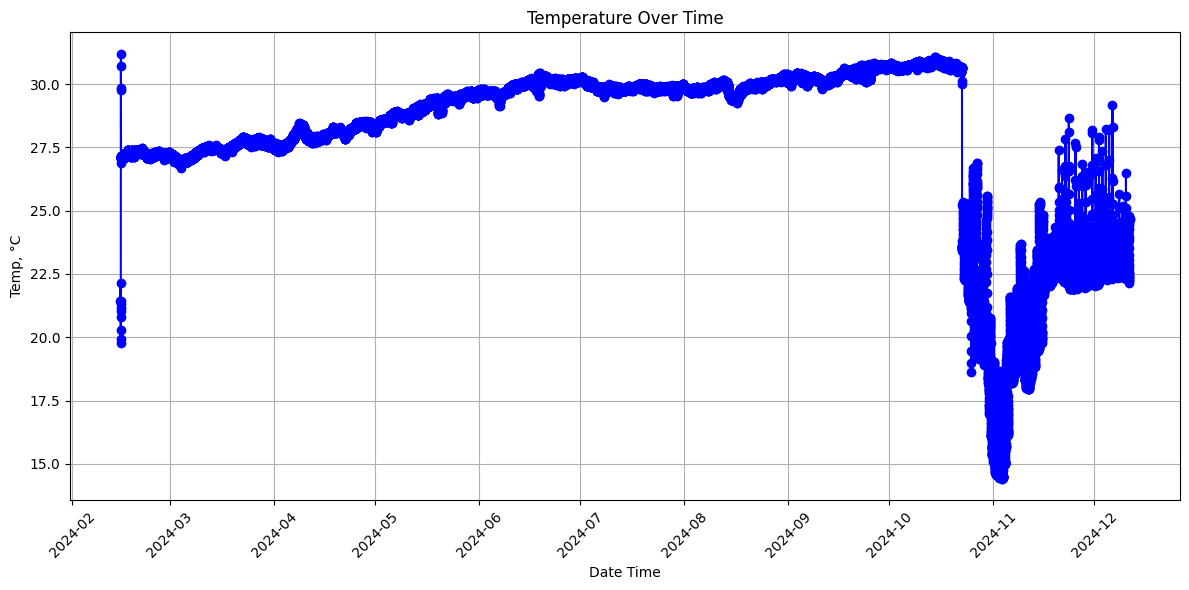

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


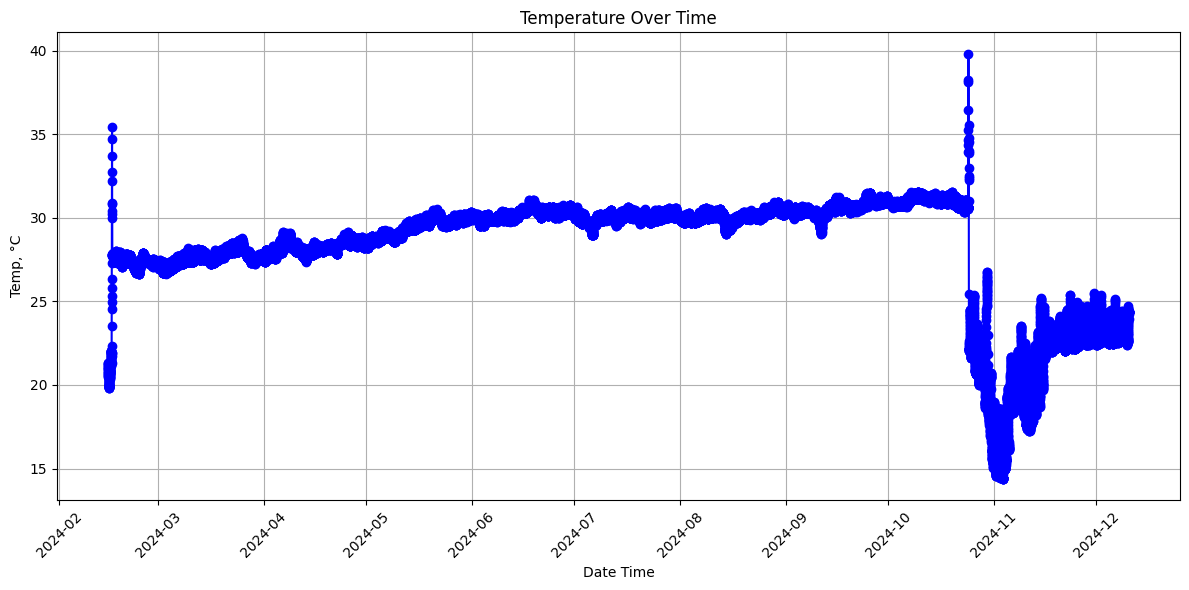

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


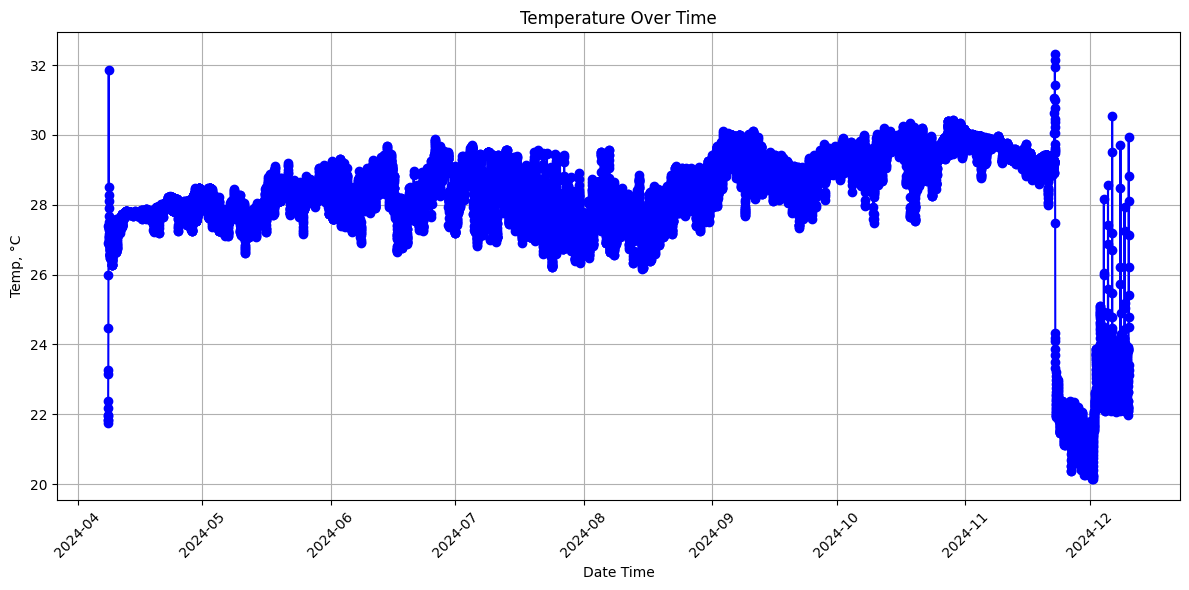

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


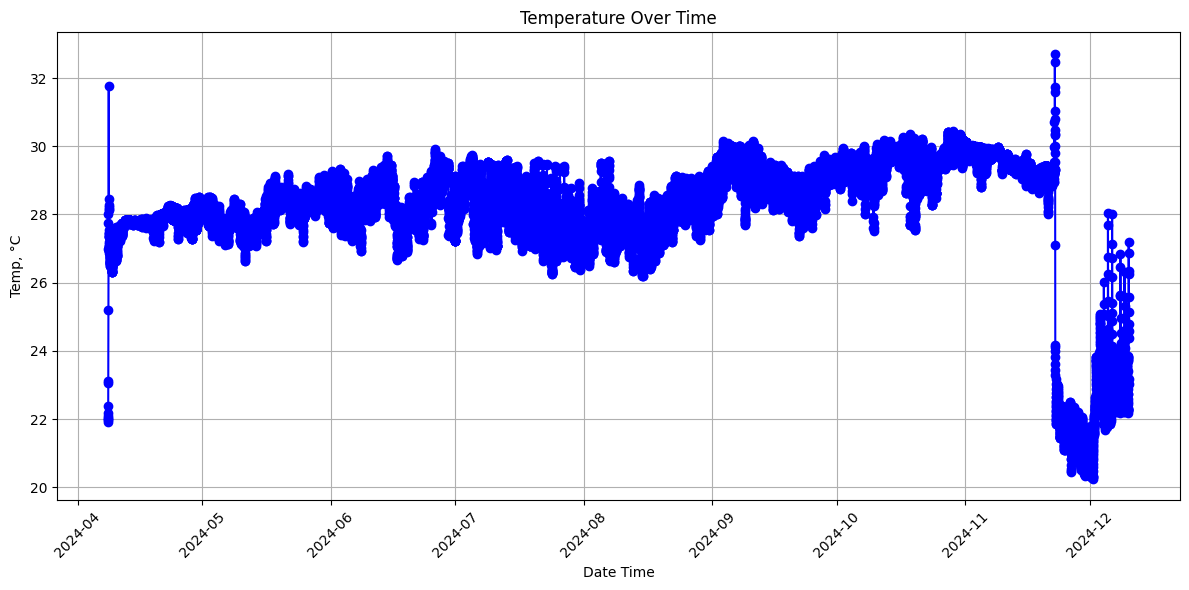

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


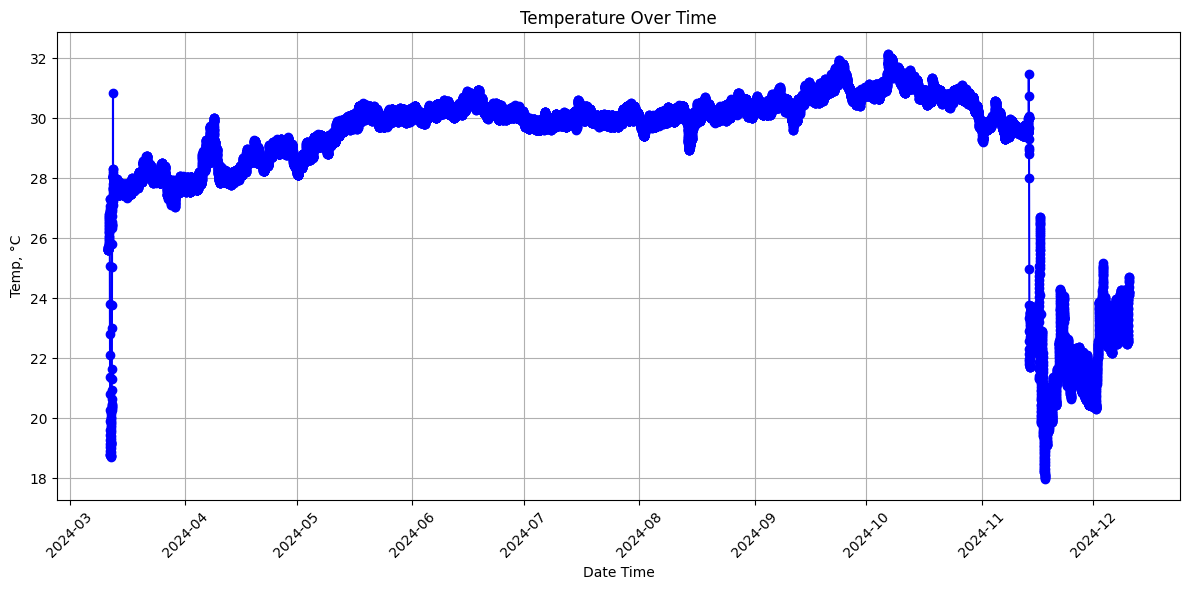

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


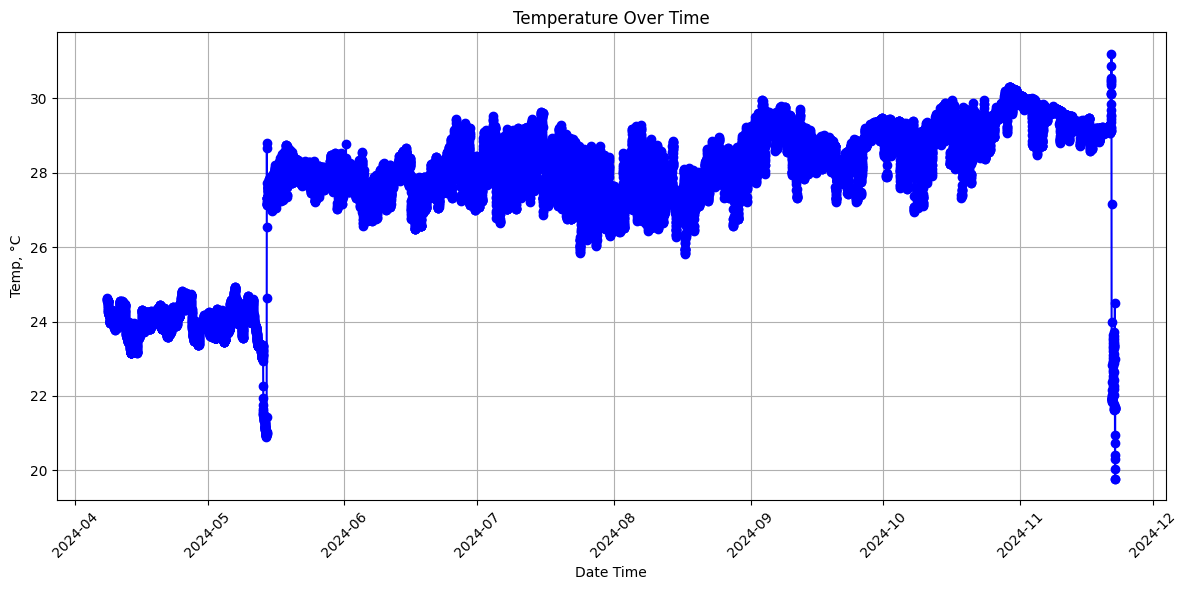

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


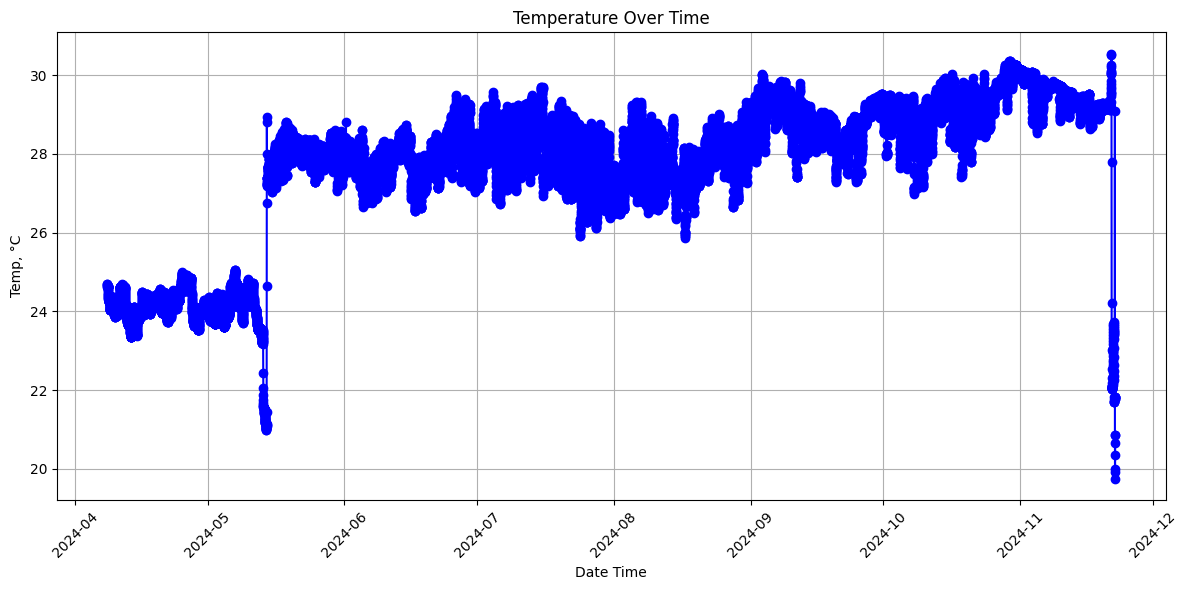

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


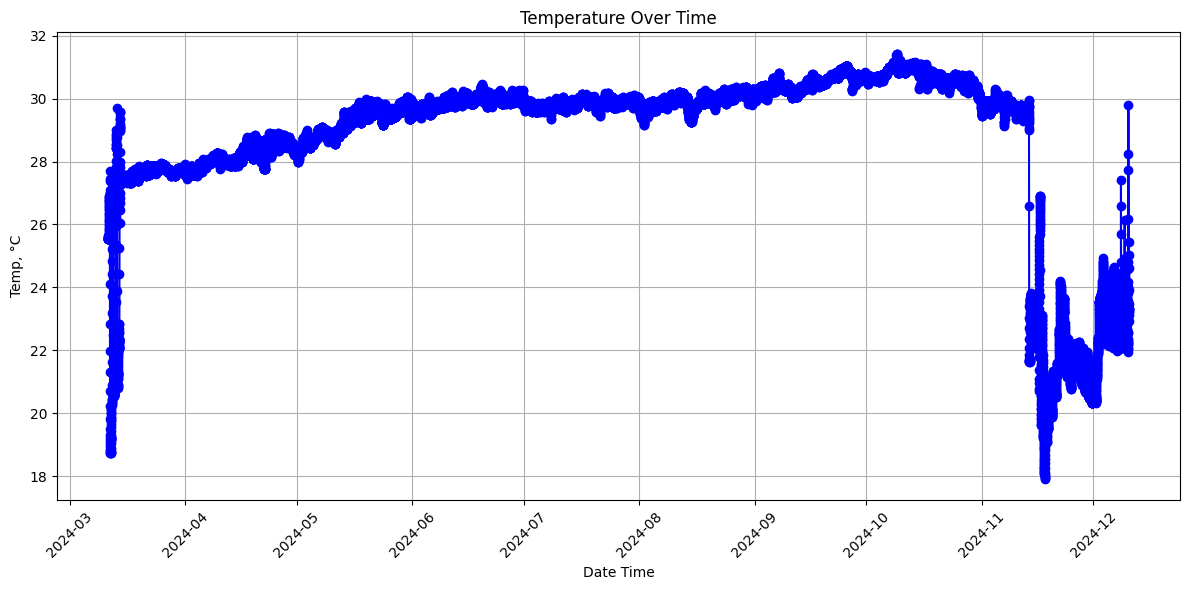

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


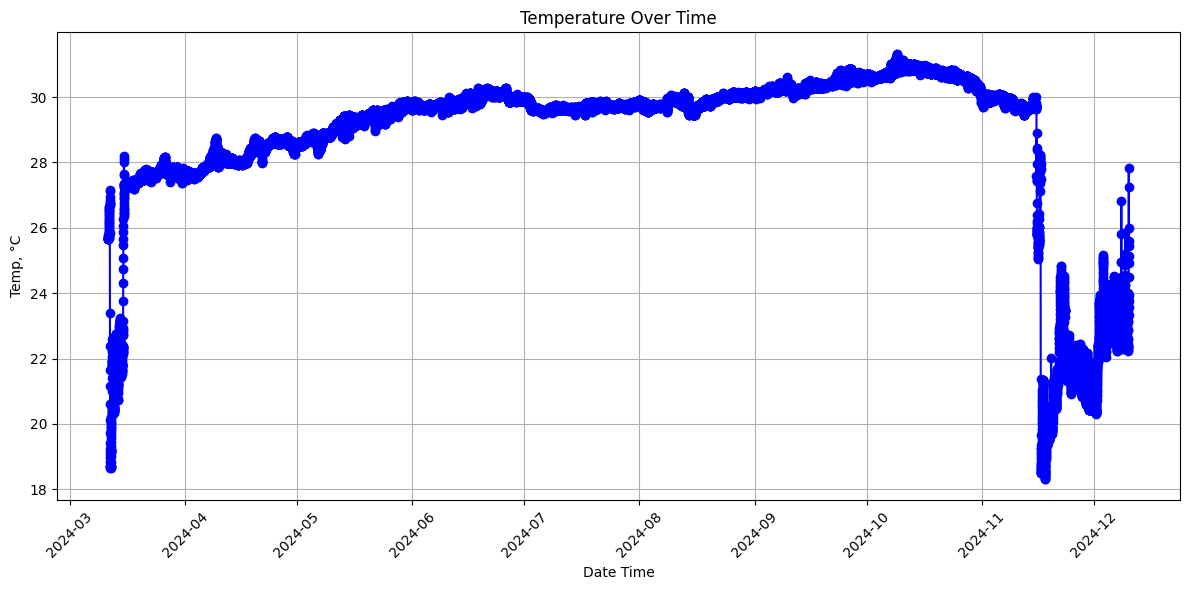

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


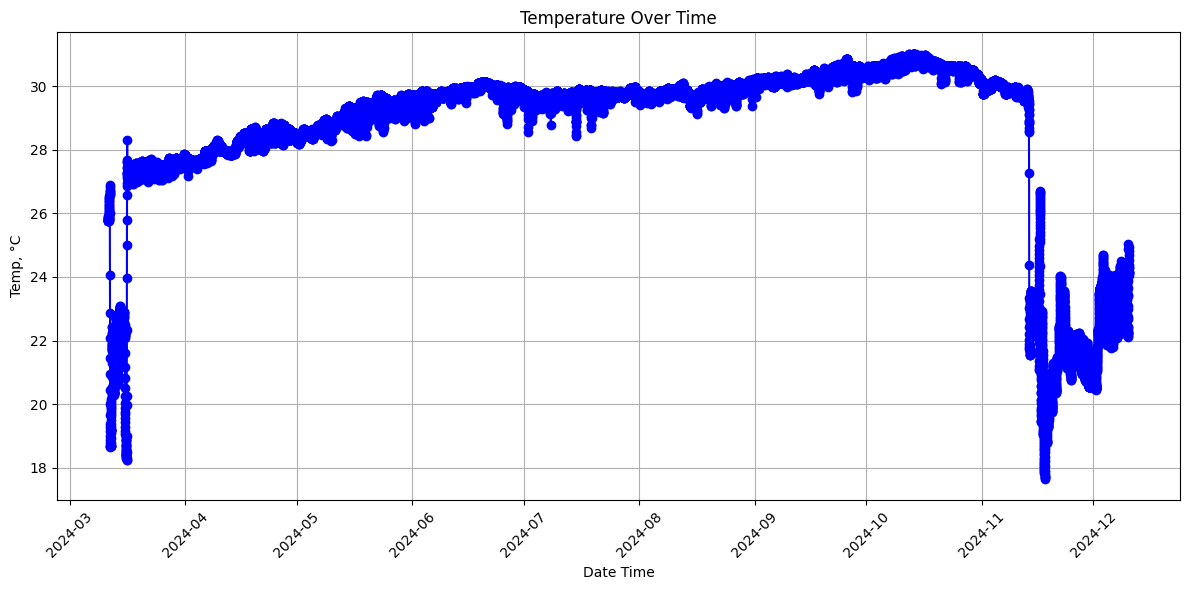

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


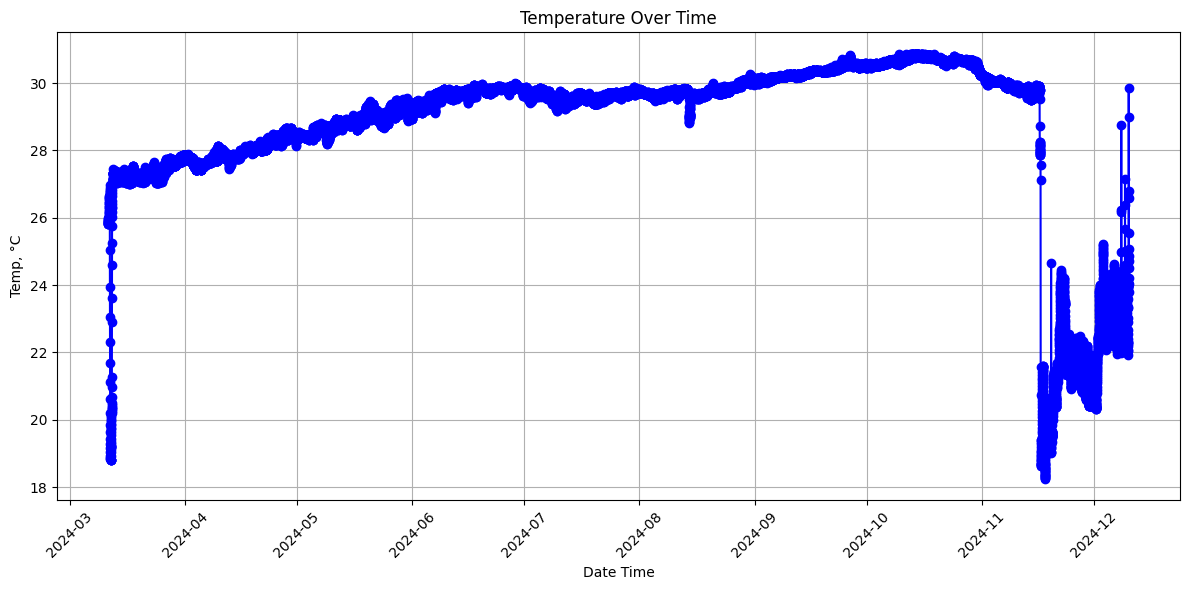

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


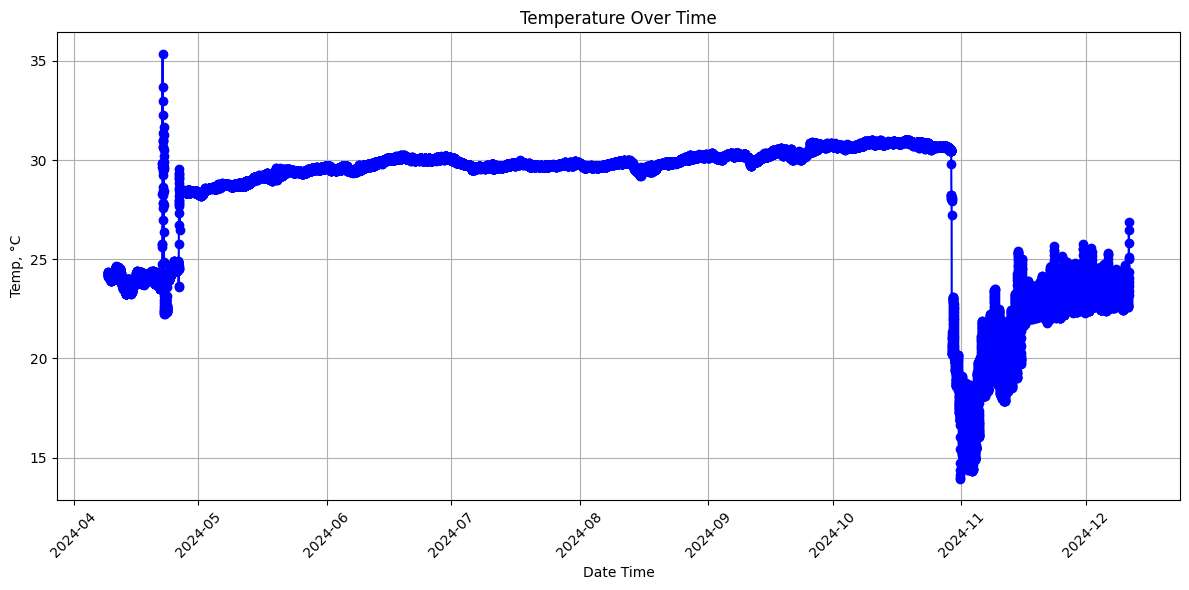

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


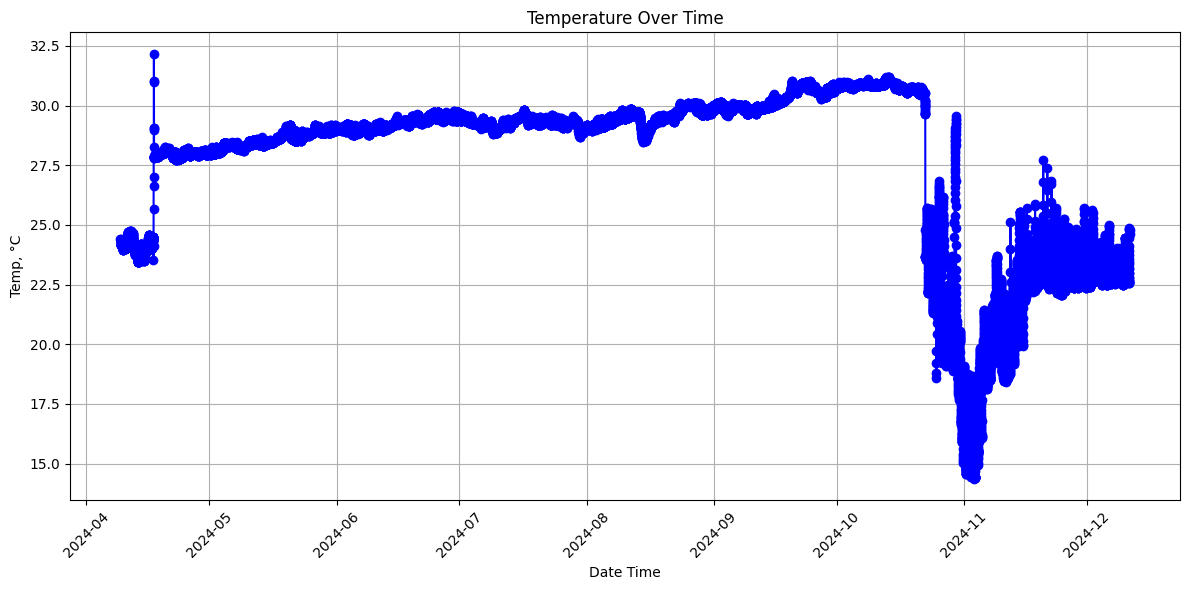

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


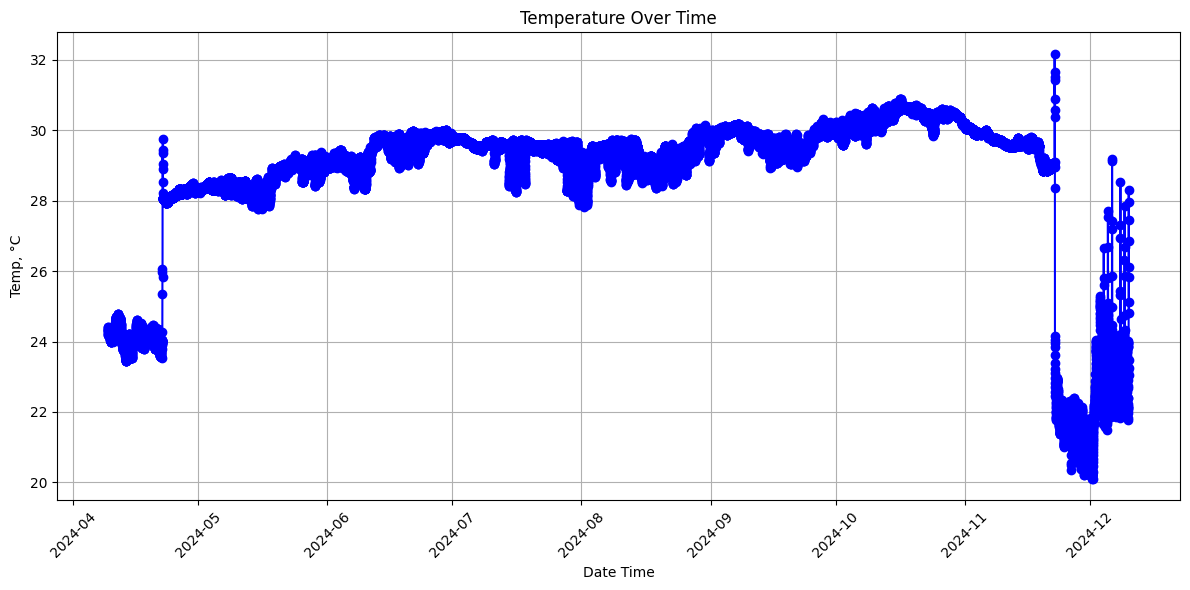

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


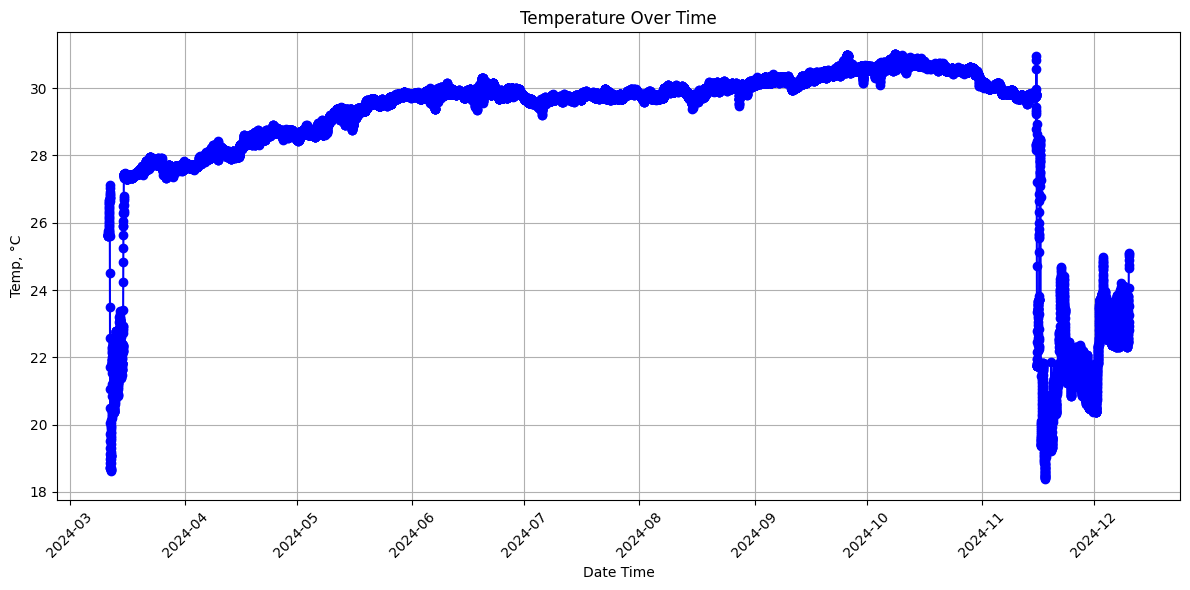

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


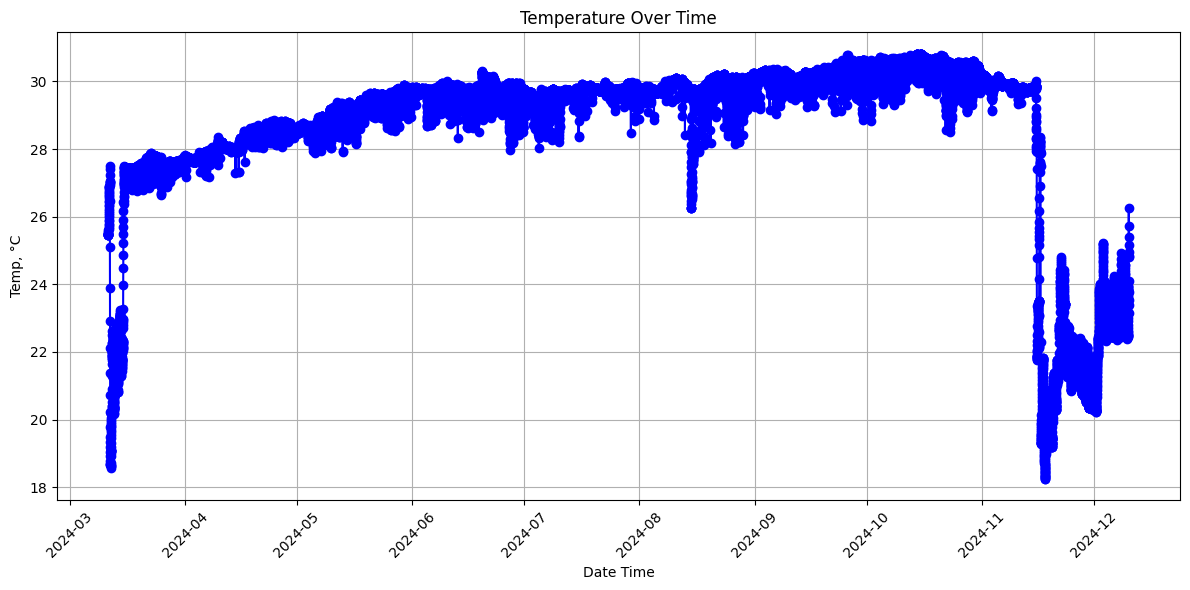

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


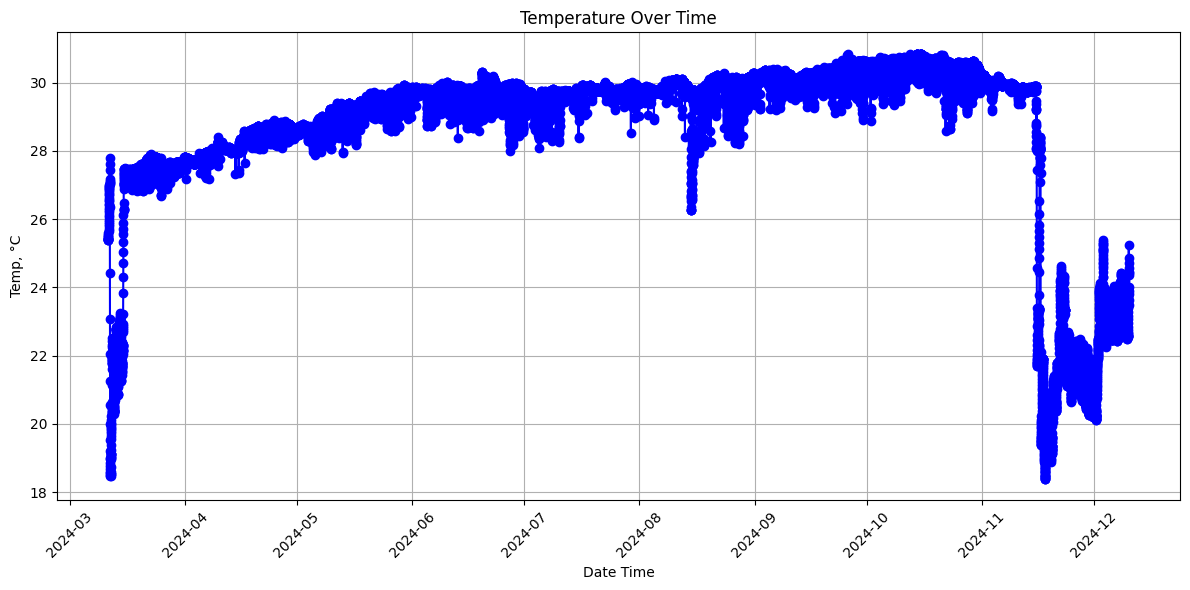

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


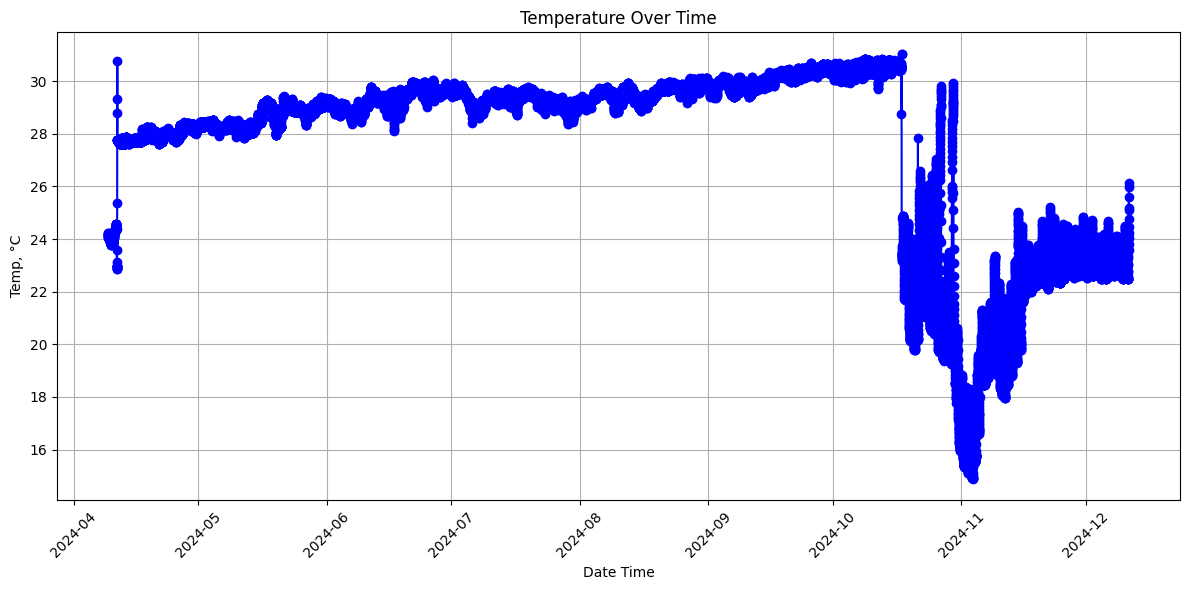

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


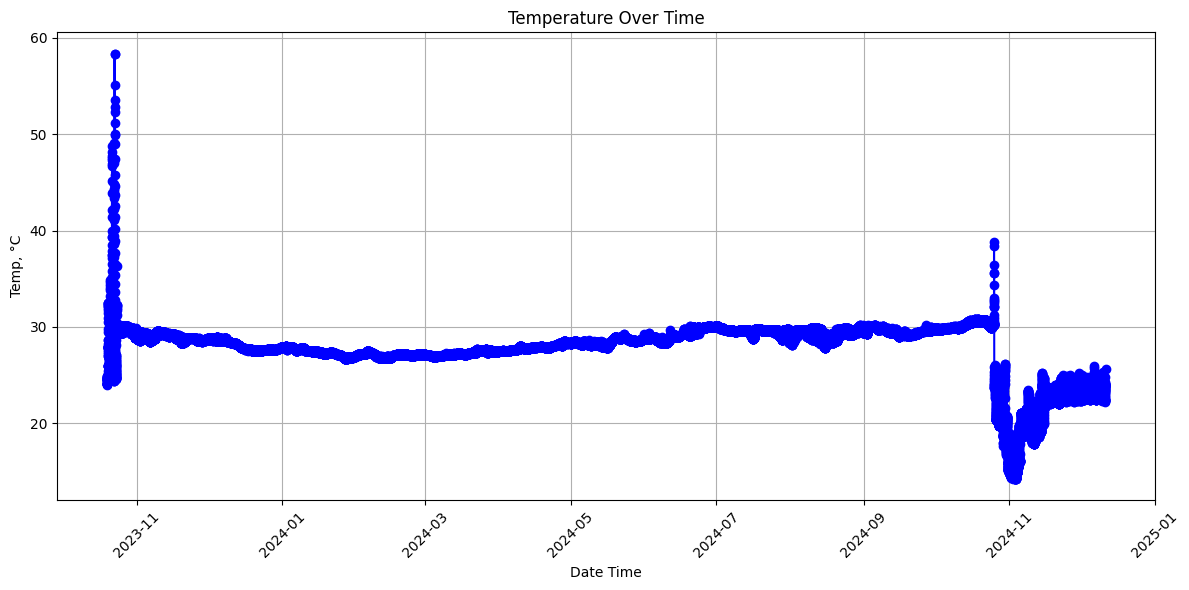

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


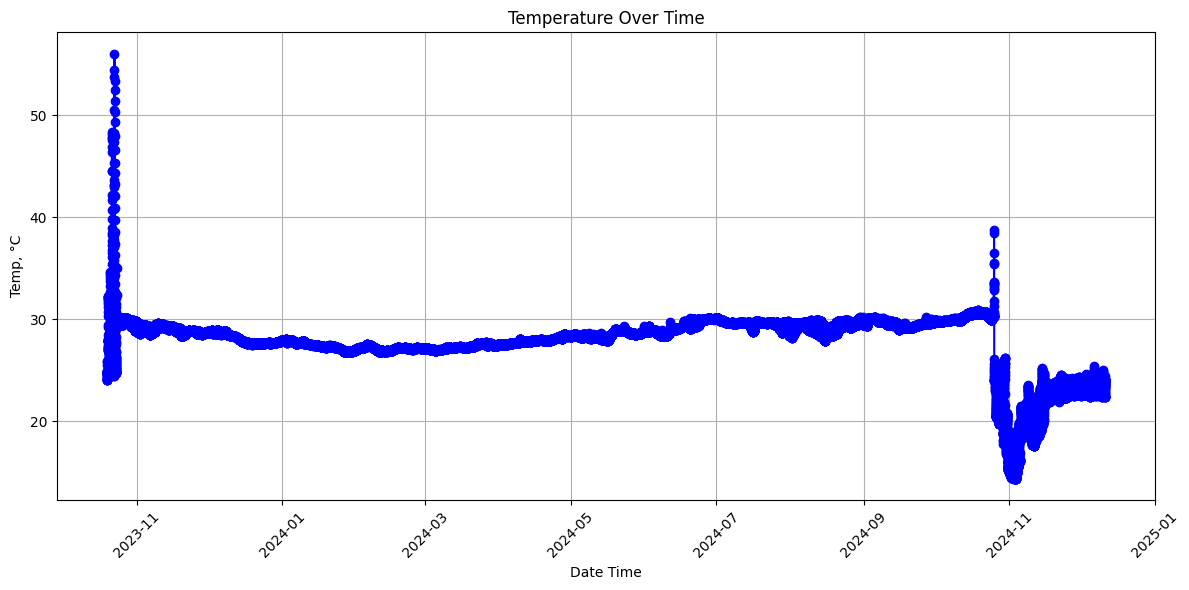

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


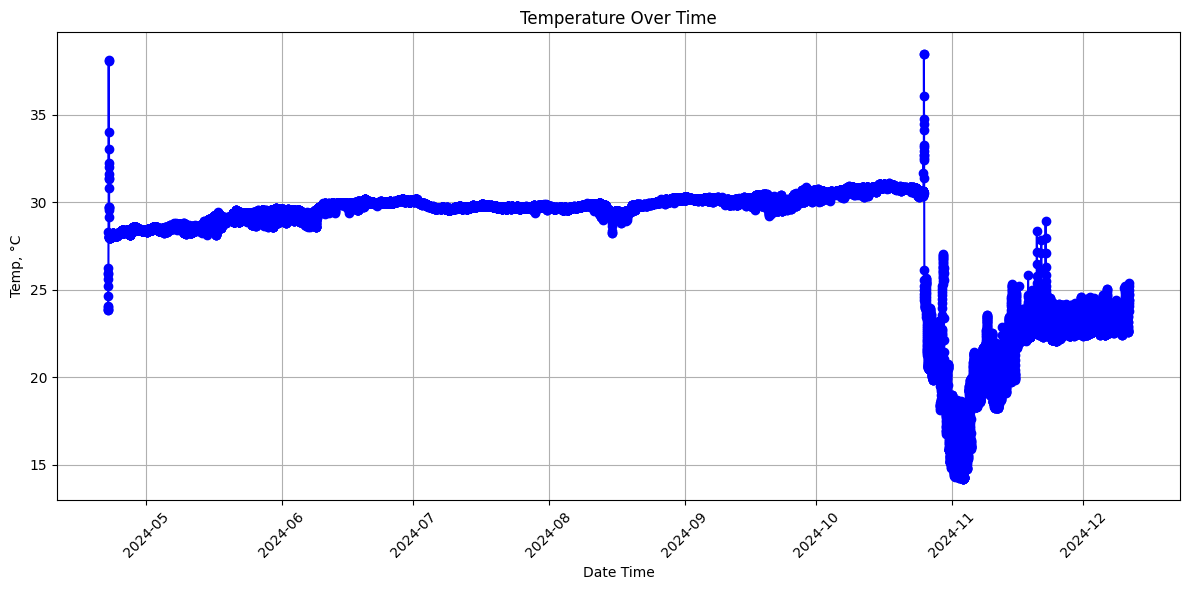

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


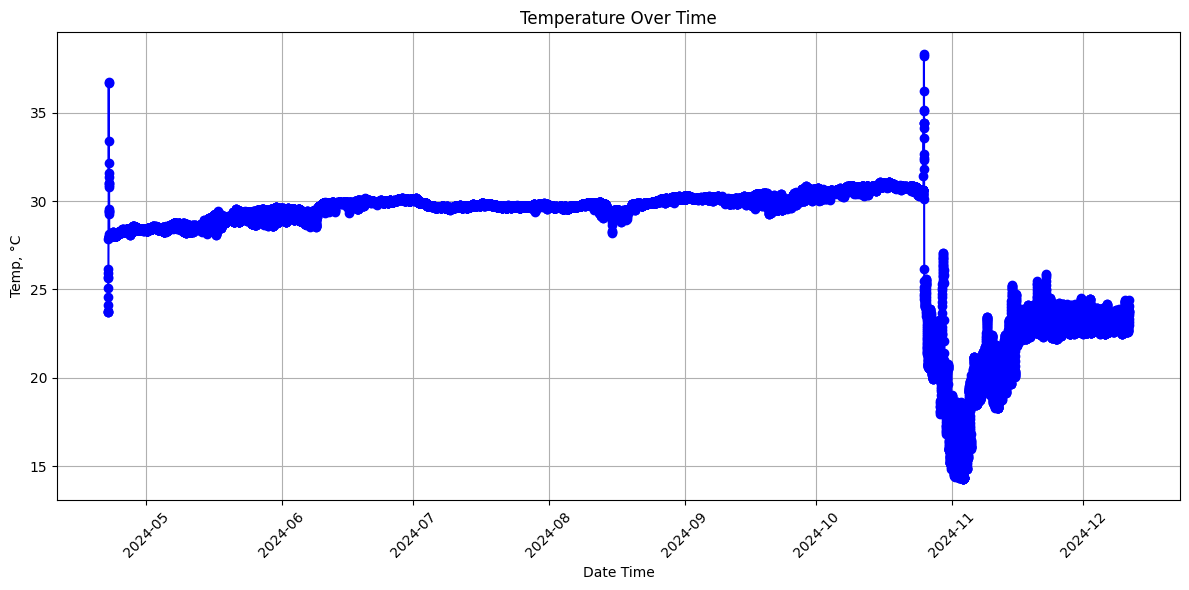

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


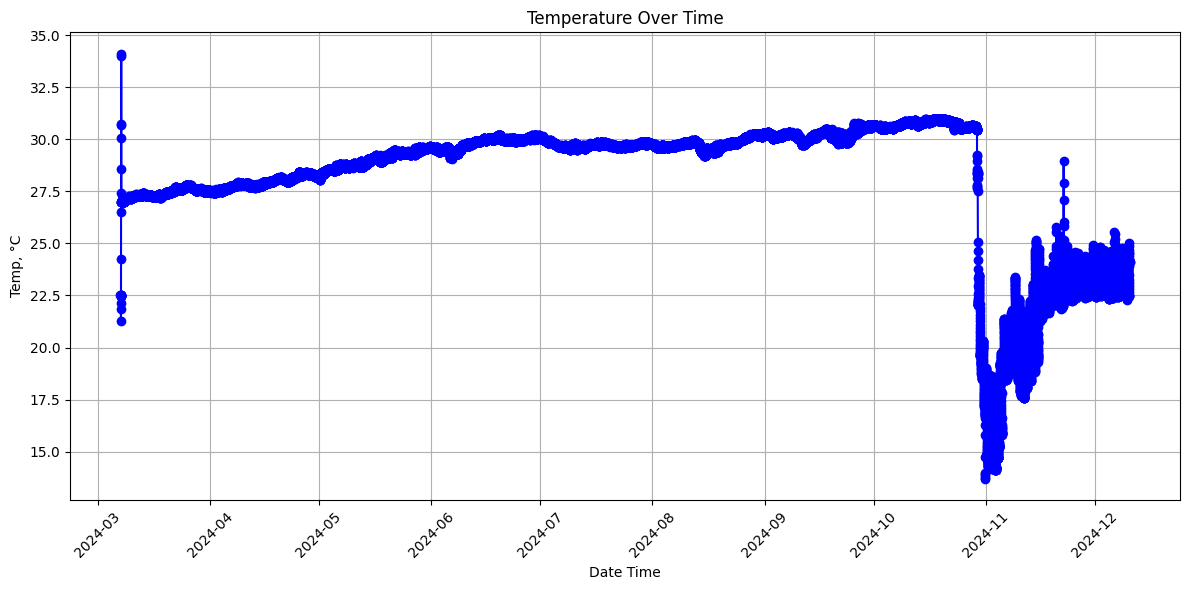

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


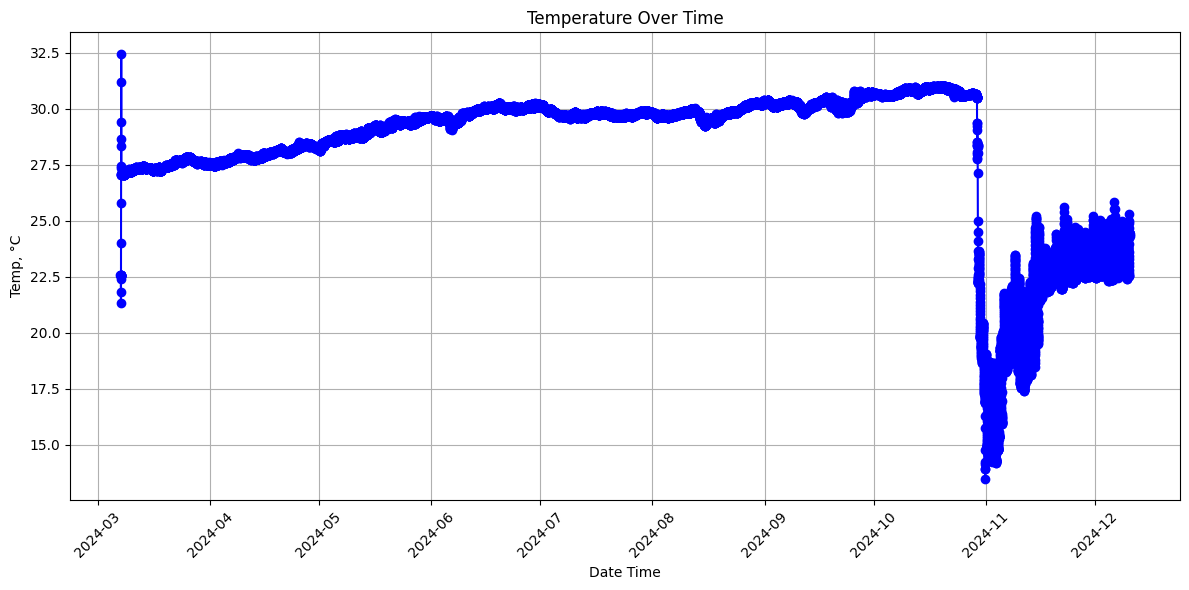

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


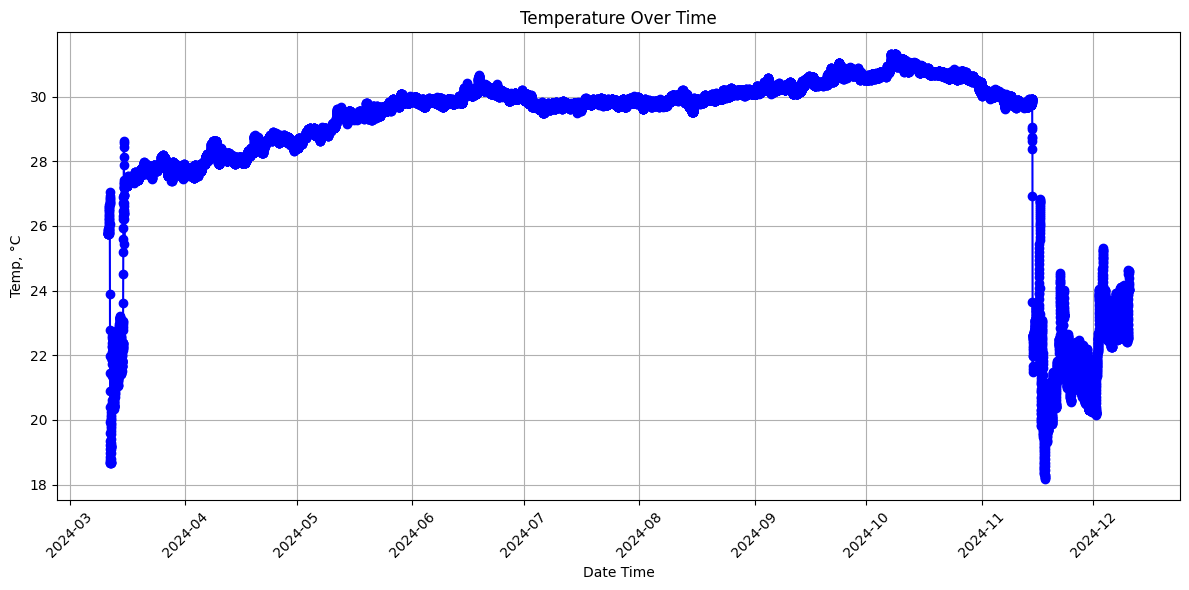

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


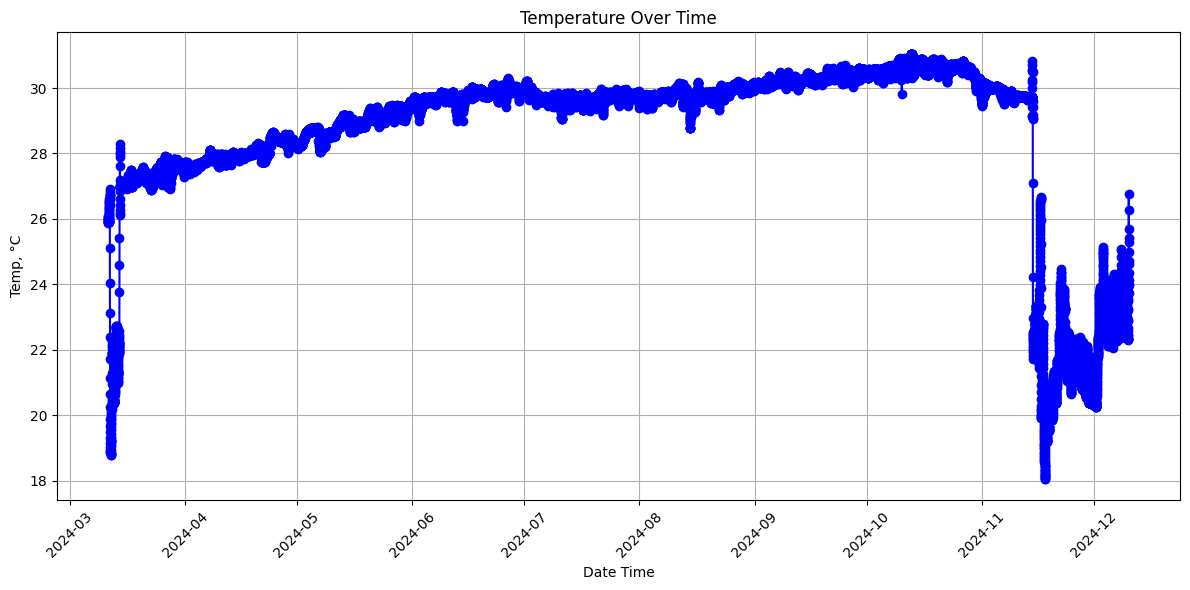

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


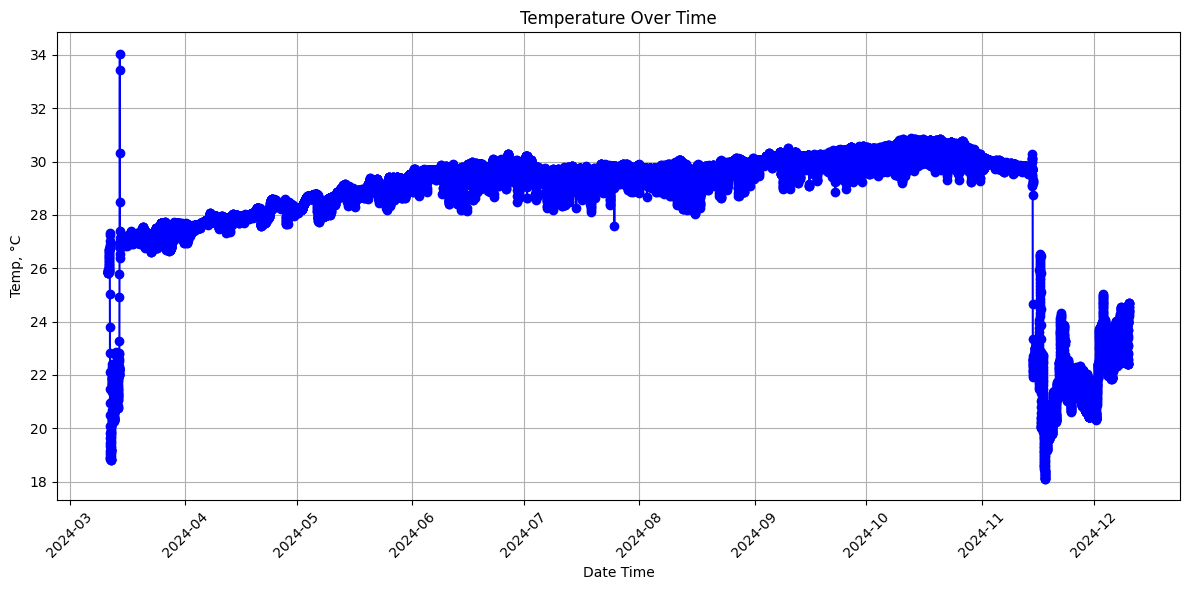

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


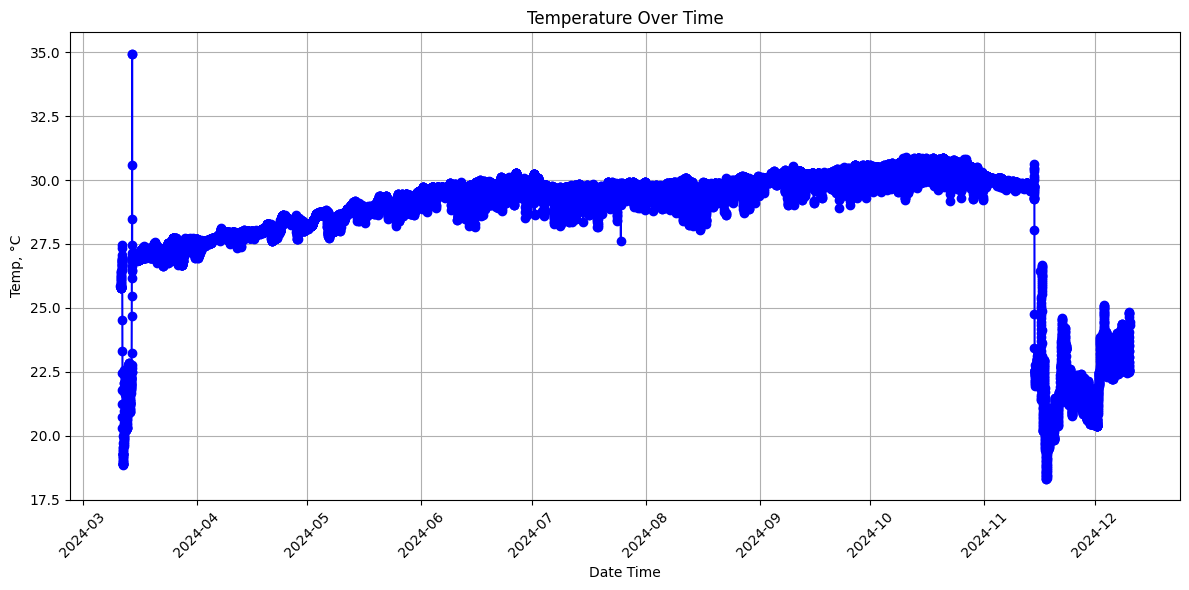

C:\Users\magic\AppData\Local\Temp\ipykernel_29152\2789196919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


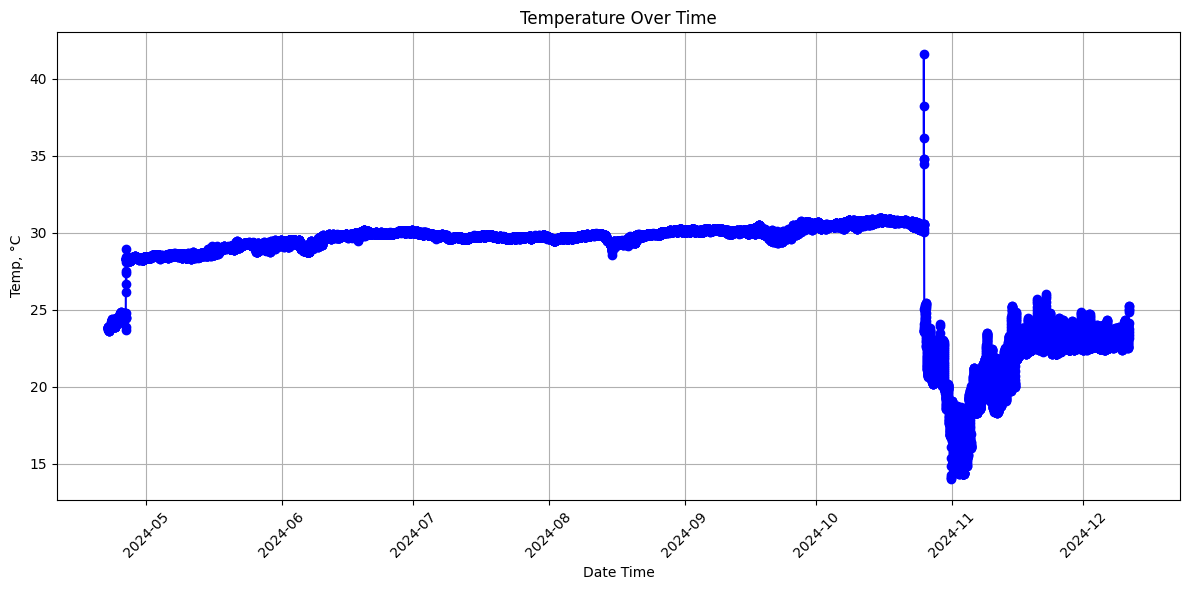

In [36]:
# Loop through df_files and plot graphs for each DataFrame
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame
            df = file_info['DataFrame']
            
            # Convert the 'Date Time, GMT-04:00' column to datetime format
            df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])

            # Plot the temperature over time
            plt.figure(figsize=(12, 6))
            plt.plot(df['Date Time, GMT-04:00'], df['Temp, °C'], color='blue', marker='o', linestyle='-')
            plt.title('Temperature Over Time')
            plt.xlabel('Date Time')
            plt.ylabel('Temp, °C')  # Modified label
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

### <b>Trim the data based on Date Time:
Trimming the data occurs in two steps, first is to trim the data based on the deployment log, then trim the data to account for human error. The cell below checks if the newly combined Date and Time values are a string and then formats it to a datetime object with the structure of m/d/y and h:m:s. 

In [37]:
#%% Trim Data Based on Date Time
# The data is being trimmed to the closest related start and endpoint 

# Convert timestamps to datetime objects in deployment_data_dict
for filename, file_info in deployment_data_dict.items():
    # Check if the values are already strings
    if isinstance(file_info['Date In Time In'], str):
        file_info['Date In Time In'] = datetime.strptime(file_info['Date In Time In'], '%m/%d/%y %H:%M:%S')
    if isinstance(file_info['Date Out Time Out'], str):
        file_info['Date Out Time Out'] = datetime.strptime(file_info['Date Out Time Out'], '%m/%d/%y %H:%M:%S')


### Trim part 1: deployment log
This cell trims the data based on the start and end times specified in the deployment log to the nearest point in the data

In [38]:
# Convert the 'Date Time, GMT-04:00' column to datetime format (This is here to make sure the datetime is converted if you skipped plotting)
df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])

# Trim the data in each DataFrame based on the specified time range
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            df = file_info['DataFrame']
            date_column = 'Date Time, GMT-04:00'  # Assuming this is the column containing timestamps
            
            # Convert the date column to datetime objects, specifying the format
           # df[date_column] = pd.to_datetime(df[date_column], format='%m/%d/%Y %H:%M')
            df[date_column] = pd.to_datetime(df[date_column], format='%m/%d/%y %H:%M:%S')
            
            # Filter the DataFrame based on the specified time range
            df = df[(df[date_column] >= deployment_data_dict[file_info['File Name']]['Date In Time In']) &
                    (df[date_column] <= deployment_data_dict[file_info['File Name']]['Date Out Time Out'])]
            
            # Update the DataFrame in df_files
            df_files[site_code][file_number][file_identifier]['DataFrame'] = df

### Trim part 2: account for human error
To remove the possibility of human error from deployment and retreival of the loggers, the loop iterates through the data frames and trims the first and last hour of the data. This section can be altered in the "trimmed_df = df.iloc[4:-5]" section based on outputs of graphing section of the code.

In [39]:
#%% Trim data down on both ends by an hour THIS SECTION CAN BE COMMENTED OUT IF FURTHER TRIMMING IS NOT REQUIRED.
# This is to eliminate any data errors from the removal and retrevial from the water.
# In terms of data processing it may be better to eliminate human error and just inerpolate these points
# When connecting the data to previous data. 

# Loop through each site code, file number, and file identifier in df_files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame for the current file
            df = file_info['DataFrame']
            
            # Reduce the number of start points 4 and end points by 5 on each end of the DataFrame
            trimmed_df = df.iloc[4:-5]
            
            # Update the DataFrame in df_files
            df_files[site_code][file_number][file_identifier]['DataFrame'] = trimmed_df

### Checking the lengths:
This loop makes sure that the number of rows for each site code are the same to ensure that they can be merged and then averaged. This would be the point to check for differences in time interval between the data pairs. If time interval is different they should have already been labeled as offset and handled.

In [40]:
#%% Checks to see if the "a" and "b" files and the "c" and "d" files have the same number of data points

# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are multiple file identifiers for the file number
        if len(identifiers) > 1:
            # Get the DataFrames associated with the current site code, file number, and identifiers
            data_frames = [info['DataFrame'] for identifier, info in identifiers.items()]
            
            # Get the number of rows for each DataFrame
            num_rows = [df.shape[0] for df in data_frames]
            
            # Check if files associated with the file number have different numbers of data points
            if len(set(num_rows)) != 1:
                print(f"Site code: {site_code}, File number: {file_number} have files with different numbers of data points.")
            else:
                print(f"Site code: {site_code}, File number: {file_number} have files with the same number of data points: {num_rows[0]}.")

Site code: TCBKIX, File number: 2403 have files with the same number of data points: 23501.
Site code: TCBKPT, File number: 2402 have files with the same number of data points: 22918.
Site code: TCCB08, File number: 2403 have files with the same number of data points: 23418.
Site code: TCCB40, File number: 2403 have files with the same number of data points: 23417.
Site code: TCCORK, File number: 2404 have files with the same number of data points: 19088.
Site code: TCFLTC, File number: 2402 have files with the same number of data points: 24002.
Site code: TCGMKT, File number: 2404 have files with the same number of data points: 21873.
Site code: TCHB40, File number: 2404 have files with the same number of data points: 18329.
Site code: TCMT40, File number: 2403 have files with the same number of data points: 23504.
Site code: TCSC35, File number: 2310 have files with the same number of data points: 35317.
Site code: TCSCAP, File number: 2404 have files with the same number of data poi

In [ ]:
#calls a dataframe
#print(df_files['TCBKIX']['2210']['a'])

### Calculations check:
To merge the duplicate temperature columns, the difference between each temperature must be checked before they can be averaged. After checking if there is an a and b file for each site code, the code then takes the absoulte value of the difference between them. 

In [41]:
#%% Check to see if there is a .2 degrees difference then average the two columns and record the site codes where this occured 
# Also take the average between the two temperature columns if the difference is less than or equal to .2 degrees.
# Use the new average temperature column as the temperature column 
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are both 'a' and 'b' files for the current site code and file number
        if 'a' in identifiers and 'b' in identifiers:
            # Get the 'a' and 'b' dataframes
            df_a = identifiers['a']['DataFrame']
            df_b = identifiers['b']['DataFrame']
            
            # Check if the temperature columns exist in both dataframes
            if 'Temp, °C' in df_a.columns and 'Temp, °C' in df_b.columns:
                # Calculate the temperature difference
                df_a['Temperature_Difference'] = abs(df_a['Temp, °C'] - df_b['Temp, °C'])
            else:
                print(f"Temperature columns not found for Site: {site_code}, File Number: {file_number}")
        else:
            print(f"Only one file for Site: {site_code}, File Number: {file_number}, so averaging could not occur")

Only one file for Site: TCBKIT, File Number: 2404, so averaging could not occur
Only one file for Site: TCBOTB, File Number: 2404, so averaging could not occur
Only one file for Site: TCBRWB, File Number: 2404, so averaging could not occur
Only one file for Site: TCCLGE, File Number: 2404, so averaging could not occur
Only one file for Site: TCCORB, File Number: 2402, so averaging could not occur
Only one file for Site: TCCSTL, File Number: 2403, so averaging could not occur
Only one file for Site: TCEAGR, File Number: 2403, so averaging could not occur
Only one file for Site: TCFSHB, File Number: 2402, so averaging could not occur
Only one file for Site: TCGRPD, File Number: 2403, so averaging could not occur
Only one file for Site: TCJCKB, File Number: 2403, so averaging could not occur
Only one file for Site: TCKNGC, File Number: 2403, so averaging could not occur
Only one file for Site: TCLBEM, File Number: 2403, so averaging could not occur
Only one file for Site: TCLBRH, File Num

### Merge the offset files:
This loop checks if the c and d identifiers exist within the files. If they exist, then the code gets the data frame for each and merges them based on the Date Time column. For the instances where the merge occured, a new identifier is added to the df_files dictionary called 'merged'.

In [24]:
#%% If dataframes are 'c' and 'd' then merge the dataframes on the 'Date Time, GMT-04:00'
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if 'c' and 'd' identifiers exist for the current site code and file number
        if 'c' in identifiers and 'd' in identifiers:
            # Get the 'c' and 'd' DataFrames
            df_c = identifiers['c']['DataFrame']
            df_d = identifiers['d']['DataFrame']
            
            # Check if the 'Date Time, GMT-04:00' column exists in both DataFrames
            if 'Date Time, GMT-04:00' in df_c.columns and 'Date Time, GMT-04:00' in df_d.columns:
                # Merge the DataFrames on the 'Date Time, GMT-04:00' column
                merged_df = pd.merge(df_c, df_d, on='Date Time, GMT-04:00', how='outer', suffixes=('_c', '_d'))
                
                # Add the merged DataFrame to df_files under a new identifier 'merged'
                df_files[site_code][file_number]['merged'] = {'DataFrame': merged_df, 'File Name': 'merged'}
                
                # Optionally, you can drop the 'c' and 'd' DataFrames if needed
                # del df_files[site_code][file_number]['c']
                # del df_files[site_code][file_number]['d']
            else:
                print(f"'Date Time, GMT-04:00' column not found in 'c' or 'd' DataFrame for Site: {site_code}, File Number: {file_number}")
        else:
            print(f"Only one file for Site: {site_code}, File Number: {file_number}, so merging could not occur")

Only one file for Site: TCBKIT, File Number: 2404, so merging could not occur
Only one file for Site: TCBKIX, File Number: 2403, so merging could not occur
Only one file for Site: TCBKPT, File Number: 2402, so merging could not occur
Only one file for Site: TCBOTB, File Number: 2404, so merging could not occur
Only one file for Site: TCBRWB, File Number: 2404, so merging could not occur
Only one file for Site: TCCB08, File Number: 2403, so merging could not occur
Only one file for Site: TCCB40, File Number: 2403, so merging could not occur
Only one file for Site: TCCLGE, File Number: 2404, so merging could not occur
Only one file for Site: TCCORB, File Number: 2402, so merging could not occur
Only one file for Site: TCCORK, File Number: 2404, so merging could not occur
Only one file for Site: TCCSTL, File Number: 2403, so merging could not occur
Only one file for Site: TCEAGR, File Number: 2403, so merging could not occur
Only one file for Site: TCFLTC, File Number: 2402, so merging co

### Calculations:
The files whose temperatures had a greater difference than 0.2 needs to be labeled as calculations for futher manual investigation. An empty dictionary named calculations is created then after checking that the files with the temperature difference column exists, they are stored in the dictionary. The end of the code then prints the names of these files that were labeled as calculations.

In [44]:
#%%
# Create an empty dictionary to store calculations
calculations = {}

# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if the 'a' identifier exists for the current site code and file number
        if 'a' in identifiers:
            # Get the 'a' dataframe
            df_a = identifiers['a']['DataFrame']
            
            # Check if the 'Temperature_Difference' column exists in the dataframe
            if 'Temperature_Difference' in df_a.columns:
                # Filter rows where 'Temperature_Difference' is above 0.2
                above_threshold = df_a[df_a['Temperature_Difference'] > 0.2]
                
                # Check if there are any rows above the threshold
                if not above_threshold.empty:
                    # Get the file name associated with the 'a' dataframe
                    file_name = identifiers['a']['File Name']
                    
                    # Store site code, file number, and file name in the calculations dictionary
                    calculations[(site_code, file_number)] = file_name
            #else:
            #    print(f"Temperature_Difference column not found for Site: {site_code}, File Number: {file_number}")
print()
print('These are the files that need to be labeled as calculations:')
for key, value in calculations.items():
    print(key, value)


These are the files that need to be labeled as calculations:
('TCBKPT', '2402') BT_TCBKPT_2402_a
('TCCB08', '2403') BT_TCCB08_2403_a
('TCCB40', '2403') BT_TCCB40_2403_a
('TCFLTC', '2402') BT_TCFLTC_2402_a
('TCHB40', '2404') BT_TCHB40_2404_a
('TCMT40', '2403') BT_TCMT40_2403_a
('TCSHCS', '2403') BT_TCSHCS_2403_a
('TCSR41', '2403') BT_TCSR41_2403_a


### Copy df_files
Used for calculations comparisons

In [45]:
calc_df = df_files

### Create a new dictionary for calculation comparisons
This cell makes a new nested dictionary to extract the dataframes from df_files marked for calculations so they can be manipulated with out disturbing the original data structure. 

In [46]:
# Initialize an empty dictionary to store DataFrames corresponding to calculations
calc_df_files = {}

# Iterate through each key-value pair in the calculations dictionary
for (site_code, file_number), file_name in calculations.items():
    # Check if the site code exists in calc_df dictionary
    if site_code in calc_df:
        # Check if the file number exists for the site code
        if file_number in calc_df[site_code]:
            for identifier in ['a', 'b']:  # Iterate through both 'a' and 'b' identifiers
                # Extract the DataFrame corresponding to the identifier from df_files dictionary
                df = calc_df[site_code][file_number].get(identifier)
                if df is not None:
                    # Create a nested dictionary entry in calc_df_files
                    if site_code not in calc_df_files:
                        calc_df_files[site_code] = {}
                    if file_number not in calc_df_files[site_code]:
                        calc_df_files[site_code][file_number] = {}
                    calc_df_files[site_code][file_number][identifier] = df
        else:
            print(f"File number {file_number} not found for site code {site_code} in calc_df.")
    else:
        print(f"Site code {site_code} not found in calc_df.")

# Now, calc_df_files will contain the DataFrames corresponding to the files listed in the calculations dictionary, including both 'a' and 'b' identifiers.

### Create comparison columns for calculations
This cell iterates through the dataframes in calc_df_files, and adds the temperature column from the _b dataframe to the _a dataframe. These columns are then renamed as Temp A and Temp B.

In [47]:
# Iterate through each site code
for site_code, file_numbers in calc_df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        if 'a' in identifiers:
            # Get the dataframe calc_a
            calc_a = identifiers['a']['DataFrame']
            calc_b = identifiers['b']['DataFrame']
            
            # Add the temp column from b to a and rename both
            calc_a["Temp A"] = calc_a.loc[:, "Temp, °C"]
            calc_a["Temp B"] = calc_b.loc[:, "Temp, °C"]
            
            #Add the average column
            calc_a["Average_temp"] = (calc_a['Temp A'] + calc_a['Temp B'])/2

            #Add a boolean flag column
            calc_a['Flag'] = calc_a["Temperature_Difference"] > 0.2
            

            # Print calc_a
            print(f"DataFrame for Site Code: {site_code}, File Number: {file_number} (calc_a)")
            print(calc_a)
            print("\n")

DataFrame for Site Code: TCBKPT, File Number: 2402 (calc_a)
           # Date Time, GMT-04:00  Temp, °C Coupler Detached Coupler Attached  \
32        33  2024-02-15 15:00:00    27.235              NaN              NaN   
33        34  2024-02-15 15:15:00    27.259              NaN              NaN   
34        35  2024-02-15 15:30:00    27.259              NaN              NaN   
35        36  2024-02-15 15:45:00    27.259              NaN              NaN   
36        37  2024-02-15 16:00:00    27.259              NaN              NaN   
...      ...                  ...       ...              ...              ...   
22945  22946  2024-10-11 07:15:00    30.824              NaN              NaN   
22946  22947  2024-10-11 07:30:00    30.798              NaN              NaN   
22947  22948  2024-10-11 07:45:00    30.824              NaN              NaN   
22948  22949  2024-10-11 08:00:00    30.824              NaN              NaN   
22949  22950  2024-10-11 08:15:00    30.824      

### Report number of "true" flags for each calculations file
Shows the number of cells where the difference in temperature is greater than 0.2

In [48]:
# Iterate through each site code
for site_code, file_numbers in calc_df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        if 'a' in identifiers:
            # Get the dataframe calc_a
            calc_a = identifiers['a']['DataFrame']
            
            # Count the number of 'True' values in the filtered DataFrame
            true_count = calc_a['Flag'].astype(str).value_counts().get('True',0)
            print(f"{site_code} {file_number}, Number of 'True' values flagged: {true_count}")

TCBKPT 2402, Number of 'True' values flagged: 26
TCCB08 2403, Number of 'True' values flagged: 99
TCCB40 2403, Number of 'True' values flagged: 1
TCFLTC 2402, Number of 'True' values flagged: 28
TCHB40 2404, Number of 'True' values flagged: 1
TCMT40 2403, Number of 'True' values flagged: 26
TCSHCS 2403, Number of 'True' values flagged: 22
TCSR41 2403, Number of 'True' values flagged: 4


### Offload calculation comparisons
This cell will offload the files marked as calculations. Each file will have the number, date time, and two temperature columns for comparison and the difference between them. These files will then be uploaded to the calculations folder on the google drive for the year specified.

<l><u>Make sure to update the working directory!

In [49]:
# Define the output folder where you want to save the extracted files
output_folder = r"C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output"

# Define the calculations folder within the output folder
calculations_folder = os.path.join(output_folder, "Provisional Duplicates")

# Create the calculations folder if it doesn't exist
if not os.path.exists(calculations_folder):
    os.makedirs(calculations_folder)

# Iterate through each site code
for site_code, file_numbers in calc_df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if 'a' identifier exists
        if 'a' in identifiers:
            # Get the dataframe calc_a
            calc_a = identifiers['a']['DataFrame']
            
            # Get the year and month of the first and last data points
            first_data_point = calc_a['Date Time, GMT-04:00'].iloc[0]
            last_data_point = calc_a['Date Time, GMT-04:00'].iloc[-1]
            year_month_first = first_data_point.strftime("%y%m")  # Using last two digits of the year
            year_month_last = last_data_point.strftime("%y%m")    # Using last two digits of the year
            
            # Construct the base file name
            base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
            
            # Construct the output file name for 'a' file
            output_file_name = f"PD_{base_file_name}.csv"
            output_file_path = os.path.join(calculations_folder, output_file_name)
            
            # Drop unnecessary columns from calc_a
            calc_a = calc_a[['#', 'Date Time, GMT-04:00', 'Temp A', 'Temp B', 'Temperature_Difference','Average_temp','Flag']]
            
            # Save the 'a' DataFrame to CSV
            calc_a.to_csv(output_file_path, index=False)
            
            print(f"File saved: Site: {site_code}, File Number: {file_number}, Path: {output_file_path}")
        else:
            print(f"No 'a' version found for Site: {site_code}, File Number: {file_number}")

File saved: Site: TCBKPT, File Number: 2402, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCBKPT_2402_2410.csv
File saved: Site: TCCB08, File Number: 2403, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCCB08_2403_2411.csv
File saved: Site: TCCB40, File Number: 2403, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCCB40_2403_2411.csv
File saved: Site: TCFLTC, File Number: 2402, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCFLTC_2402_2410.csv
File saved: Site: TCHB40, File Number: 2404, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCHB40_2405_2411.csv
File saved: Site: TCMT40, File Number: 2403, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCMT40_2403_2411.csv
File saved: Site: TCSHCS, File Number: 2403, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCSHCS_2403_2410.csv
File s

### Averaging:
If the difference is 0.2 or less, the old temperature columns are dropped and replaced by the averaged one. If the difference is greater than 0.2 the columns are not averaged and are left blank to be identified in a later cell.

In [42]:
#%% Check to see if there is a .2 degrees difference then average the two columns and record the site codes where this occured 
# Also take the average between the two temperature columns if the difference is less than or equal to .2 degrees.
# Use the new average temperature column as the temperature column 
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are both 'a' and 'b' files for the current site code and file number
        if 'a' in identifiers and 'b' in identifiers:
            # Get the 'a' and 'b' dataframes
            df_a = identifiers['a']['DataFrame']
            df_b = identifiers['b']['DataFrame']
            
            # Check if the temperature columns exist in both dataframes
            if 'Temp, °C' in df_a.columns and 'Temp, °C' in df_b.columns:
                # Calculate the average temperature between the two temperature columns of "a" and "b" if the temperature difference is .2 or below
                df_a['Average_Temperature'] = df_a.apply(
                    lambda row: (row['Temp, °C'] + df_b.loc[row.name,'Temp, °C']) / 2 if row['Temperature_Difference'] <= 0.2 else None,
                    axis=1
                )
                # Drop the old 'Temp, °C' column to replace with new average column
                df_a.drop(columns=['Temp, °C'], inplace=True)
                
                # Rename the Average Temperature column
                df_a.rename(columns={'Average_Temperature': 'Temp, °C'}, inplace=True)
                
            else:
                print(f"Temperature columns not found for Site: {site_code}, File Number: {file_number}")
        else:
            print(f"Only one file for Site: {site_code}, File Number: {file_number}, so averaging could not occur")

Only one file for Site: TCBKIT, File Number: 2404, so averaging could not occur
Only one file for Site: TCBOTB, File Number: 2404, so averaging could not occur
Only one file for Site: TCBRWB, File Number: 2404, so averaging could not occur
Only one file for Site: TCCLGE, File Number: 2404, so averaging could not occur
Only one file for Site: TCCORB, File Number: 2402, so averaging could not occur
Only one file for Site: TCCSTL, File Number: 2403, so averaging could not occur
Only one file for Site: TCEAGR, File Number: 2403, so averaging could not occur
Only one file for Site: TCFSHB, File Number: 2402, so averaging could not occur
Only one file for Site: TCGRPD, File Number: 2403, so averaging could not occur
Only one file for Site: TCJCKB, File Number: 2403, so averaging could not occur
Only one file for Site: TCKNGC, File Number: 2403, so averaging could not occur
Only one file for Site: TCLBEM, File Number: 2403, so averaging could not occur
Only one file for Site: TCLBRH, File Num

### Show NaNs for calculations:
During the averaging for the temperature difference, points where the temperature difference was above 0.2 were not averaged and left empty as NaN. The code below prints the number of points where the temperature difference was above 0.2 degrees for calculations file.

In [51]:
#%% Print the number of NaNs to show the number of points that are above a .2 temperature difference
# The number of NaNs represents the number of points where the temperature difference was above .2

# Iterate through each file in calculations
for (site_code, file_number), file_name in calculations.items():
    # Get the 'a' dataframe associated with the file
    df_a = df_files[site_code][file_number]['a']['DataFrame']

    # Check if the dataframe and the 'Temp, °C' column exist
    if df_a is not None and 'Temp, °C' in df_a.columns:
        # Count the number of NaNs in the 'Temp, °C column
        nan_count = df_a['Temp, °C'].isna().sum()

        # Print the file details and the NaN count
        print(f"For file {file_name}") 
        print(f"{nan_count} is the number of points where the temperature difference was above .2°C")
        print()


For file BT_TCBKPT_2402_a
26 is the number of points where the temperature difference was above .2°C

For file BT_TCCB08_2403_a
99 is the number of points where the temperature difference was above .2°C

For file BT_TCCB40_2403_a
1 is the number of points where the temperature difference was above .2°C

For file BT_TCFLTC_2402_a
28 is the number of points where the temperature difference was above .2°C

For file BT_TCHB40_2404_a
1 is the number of points where the temperature difference was above .2°C

For file BT_TCMT40_2403_a
26 is the number of points where the temperature difference was above .2°C

For file BT_TCSHCS_2403_a
22 is the number of points where the temperature difference was above .2°C

For file BT_TCSR41_2403_a
4 is the number of points where the temperature difference was above .2°C



### Drop unesscessary columns:
In the SOP, every .csv file must only contain the '#'. 'Date Time, GMT-04:00', and 'Temp, °C' columns and so the code loops through each file identifier so that each file will drop all other columns.

In [43]:
#%% Drop columns
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are both 'a' and 'b' files for the current site code and file number
        if 'a' in identifiers:
            # Get the 'a' dataframe
            df_a = identifiers['a']['DataFrame']
            
            # Drop all columns except '#' 'Date Time, GMT-04:00' and 'Temp, °C'
            columns_to_keep = ['#', 'Date Time, GMT-04:00', 'Temp, °C']
            df_a = df_a[columns_to_keep]
            #df_a = df_a.rename(columns={'#': 'number','Date Time, GMT-04:00': 'Date Time GMT-04:00','Temp, °C': 'Temp C'})
            
            # Update the dataframe in df_files
            df_files[site_code][file_number]['a']['DataFrame'] = df_a

            if 'b' in identifiers:
                # Get the 'b' dataframe
                df_b = identifiers['b']['DataFrame']

                # Drop all columns except '#', 'Date Time, GMT-04:00' and 'Temp, °C'
                df_b = df_b[columns_to_keep]

                # Update the dataframe in df_files
                df_files[site_code][file_number]['b']['DataFrame'] = df_b

                if 'c' in identifiers:
                    # Get the 'c' dataframe
                    df_c = identifiers['c']['DataFrame']

                    # Drop all columns except '#', 'Date Time, GMT-04:00' and 'Temp, °C'
                    df_c = df_c[columns_to_keep]

                    # Update the dataframe in df_files
                    df_files[site_code][file_number]['c']['DataFrame'] = df_c
                    
                    if 'd' in identifiers:
                        # Get the 'd' dataframe
                        df_d = identifiers['d']['DataFrame']

                        # Drop all columns except '#', 'Date Time, GMT-04:00' and 'Temp, °C'
                        df_d = df_d[columns_to_keep]

                        # Update the dataframe in df_files
                        df_files[site_code][file_number]['d']['DataFrame'] = df_d

### <b>Plotting graphs:
To visualize the change in temperature variability, the codes below generate graphs for the different sites.

### Individual plotting:
Uncommenting this code will generate a graph for a specific site if desired

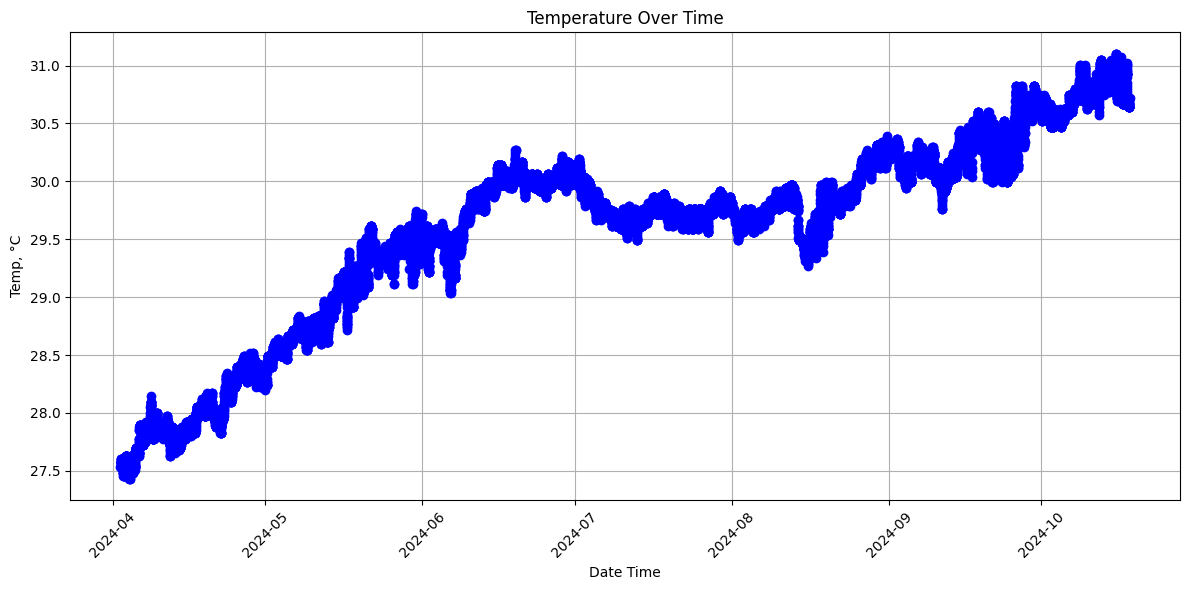

In [46]:
#%% Individual plots

# # Get the DataFrame
df = df_files['TCBKIT']['2404']['a']['DataFrame']

# # Convert the 'Date Time, GMT-04:00' column to datetime format
df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])


# # Plot the temperature over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date Time, GMT-04:00'], df['Temp, °C'], color='blue', marker='o', linestyle='-')
plt.title('Temperature Over Time')
plt.xlabel('Date Time')
plt.ylabel('Temp, °C')  # Modified label
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plotting Loop without displaying months:
If faster graph generation is desired, uncomment the cell below to generate the graphs for each site without displaying the months. This code is good for getting an idea of the shape for each file.

In [92]:
#%% Loop all plots without altering time to display as months -- Runs Faster

# # Loop through df_files and plot graphs for each DataFrame
# for site_code, site_data in df_files.items():
#     for file_number, file_data in site_data.items():
#         for file_identifier, file_info in file_data.items():
#             # Get the DataFrame
#             df = file_info['DataFrame']

#             # Convert the 'Date Time, GMT-04:00' column to datetime format
#             #df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])
            
#             # This was changed to deal with a error caused by modify a slice of a dataframe
#             # This iloc explicitly sets values in the dataframe 
#             df.loc[:, 'Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])

#             # Plot the temperature over time
#             plt.figure(figsize=(12, 6))
#             plt.plot(df.index, df['Temp, °C'], color='blue', marker='o', linestyle='-')
#             plt.title(f'Temperature Over Time - Site: {site_code}, File Number: {file_number}, Identifier: {file_identifier}')
#             plt.xlabel('Date Time')
#             plt.ylabel('Temp, °C')
#             plt.grid(True)
#             plt.xticks(rotation=45)
#             plt.tight_layout()
#             plt.show()

### Loop for plotting the sites:
This cell will generate graphs for the temperature change over the deployments for every site including months along the x axis.

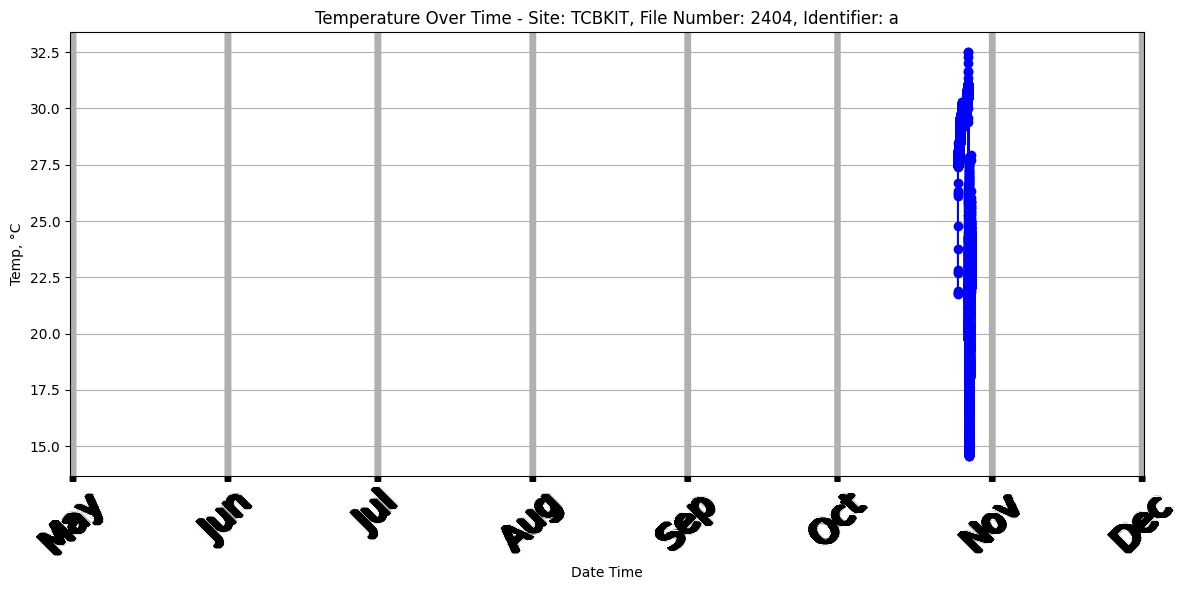

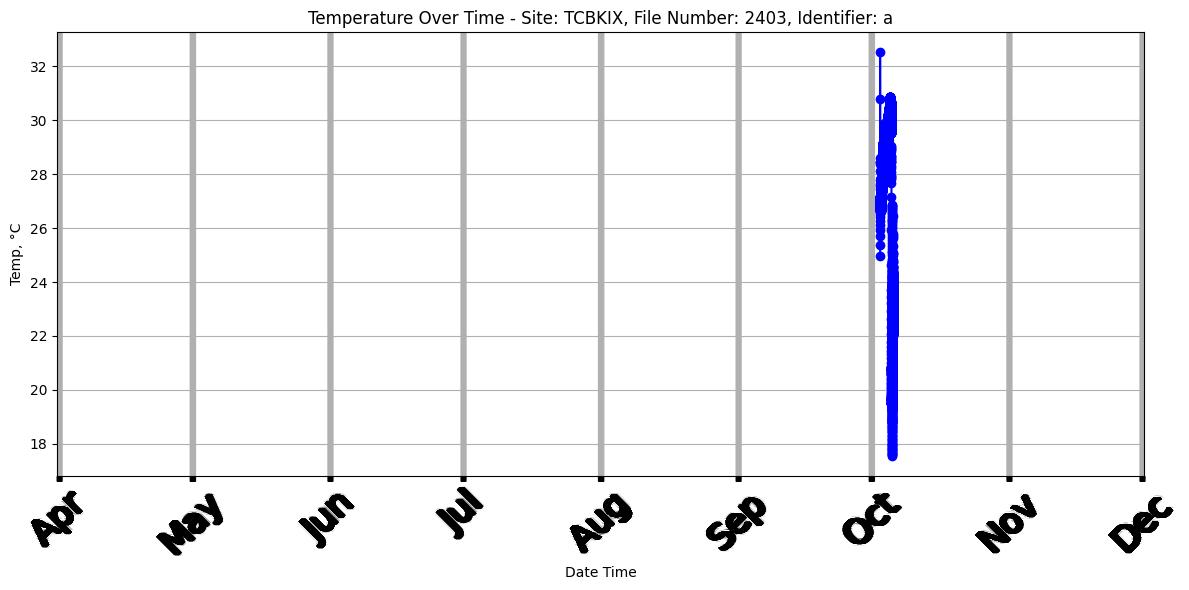

KeyboardInterrupt: 

In [ ]:
#%% Loop through df_files and plot graphs for each DataFrame where time is displayed as months

# Loop through df_files and plot graphs for each DataFrame
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame
            df = file_info['DataFrame']

            # Convert the 'Date Time, GMT-04:00' column to datetime format
            df.loc[:, 'Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])

            # Plot the temperature over time
            plt.figure(figsize=(12, 6))
            plt.plot(df['Date Time, GMT-04:00'], df['Temp, °C'], color='blue', marker='o', linestyle='-')
            plt.title(f'Temperature Over Time - Site: {site_code}, File Number: {file_number}, Identifier: {file_identifier}')
            plt.xlabel('Date Time')
            plt.ylabel('Temp, °C')
            plt.grid(True)
            
            # Set x-axis ticks to display month names at regular intervals
            #first_day_of_month_indices = df.index[df['Date Time, GMT-04:00'].dt.day == 1]
            #plt.xticks(first_day_of_month_indices, [dt.strftime('%b') for dt in df.loc[first_day_of_month_indices, 'Date Time, GMT-04:00']], rotation=45, fontdict={'family': 'sans-serif', 'size': 25, 'style': 'normal'})
            
            plt.tight_layout()
            plt.show()

### Individual start and end time checks:
This cell reports the start and end times from the dataframe and deployment metadata for a single file.

In [55]:
# %% Individual start time end time checks 
print("DataFrame Start Time:", df_files['TCBKIT']['2310']['a']['DataFrame']['Date Time, GMT-04:00'].iloc[0])
print("Deployment Data Start Time:", deployment_data_dict['BT_TCBKIT_2310_']['Date In Time In'])

# Print end time
print("DataFrame End Time:", df_files['TCBKIT']['2310']['a']['DataFrame']['Date Time, GMT-04:00'].iloc[-1])
print("Deployment Data End Time:", deployment_data_dict['BT_TCBKIT_2310_']['Date Out Time Out'])

# Then, check if the extracted timestamps match the expected start and end times.

KeyError: '2310'

### Start end time check loop:
To see every start and end time from the dataframe and deployment metadata, run this cell. This allows you to see the listed start and end times as displaced in the deployment log vs the now editied start and edn times in the file.

In [56]:
# %% Loop for start time end time checks
# List to store the names of empty DataFrames
empty_dataframes = []

# Loop through each site code, file number, and file identifier in df_files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame for the current file
            df = file_info['DataFrame']
            
            if not df.empty:  # Check if the DataFrame is not empty
                # Print the start and end times for the current DataFrame
                print(f"DataFrame Start Time ({site_code}_{file_number}_{file_identifier}):", df['Date Time, GMT-04:00'].iloc[0])
                print(f"DataFrame End Time ({site_code}_{file_number}_{file_identifier}):", df['Date Time, GMT-04:00'].iloc[-1])

                # Get the corresponding offloaded file name
                offloaded_file_name = file_info['File Name']
                
                # Retrieve deployment data using the offloaded file name
                deployment_data = deployment_data_dict.get(offloaded_file_name)
                
                if deployment_data:
                    # Print the start and end times from deployment data
                    print(f"Deployment Data Start Time ({offloaded_file_name}):", deployment_data['Date In Time In'])
                    print(f"Deployment Data End Time ({offloaded_file_name}):", deployment_data['Date Out Time Out'])
                else:
                    print(f"No deployment data found for {offloaded_file_name}")

                print()  # Add an empty line for better readability
            else:
                # If DataFrame is empty, append its name to the list
                empty_dataframes.append(f"{site_code}_{file_number}_{file_identifier}")

# Print names of empty DataFrames
if empty_dataframes:
    print("Names of empty DataFrames:")
    for name in empty_dataframes:
        print(name)
else:
    print("No empty DataFrames found.")

DataFrame Start Time (TCBKIT_2404_a): 2024-04-02 12:45:00
DataFrame End Time (TCBKIT_2404_a): 2024-10-18 08:45:00
Deployment Data Start Time (BT_TCBKIT_2404_): 2024-04-02 11:38:00
Deployment Data End Time (BT_TCBKIT_2404_): 2024-10-18 10:08:00

DataFrame Start Time (TCBKIX_2403_a): 2024-03-11 14:30:00
DataFrame End Time (TCBKIX_2403_a): 2024-11-11 09:30:00
Deployment Data Start Time (BT_TCBKIX_2403_a): 2024-03-11 13:25:00
Deployment Data End Time (BT_TCBKIX_2403_a): 2024-11-11 10:59:00

DataFrame Start Time (TCBKIX_2403_b): 2024-03-11 14:30:00
DataFrame End Time (TCBKIX_2403_b): 2024-11-11 09:30:00
Deployment Data Start Time (BT_TCBKIX_2403_b): 2024-03-11 13:25:00
Deployment Data End Time (BT_TCBKIX_2403_b): 2024-11-11 10:59:00

DataFrame Start Time (TCBKPT_2402_a): 2024-02-15 15:00:00
DataFrame End Time (TCBKPT_2402_a): 2024-10-11 08:15:00
Deployment Data Start Time (BT_TCBKPT_2402_a): 2024-02-15 13:46:00
Deployment Data End Time (BT_TCBKPT_2402_a): 2024-10-11 09:36:00

DataFrame Star

## <u>Trimmed file dates </u>
This loop iterates through the .csv files for each site and reports the first and last sample dates. This will make it easier to report the trimmed file dates in the metadata and deployment log as the code names for the files are based on their trimmed dates, making the metadata inconsistent for several files. The days are also included as the day is needed for the DATASET files for the metadata part of the SOP.

In [57]:
# Iterate through df_files to extract and save the "a" version of the files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        if 'a' in file_data:  # Check if "a" version exists for the file
            # Extract the DataFrame for the "a" version
            df_a = file_data['a']['DataFrame']
            
            # Get the year and month of the first and last data points
            first_data_point = df_a['Date Time, GMT-04:00'].iloc[0]
            last_data_point = df_a['Date Time, GMT-04:00'].iloc[-1]
            year_month_first = first_data_point.strftime("%y %m %d")  # Using last two digits of the year
            year_month_last = last_data_point.strftime("%y %m %d")    # Using last two digits of the year
            
            # Construct the base file name
            base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
            
            # Check if the file is identified as a calculation file
            if (site_code, file_number) in calculations:
                output_file_name = f"{base_file_name}_calculations.csv"
            else:
                output_file_name = f"{base_file_name}.csv"
            
            print(f"{output_file_name}")
        else:
            print(f"No 'a' version found for Site: {site_code}, File Number: {file_number}")

BT_TCBKIT_24 04 02_24 10 18.csv
BT_TCBKIX_24 03 11_24 11 11.csv
BT_TCBKPT_24 02 15_24 10 11_calculations.csv
BT_TCBOTB_24 04 17_24 10 17.csv
BT_TCBRWB_24 04 11_24 10 11.csv
BT_TCCB08_24 03 13_24 11 12_calculations.csv
BT_TCCB40_24 03 13_24 11 12_calculations.csv
BT_TCCLGE_24 05 14_24 11 21.csv
BT_TCCORB_24 02 16_24 10 24.csv
BT_TCCORK_24 04 02_24 10 18.csv
BT_TCCSTL_24 03 11_24 11 12.csv
BT_TCEAGR_24 03 13_24 11 14.csv
BT_TCFLTC_24 02 15_24 10 22_calculations.csv
BT_TCFSHB_24 02 16_24 10 24.csv
BT_TCGMKT_24 04 08_24 11 22.csv
BT_TCGRPD_24 03 12_24 11 13.csv
BT_TCHB40_24 05 14_24 11 21_calculations.csv
BT_TCJCKB_24 03 14_24 11 13.csv
BT_TCKNGC_24 03 15_24 11 15.csv
BT_TCLBEM_24 03 16_24 11 13.csv
BT_TCLBRH_24 03 12_24 11 16.csv
BT_TCLSTJ_24 04 26_24 10 29.csv
BT_TCMAGB_24 04 17_24 10 22.csv
BT_TCMERI_24 04 22_24 11 22.csv
BT_TCMT24_24 03 15_24 11 15.csv
BT_TCMT40_24 03 15_24 11 15_calculations.csv
BT_TCSAVA_24 04 17_24 10 17.csv
BT_TCSC35_23 10 23_24 10 25.csv
BT_TCSCAP_24 04 22_24 10 2

## <b>Step 2 and 3. Offload data and file naming conventions

### Setting output folder and exporting the .csv files:
This cell defines the output folder, creating the folder if not existing previously, then runs a loop, first checking for the a version of the file and then extracting that data frame to export the .csv files by the naming convention set in the SOP as BT_site_code_year_month_first_year_month_last. Inside the loop also checks if the file was identified as "calculations", if so then adds "_calculations.csv" as is the naming convention set for them in the SOP. Internal calculations offloads the files that have the temperature columns averaged and empty cells to show the number of instances where there was a difference >0.2 and will not be uploaded to the drive.
<li><u>Make sure to update the folder path in the cell!</u>

In [58]:
# Define the output folder where you want to save the extracted files
output_folder = r"C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output"

# Define the internal calculations folder within the output folder
internal_calculations_folder = os.path.join(output_folder, "internal_calculations")

# Create the calculations folder if it doesn't exist
if not os.path.exists(internal_calculations_folder):
    os.makedirs(internal_calculations_folder)

# Iterate through df_files to extract and save the "a" version of the files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        if 'a' in file_data:  # Check if "a" version exists for the file
            # Extract the DataFrame for the "a" version
            df_a = file_data['a']['DataFrame']
            
            # Get the year and month of the first and last data points
            first_data_point = df_a['Date Time, GMT-04:00'].iloc[0]
            last_data_point = df_a['Date Time, GMT-04:00'].iloc[-1]
            year_month_first = first_data_point.strftime("%y%m")  # Using last two digits of the year
            year_month_last = last_data_point.strftime("%y%m")    # Using last two digits of the year
            
            # Construct the base file name
            base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
            
            # Check if the file is identified as a calculation file
            if (site_code, file_number) in calculations:
                output_file_name = f"{base_file_name}_internal_calculations.csv"
                output_file_path = os.path.join(internal_calculations_folder, output_file_name)
            else:
                output_file_name = f"{base_file_name}.csv"
                output_file_path = os.path.join(output_folder, output_file_name)
            
            # Save the DataFrame to CSV
            df_a.to_csv(output_file_path, index=False)
            
            print(f"File saved: {output_file_path}")
        else:
            print(f"No 'a' version found for Site: {site_code}, File Number: {file_number}")

File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCBKIT_2404_2410.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCBKIX_2403_2411.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\internal_calculations\BT_TCBKPT_2402_2410_internal_calculations.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCBOTB_2404_2410.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCBRWB_2404_2410.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\internal_calculations\BT_TCCB08_2403_2411_internal_calculations.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\internal_calculations\BT_TCCB40_2403_2411_internal_calculations.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCCLGE_2405_2411.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCCORB_2402_2410.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCCORK_2404_2410.csv
File saved: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\BT_TCCSTL_2403_2411.csv
File saved: C:\UVI\QA

### Offload loop: a and merged data
The code below is to test for files that were named using 'a' or 'merged' identifiers. It will loop through the .csv files and export them if they match those identifiers.

In [ ]:
# %% exporting both the "a" and "merged" identifiers
# # Iterate through df_files to extract and save the "a" and "merged" versions of the files
# for site_code, site_data in df_files.items():
#     for file_number, file_data in site_data.items():
#         for identifier, data_info in file_data.items():
#             if identifier in ['a', 'merged']:  # Check if the identifier is either 'a' or 'merged'
#                 # Extract the DataFrame for the current identifier
#                 df = data_info['DataFrame']
                
#                 # Get the year and month of the first and last data points
#                 first_data_point = df['Date Time, GMT-04:00'].iloc[0]
#                 last_data_point = df['Date Time, GMT-04:00'].iloc[-1]
#                 year_month_first = first_data_point.strftime("%y%m")  # Using last two digits of the year
#                 year_month_last = last_data_point.strftime("%y%m")    # Using last two digits of the year
                
#                 # Construct the base file name
#                 base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
                
#                 # Check if the file is identified as a calculation file
#                 if (site_code, file_number) in calculations:
#                     output_file_name = f"{base_file_name}_calculations.csv"
#                 else:
#                     output_file_name = f"{base_file_name}.csv"
                
#                 output_file_path = os.path.join(output_folder, output_file_name)
                
#                 # Save the DataFrame to CSV
#                 df.to_csv(output_file_path, index=False)
                
#                 print(f"File saved: {output_file_path}")
#             else:
#                 print(f"No 'a' or 'merged' version found for Site: {site_code}, File Number: {file_number}")

### Offloading plots: only a files
Code below reads in the newly offloaded csv files, converts the date time, and plots the temperature over time for each .csv file then exports them to a folder.
<li><u>To save the plots, you will need to create a directory (a folder). Make sure to update that folder path in the save_dir = part of the cell!</u>

C:\Users\magic\AppData\Local\Temp\ipykernel_24128\3625723777.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 6))


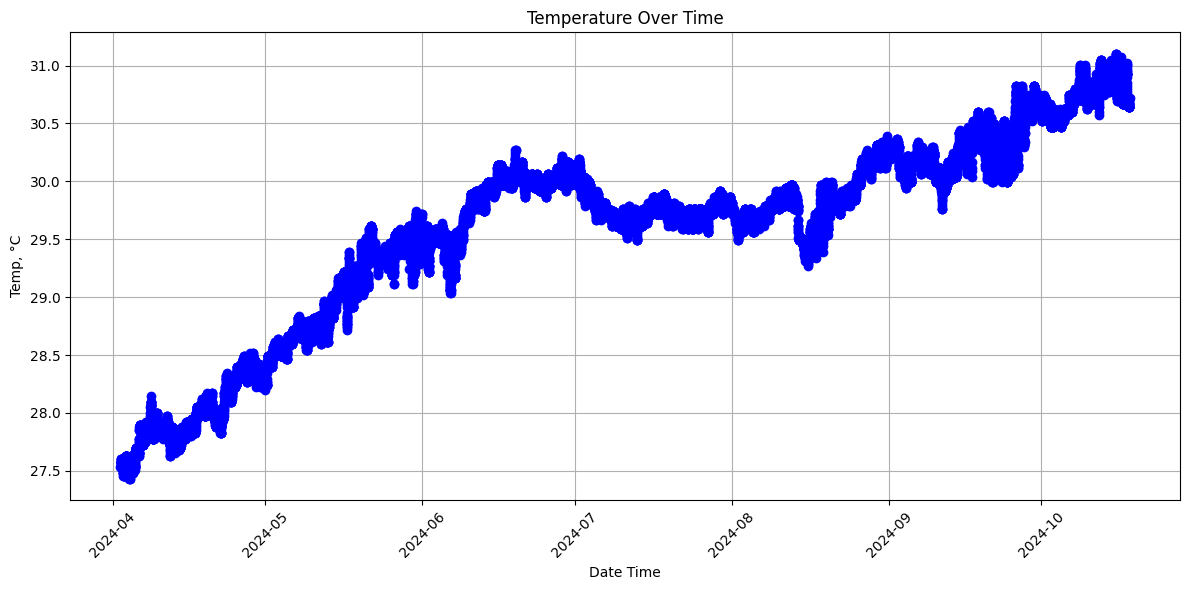

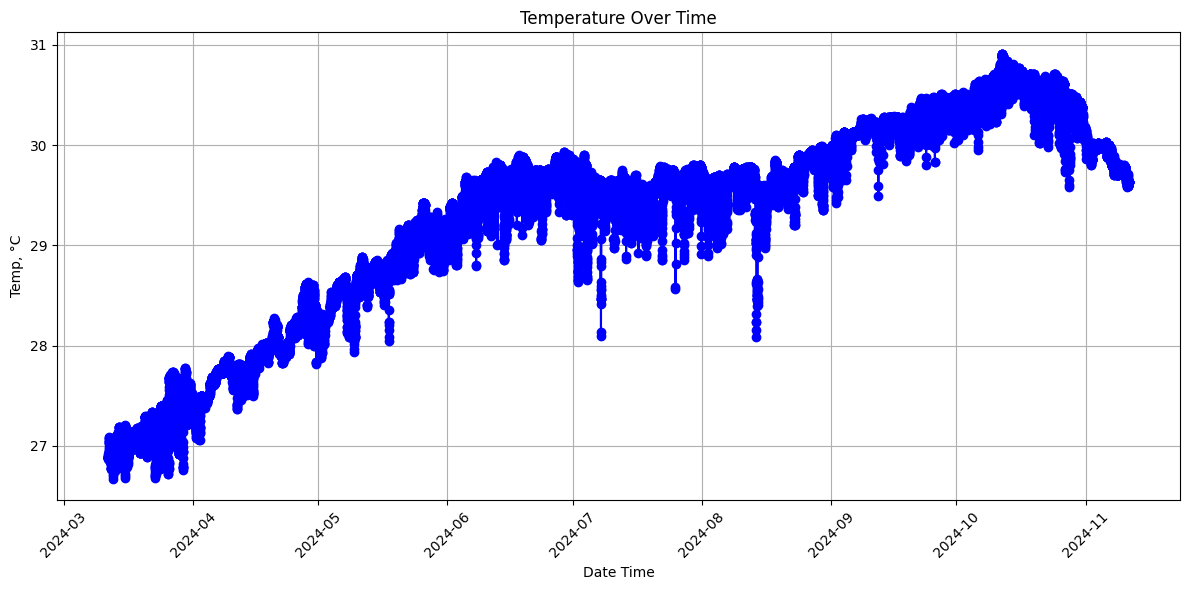

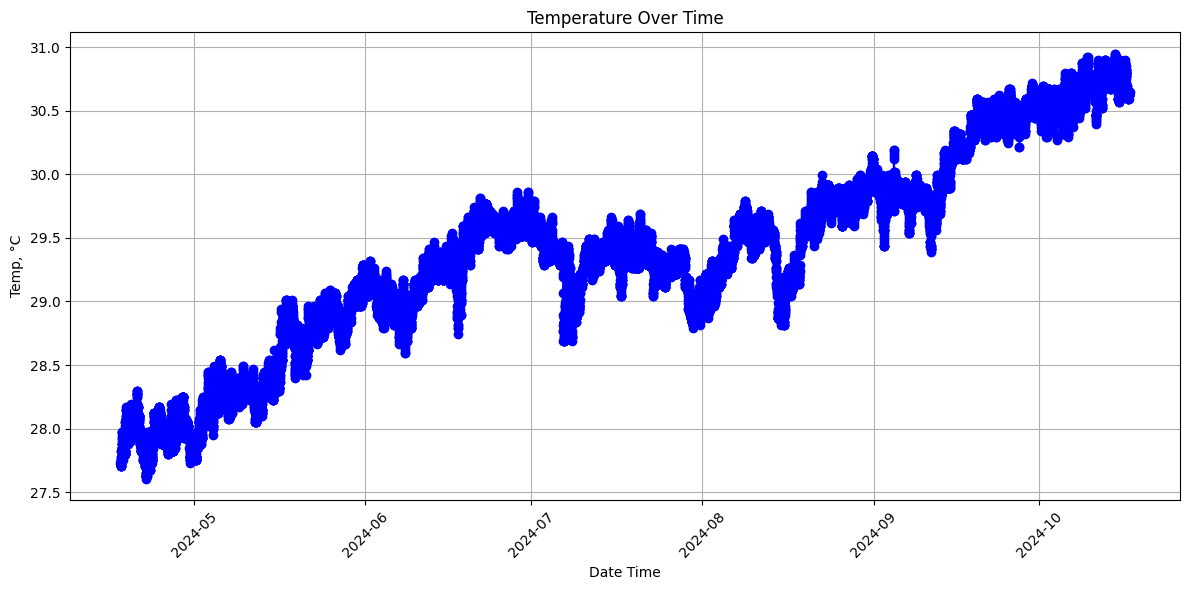

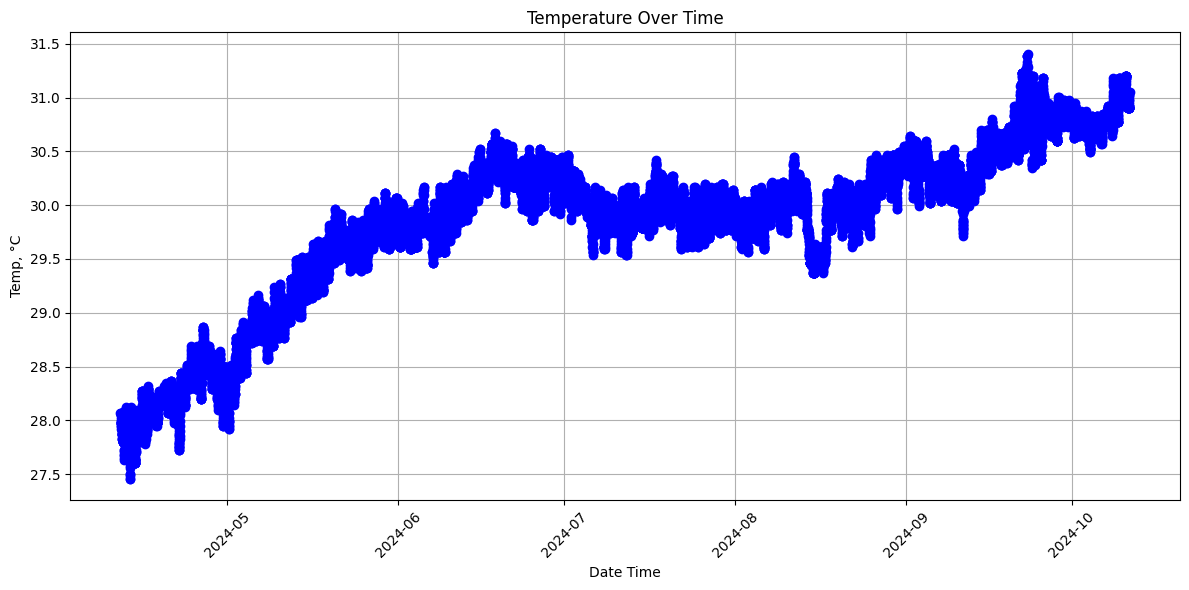

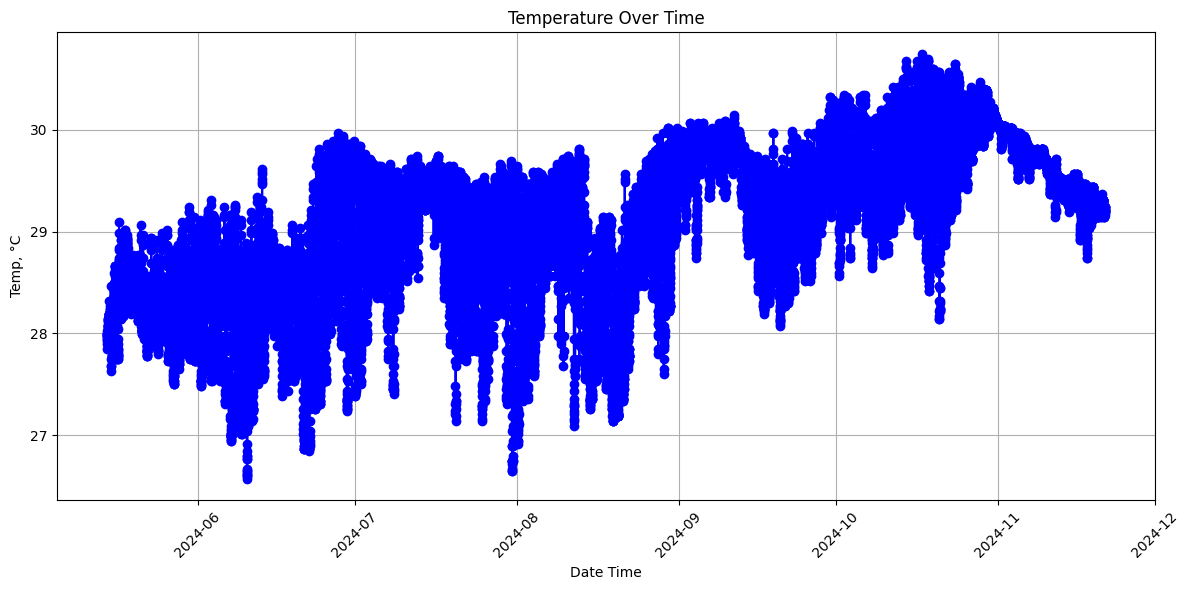

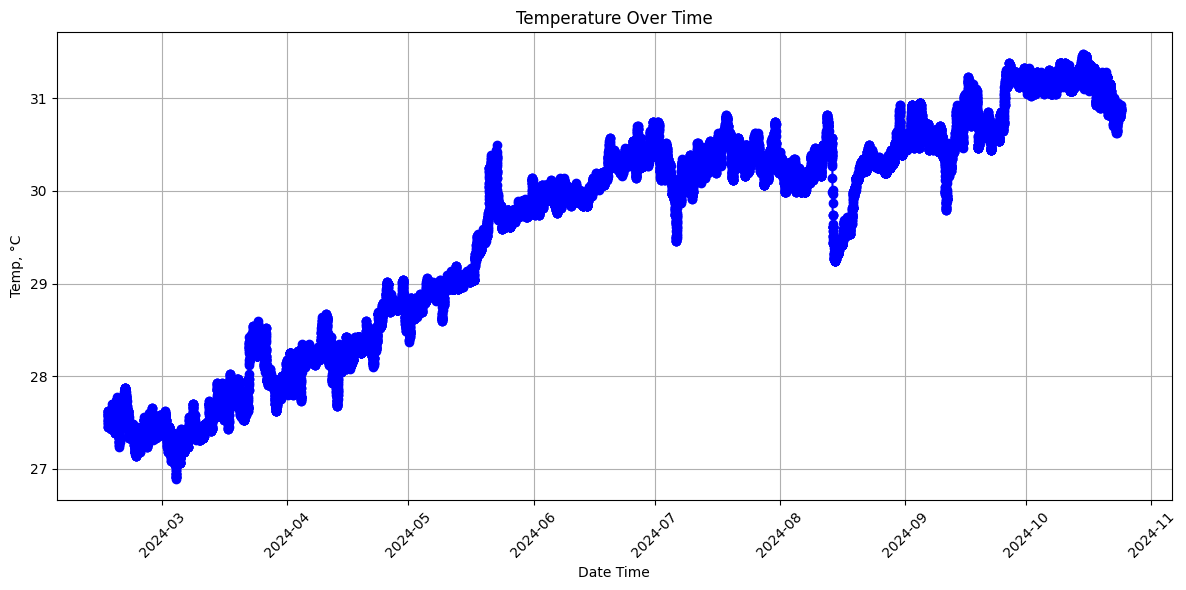

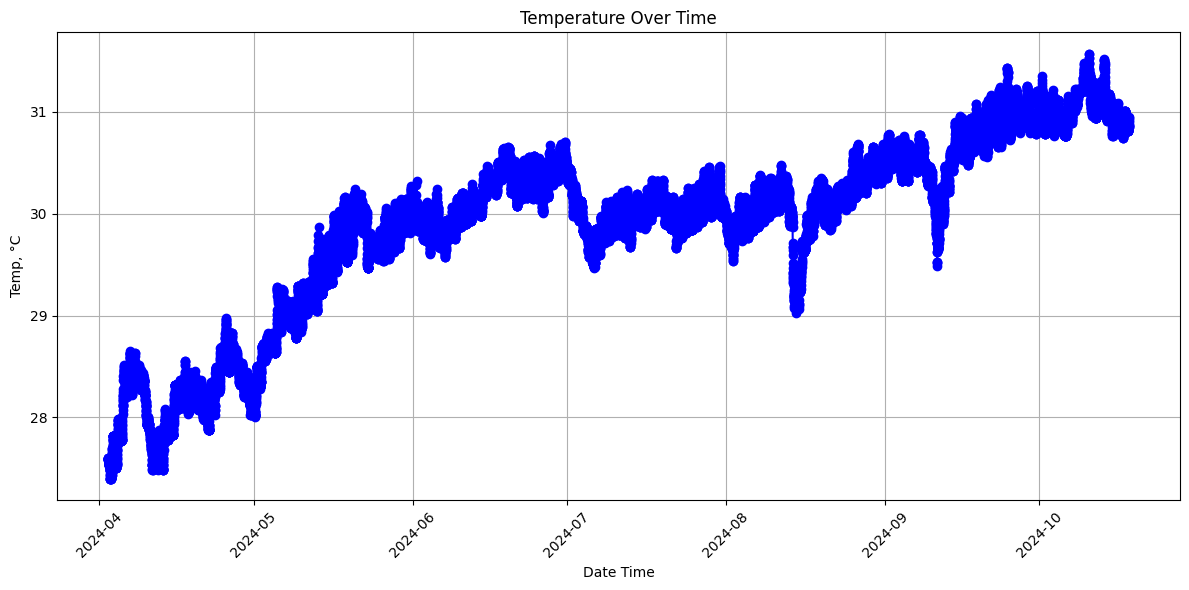

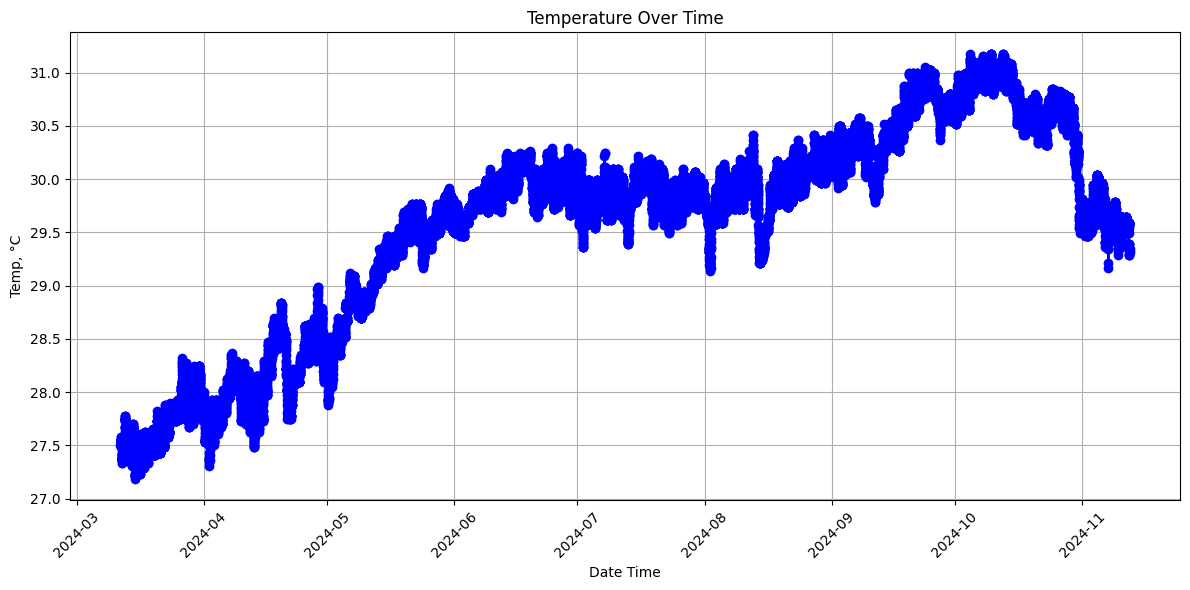

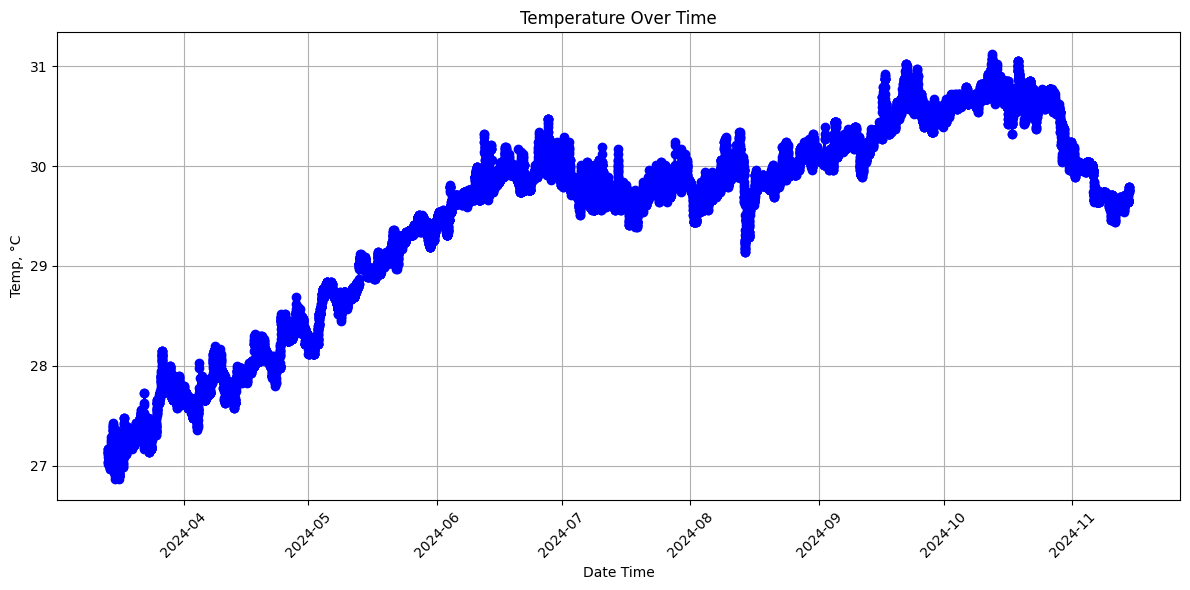

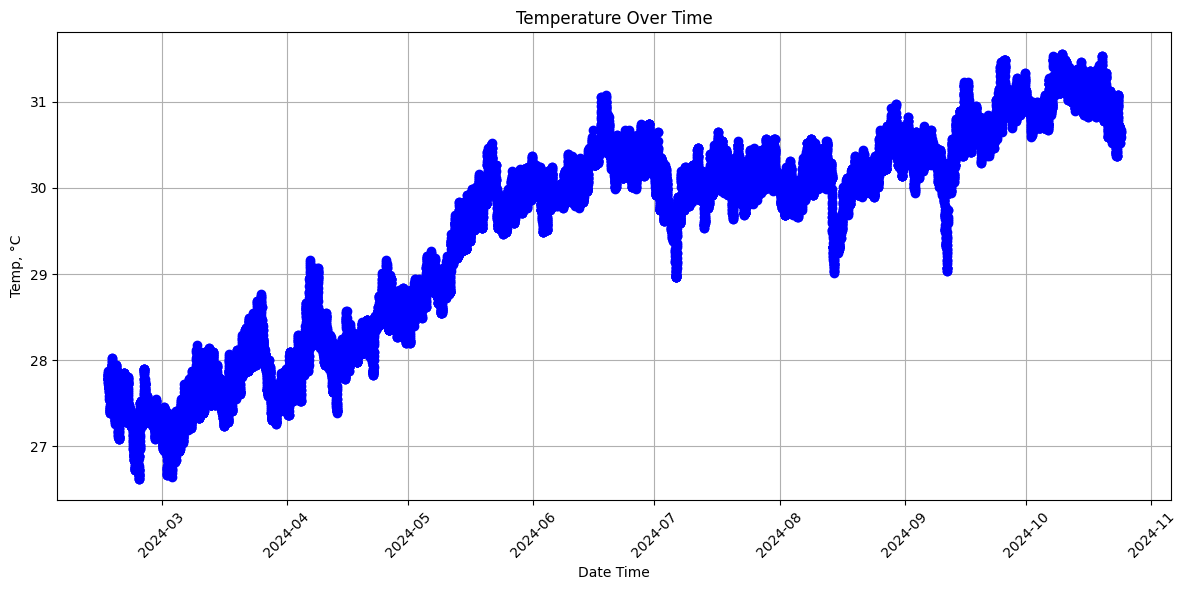

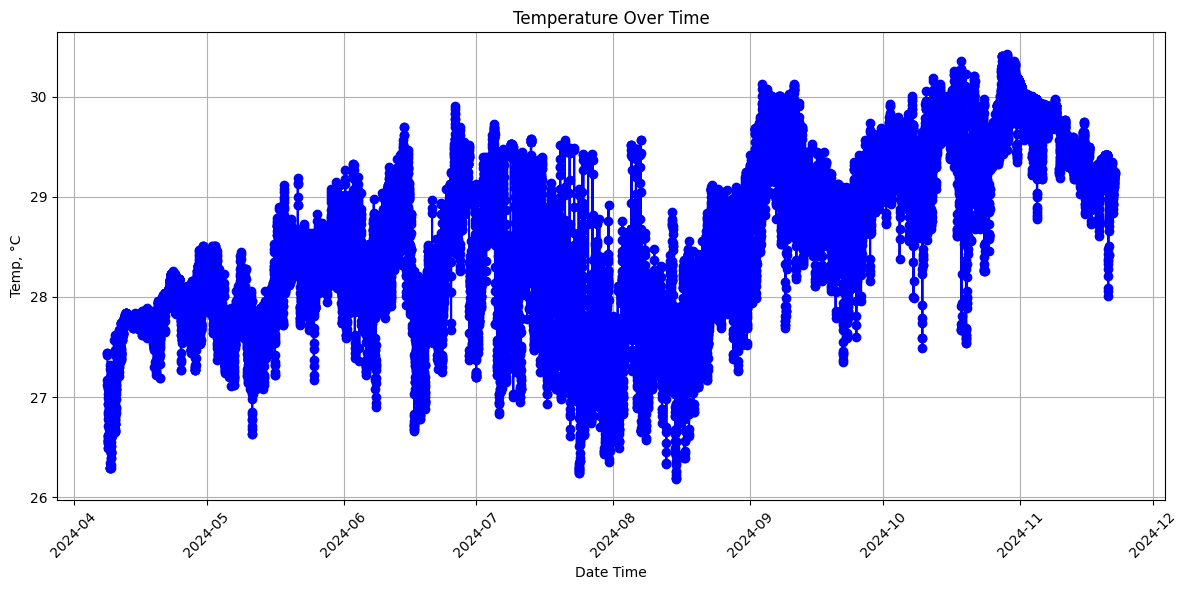

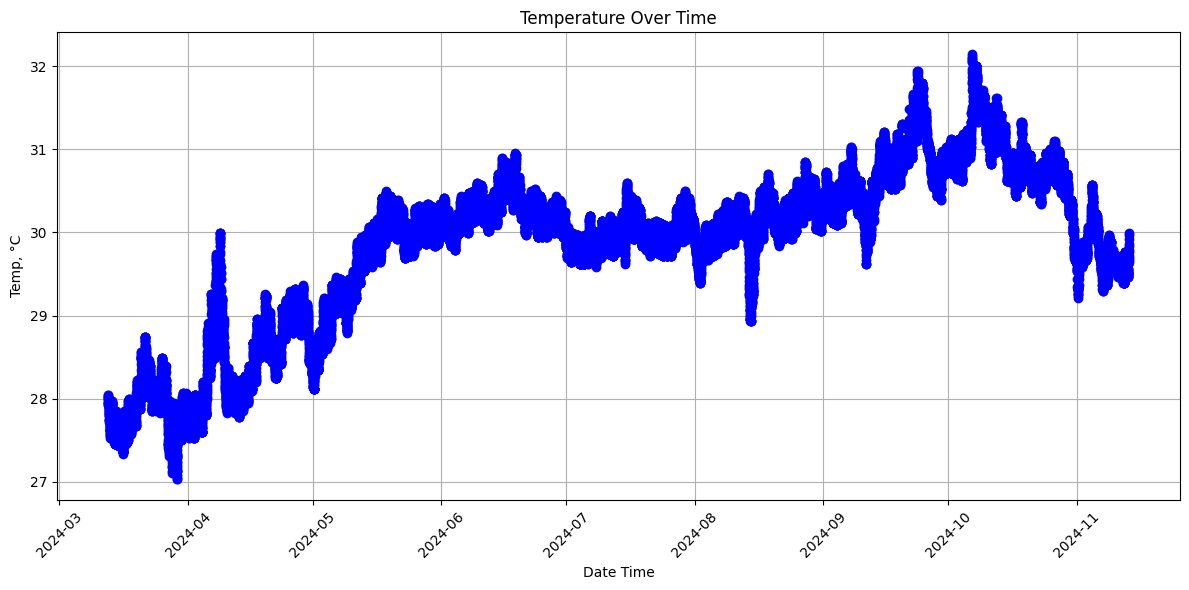

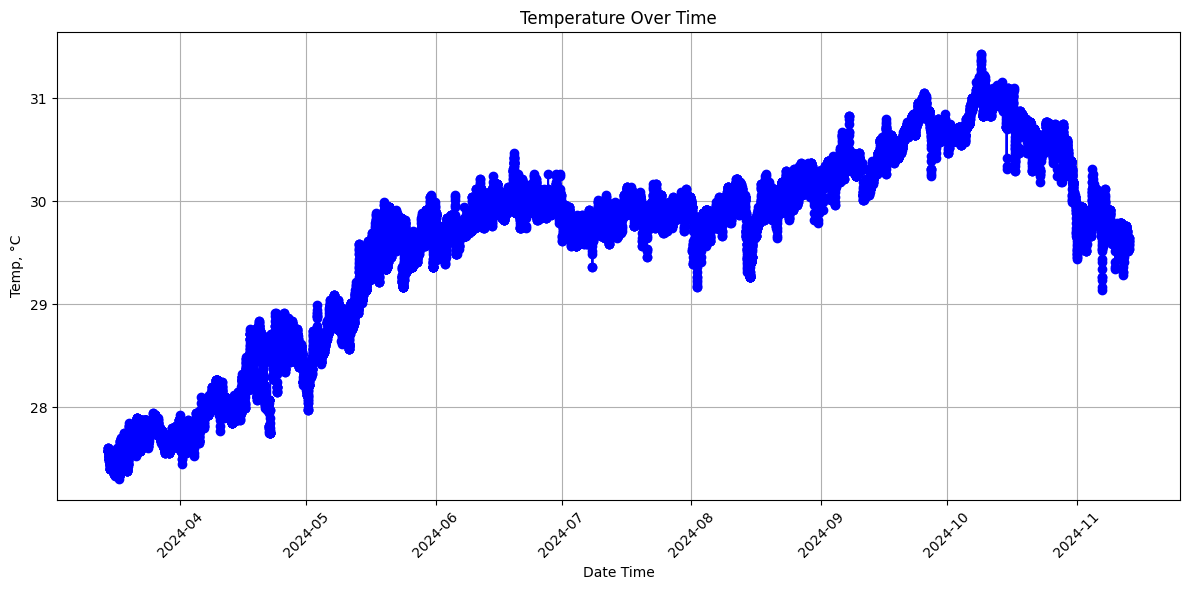

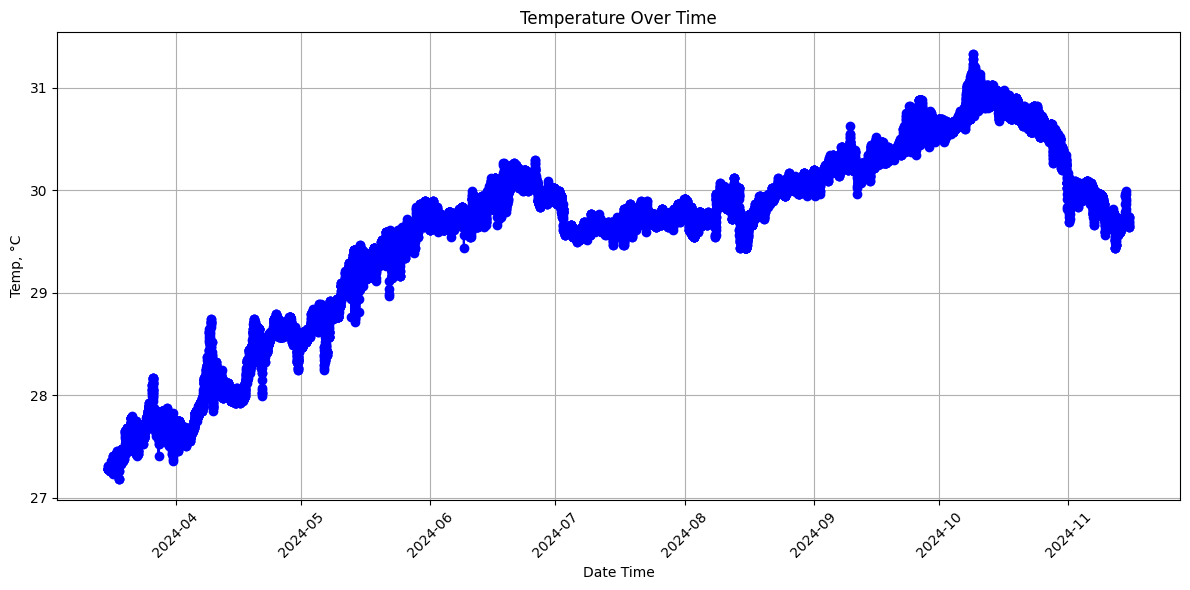

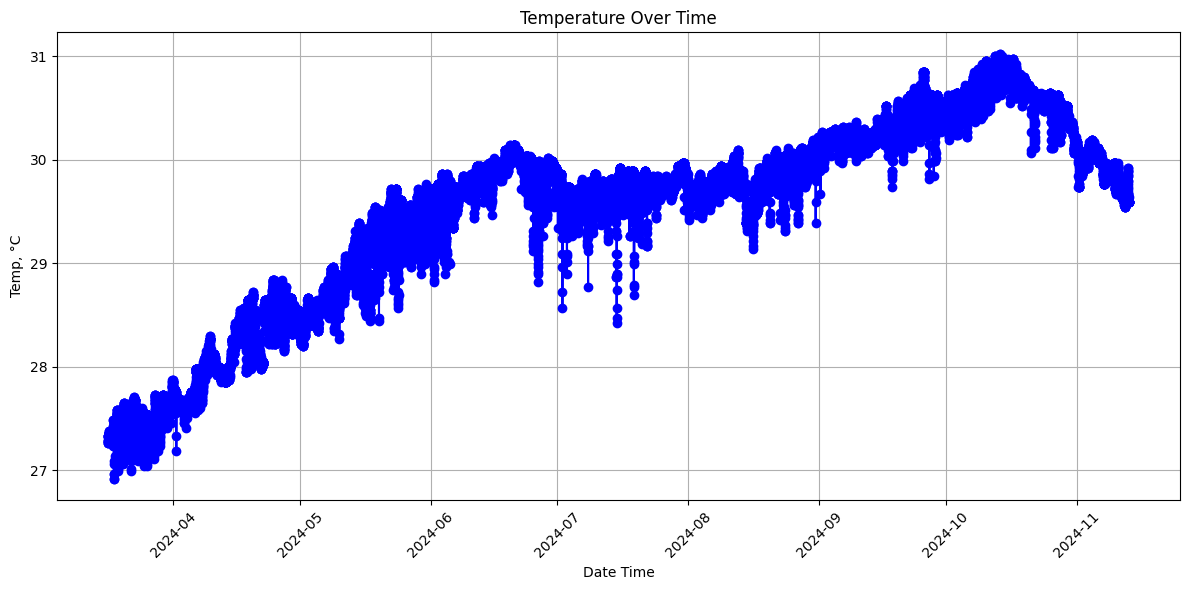

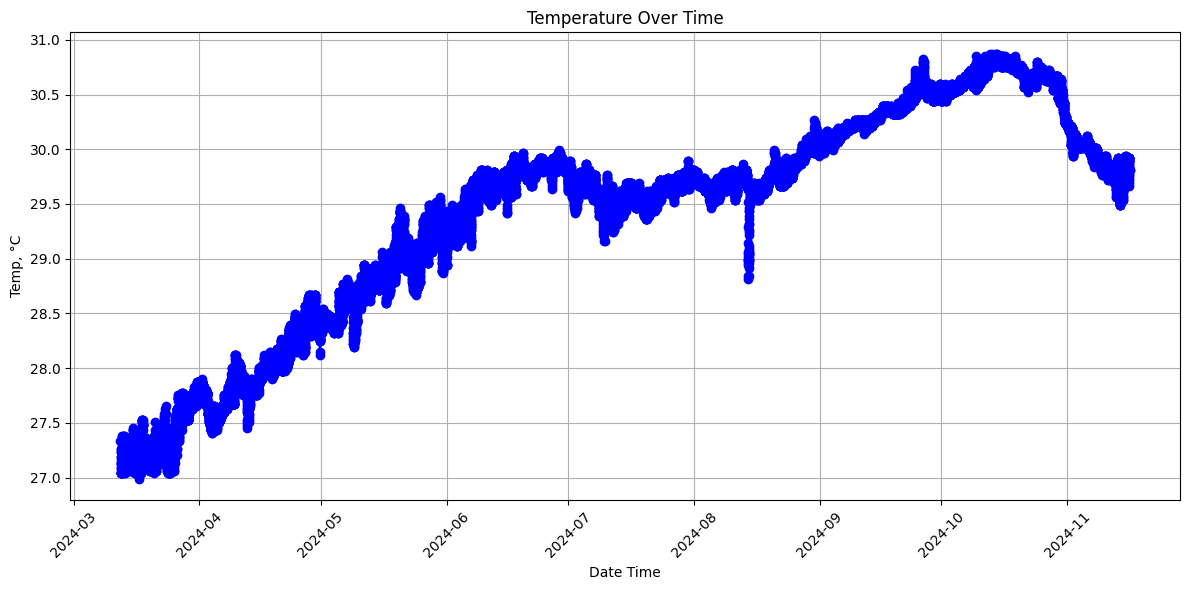

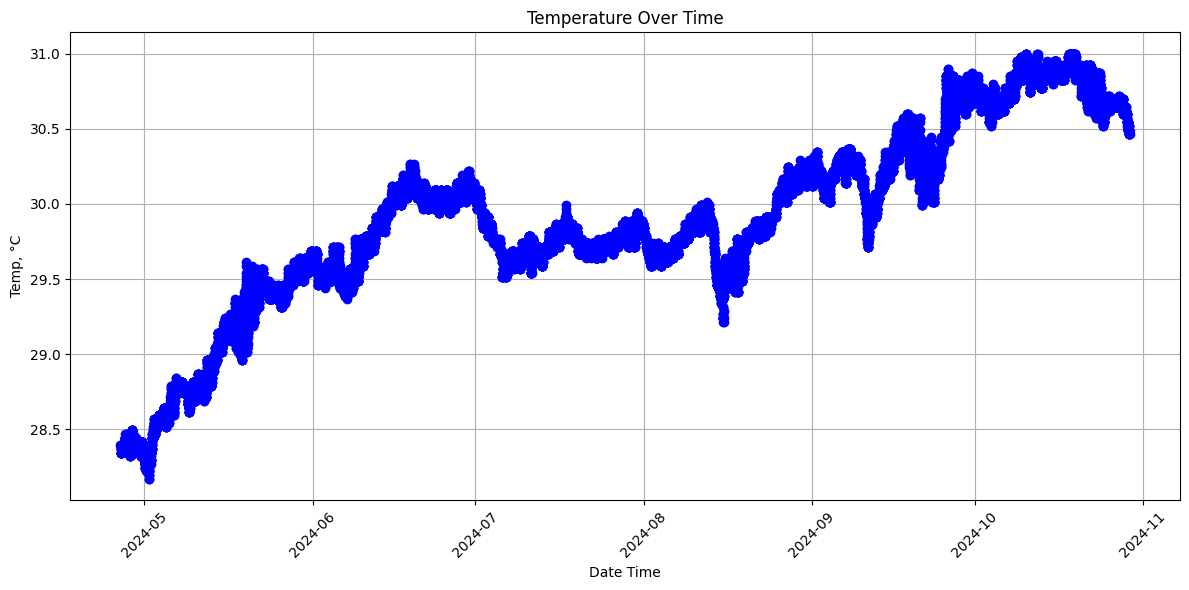

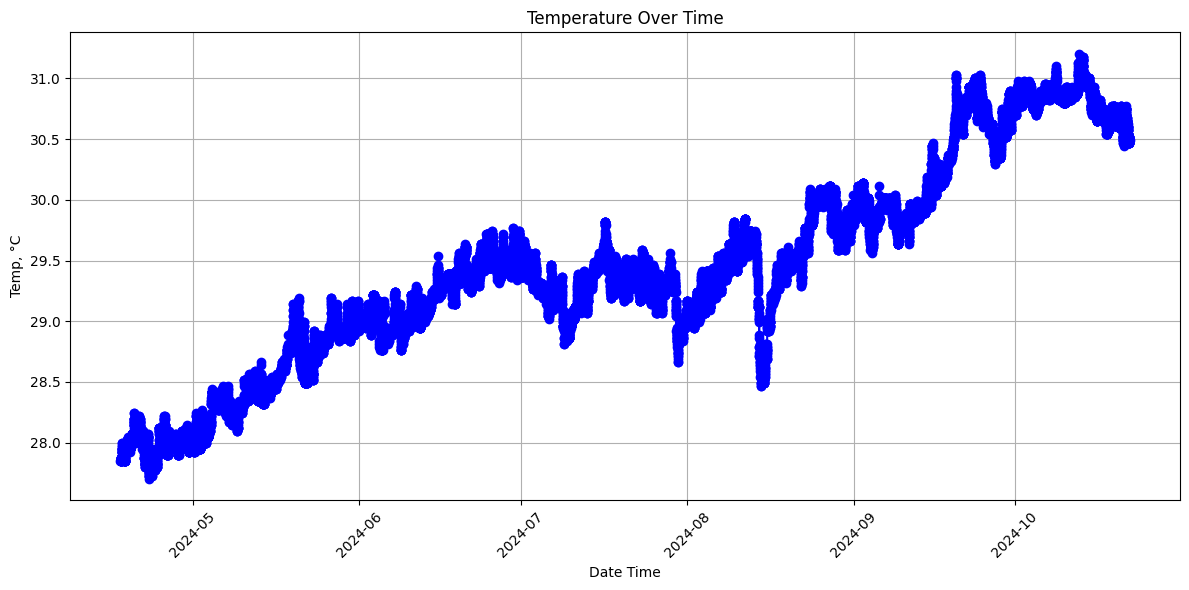

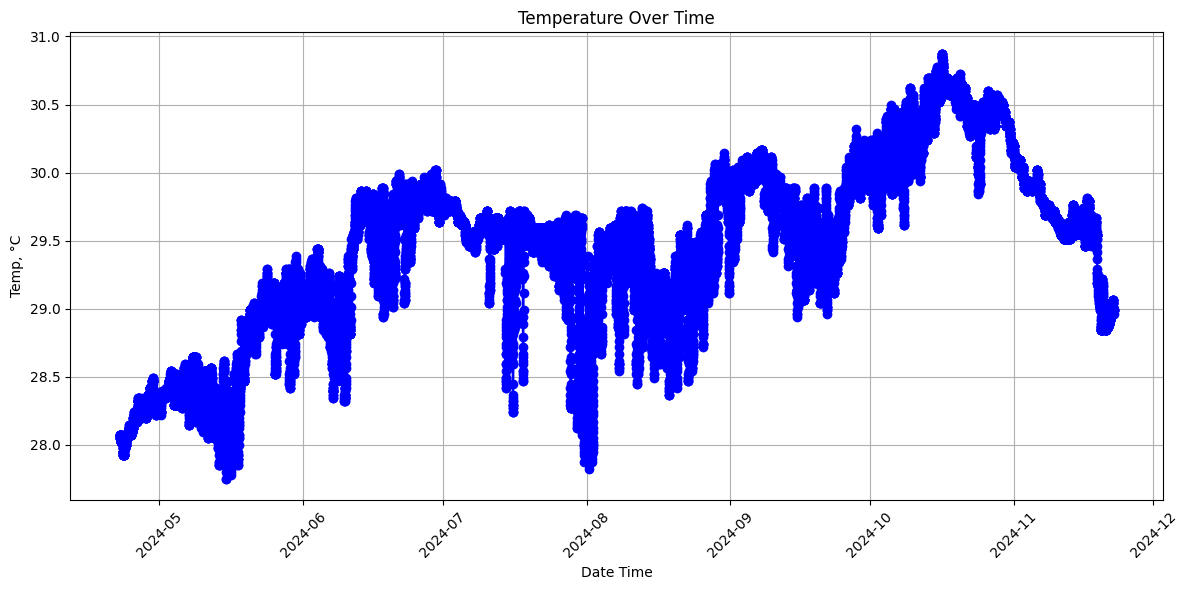

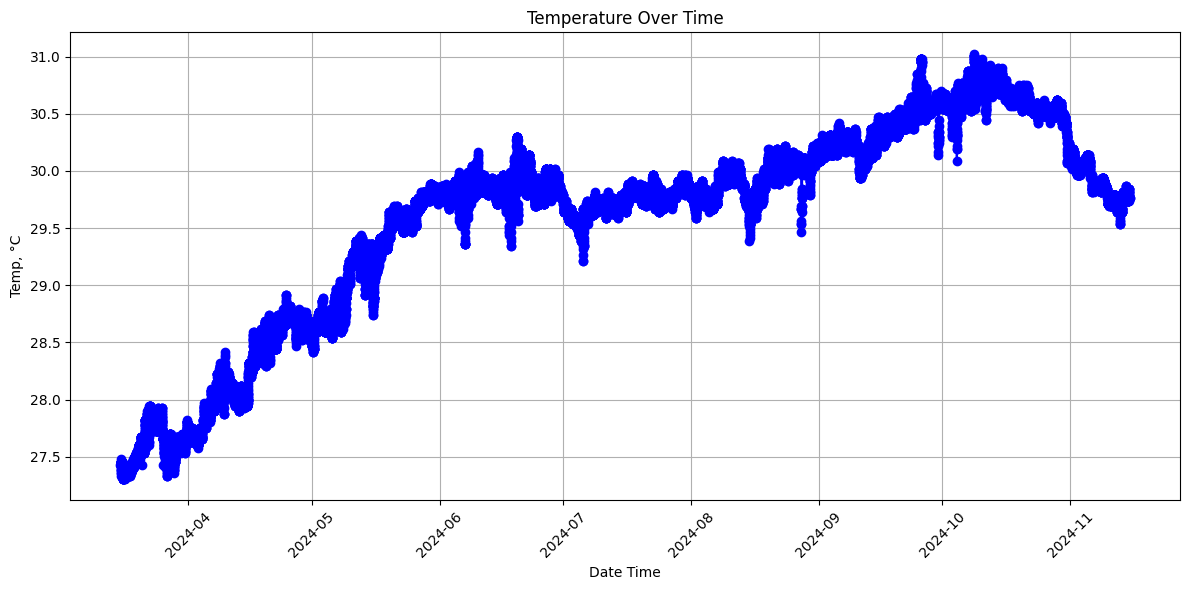

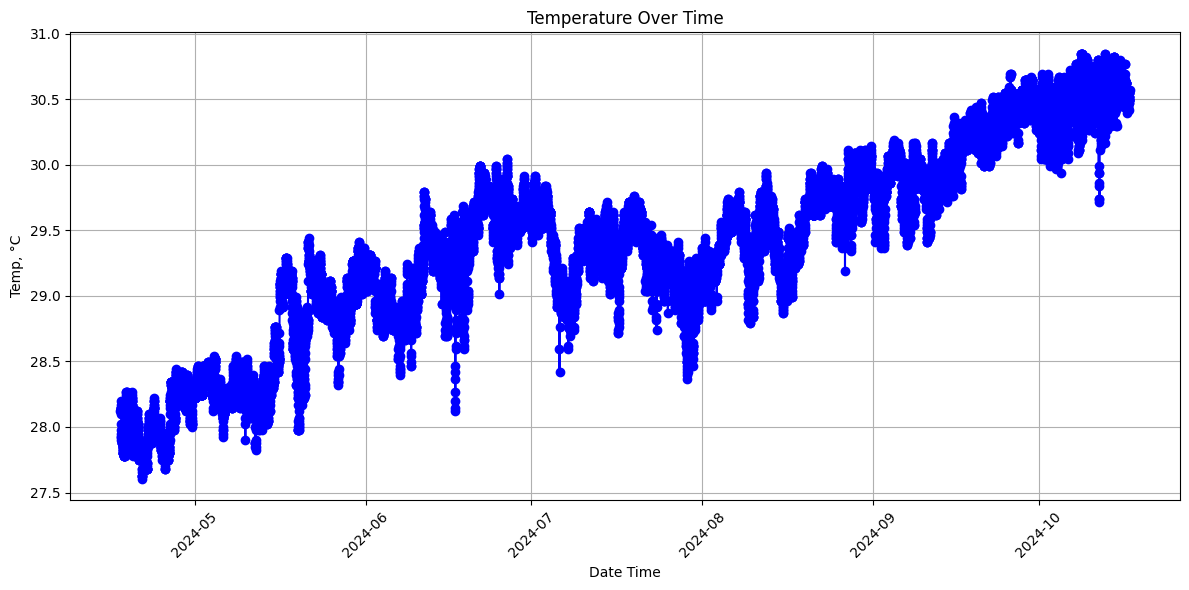

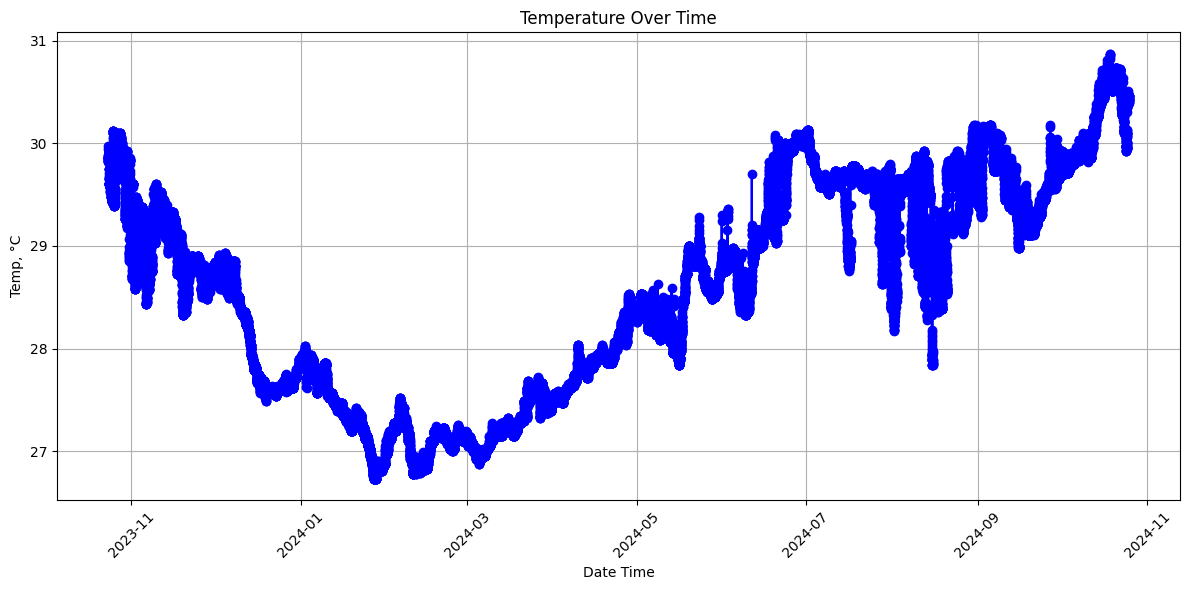

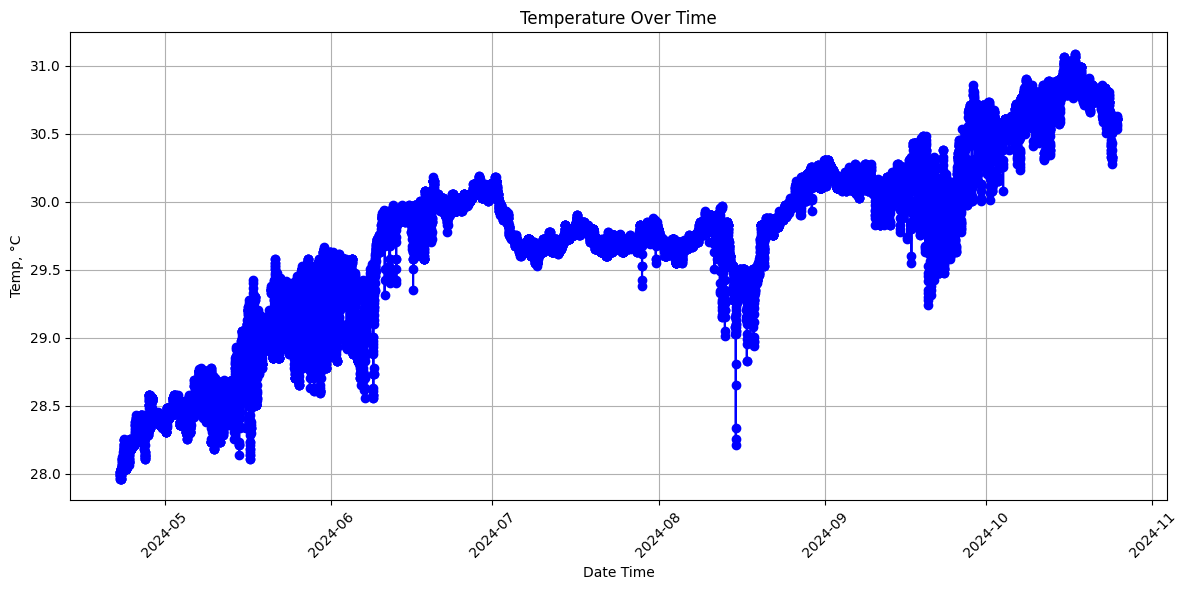

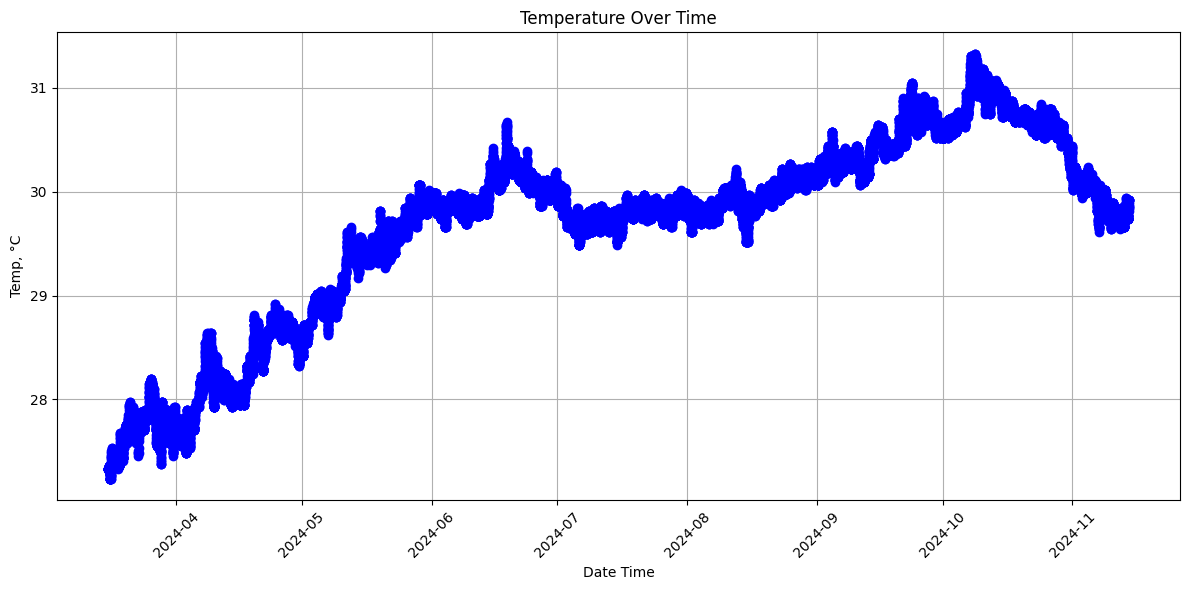

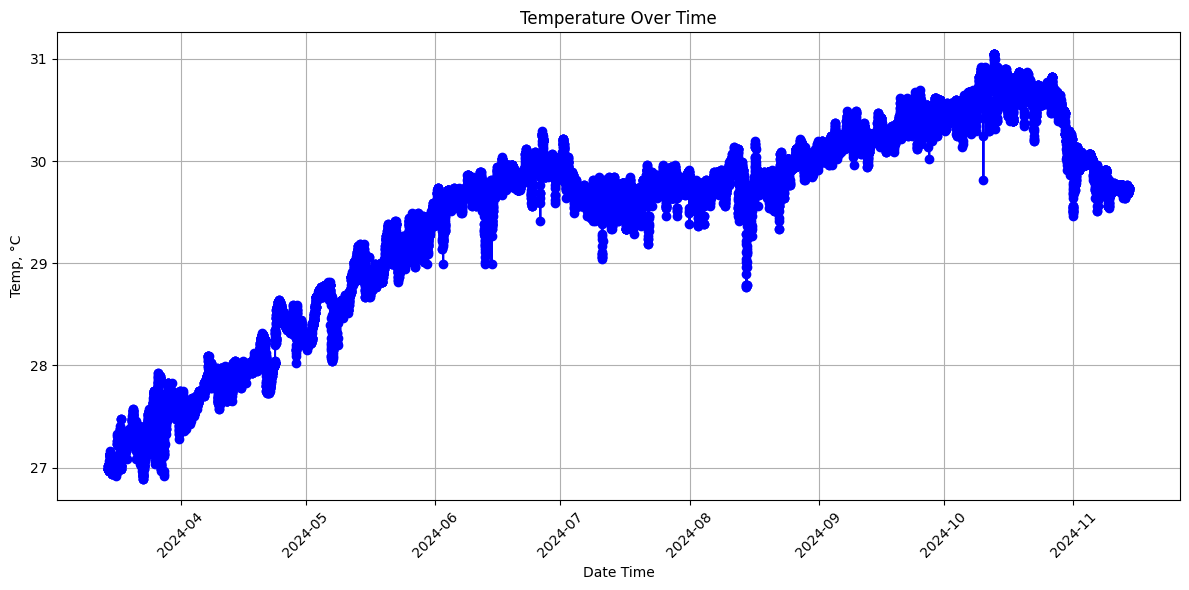

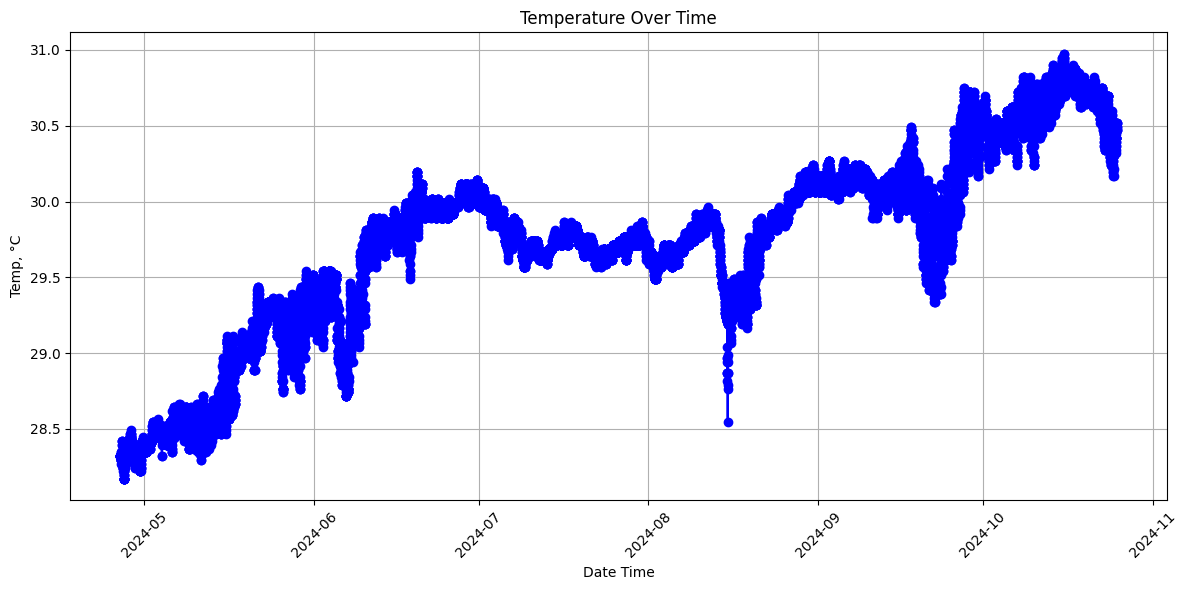

In [60]:
#%% Using new offloaded files create plots and save plots to a folder
 
exported_folder_path = r'C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output'

# Define pattern to match CSV files
file_pattern = '*.csv'

# Use glob to get a list of file paths matching the pattern set in file_pattern
exported_csv_files = glob.glob(exported_folder_path + '/' + file_pattern)

# Loop through each CSV file
for csv_file in exported_csv_files:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file)
    
    df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'], format='%Y-%m-%d %H:%M:%S')

    # Convert the 'Date Time, GMT-04:00' column to datetime format
    #df.loc[:, 'Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])
    df['Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])
    # Plot the data
    plt.figure(figsize=(12, 6))
    plt.plot(df['Date Time, GMT-04:00'], df['Temp, °C'], color='blue', marker='o', linestyle='-')
    plt.title('Temperature Over Time')
    plt.xlabel('Date Time')
    plt.ylabel('Temp, °C')
    plt.grid(True)
    
    # Set x-axis ticks to display month names at regular intervals
    # first_day_of_month_indices = df.index[df['Date Time, GMT-04:00'].dt.day == 1]
    # plt.xticks(first_day_of_month_indices, [dt.strftime('%b') for dt in df.loc[first_day_of_month_indices, 'Date Time, GMT-04:00']], rotation=45, fontdict={'family': 'sans-serif', 'size': 25, 'style': 'normal'})
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Extract file name from the file path
    file_name = os.path.basename(csv_file)
    
    # Define the file name for the plot
    plot_file_name = os.path.splitext(file_name)[0] + '_plot.png'
    
    save_dir = r"C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\graphs"
    # Save the plot
    plt.savefig(os.path.join(save_dir, plot_file_name))
    
    # Show the plot (optional)
    # plt.show()

### Offload loop: a and merged plots
This loops through the .csv files and generates plots for 'a' or 'merged' identified files and generates then exports the plots.

In [ ]:
#%%
# # Loop through df_files and plot graphs for each DataFrame where time is displayed as year and month
# for site_code, site_data in df_files.items():
#     for file_number, file_data in site_data.items():
#         for file_identifier, file_info in file_data.items():
#             # Check if the file_identifier starts with 'a' or is 'merged'
#             if file_identifier.startswith('a') or file_identifier == 'merged':
#                 # Get the DataFrame
#                 df = file_info['DataFrame']

#                 # Convert the 'Date Time, GMT-04:00' column to datetime format
#                 df.loc[:, 'Date Time, GMT-04:00'] = pd.to_datetime(df['Date Time, GMT-04:00'])

#                 # Plot the temperature over time
#                 plt.figure(figsize=(12, 6))
#                 plt.plot(df.index, df['Temp, °C'], color='blue', marker='o', linestyle='-')
#                 plt.title(f'Temperature Over Time - Site: {site_code}, File Number: {file_number}, Identifier: {file_identifier}')
#                 plt.xlabel('Date Time')
#                 plt.ylabel('Temp, °C')
#                 plt.grid(True)
                
#                 # Set x-axis ticks to display month names at regular intervals
#                 first_day_of_month_indices = df.index[df['Date Time, GMT-04:00'].dt.day == 1]
#                 plt.xticks(first_day_of_month_indices, [dt.strftime('%b') for dt in df.loc[first_day_of_month_indices, 'Date Time, GMT-04:00']], rotation=45, fontdict={'family': 'sans-serif', 'size': 25, 'style': 'normal'})
                
#                 plt.tight_layout()
                
#                 # Specify the directory to save the images
#                 save_dir = r"C:\Users\900094088\Documents\Oceanography\SOPs\HOBO SOPs\Export_folder\graphs"
#                 if not os.path.exists(save_dir):
#                     os.makedirs(save_dir)
                
#                 # Define the file name
#                 file_name = f"temp_over_time_{site_code}_{file_number}_{file_identifier}.png"
                
#                 # Save the plot as an image file
#                 plt.savefig(os.path.join(save_dir, file_name), dpi=300)
                
#                 # Close the plot to free up memory
#                 plt.close()
